In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
import pandas as pd

In [4]:
Soh_Path = '/Users/rezvaneh/Desktop/Mammo Research/SelectedFeatures_3Datasets/Sohrevardi/Soh_Features.xlsx'

In [5]:
Soh_df = pd.read_excel(Soh_Path)


In [13]:
import os

# Use macOS built-in 'say' command to produce a beep/sound
os.system('say "HaHaHaHaHaHaHaHaHa"')  # Simple voice notification

# Or use the terminal bell character
print('\a')  # This might work in some terminals




In [15]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import StratifiedKFold


# ============================================================
# 1. Prepare data
# ============================================================

X = Soh_df.drop(columns=['ACR'])
y = Soh_df['ACR']


# ============================================================
# 2. 5-Fold Stratified Cross Validation
#    Shuffle = True
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 3. Storage for feature selection results
# ============================================================

feature_names = X.columns

# تعداد دفعاتی که هر ویژگی در Top 10 انتخاب شده
selection_count = pd.Series(
    0,
    index=feature_names,
    dtype=int
)

# رتبه هر ویژگی در هر Fold
rank_matrix = pd.DataFrame(
    index=feature_names,
    columns=[f'Fold_{i}' for i in range(1, 6)],
    dtype=float
)


# ============================================================
# 4. Perform RFE inside each Fold
# ============================================================

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):

    print("=" * 60)
    print(f"Fold {fold}")
    print("=" * 60)

    # -----------------------------
    # Train data for this fold
    # -----------------------------

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    # -----------------------------
    # Decision Tree estimator
    # -----------------------------

    dt = DecisionTreeClassifier(
        random_state=42,
        criterion='gini',
        max_depth=None
    )

    # -----------------------------
    # RFE
    # -----------------------------

    selector = RFE(
        estimator=dt,
        n_features_to_select=10,
        step=0.01
    )

    selector.fit(X_train, y_train)

    # -----------------------------
    # Selected features
    # -----------------------------

    selected_features = feature_names[
        selector.support_
    ]

    print("\nTop 10 features in this fold:")
    for feature in selected_features:
        print(feature)

    # -----------------------------
    # Count selection frequency
    # -----------------------------

    selection_count.loc[selected_features] += 1

    # -----------------------------
    # Save feature ranking
    # -----------------------------

    rank_matrix[f'Fold_{fold}'] = selector.ranking_


# ============================================================
# 5. Calculate selection frequency
# ============================================================

selection_frequency = (
    selection_count / skf.n_splits
) * 100


# ============================================================
# 6. Calculate mean RFE rank
# ============================================================

mean_rank = rank_matrix.mean(axis=1)


# ============================================================
# 7. Create final feature ranking table
# ============================================================

results = pd.DataFrame({
    'Feature': feature_names,
    'Selection_Count': selection_count.values,
    'Selection_Frequency_%': selection_frequency.values,
    'Mean_Rank': mean_rank.values
})


# ============================================================
# 8. Sort features
# ============================================================

results = results.sort_values(
    by=[
        'Selection_Count',
        'Mean_Rank'
    ],
    ascending=[
        False,
        True
    ]
).reset_index(drop=True)


# ============================================================
# 9. Final Top 10 Features
# ============================================================

top10_features = results.head(10)


print("\n")
print("=" * 80)
print("FINAL TOP 10 FEATURES")
print("=" * 80)

print(
    top10_features.to_string(index=False)
)


# ============================================================
# 10. List only feature names
# ============================================================

selected_top10 = top10_features['Feature'].tolist()

print("\nTop 10 Feature Names:")
for i, feature in enumerate(selected_top10, start=1):
    print(f"{i}. {feature}")

os.system('say "HaHaHaHaHaHaHaHaHa"')  # Simple voice notification

Fold 1

Top 10 features in this fold:
entropy90_2_bin2_4
entropy0_3_bin2_6
entropy0_20_bin2_6
correlation45_20_bin2_6
ASM135_20_bin3_7
bin1_5_20_IMC1
bin3_5_5_sumvar
bin2_7_10_IMC2
entropy0_50
skewness2
Fold 2

Top 10 features in this fold:
entropy45_3_bin1_3
homogeneity0_2_bin2_6
entropy0_3_bin2_6
homogeneity45_2_bin6_6
entropy135_30_bin3_7
bin1_5_20_IMC1
homogeneity0_3
entropy0_40
entropy135_30
skewness2
Fold 3

Top 10 features in this fold:
4bin_pol5-4
64bin-pol6_1
entropy45_3_bin1_4
entropy45_5_bin4_4
homogeneity0_2_bin2_6
entropy90_3_bin3_7
bin5_6_50_IMC2
entropy0_50
correlation90_30
skewness2
Fold 4

Top 10 features in this fold:
4bin_pol5-4
entropy45_3_bin1_3
entropy90_2_bin2_4
homogeneity0_2_bin2_6
correlation45_50_bin2_6
correlation135_30_bin2_6
bin1_2_50_Diffvar
bin2_6_20_sumvar
entropy0_40
skewness2
Fold 5

Top 10 features in this fold:
8bin-pol7_1
correlation0_30_bin1_3
entropy135_40_bin3_3
entropy45_3_bin1_6
homogeneity0_2_bin2_6
entropy0_3_bin2_6
ASM135_20_bin3_7
correlat

0

In [23]:
Top_10_features_list=[ 'skewness2','homogeneity0_2_bin2_6','entropy0_50','entropy0_3_bin2_6','4bin_pol5-4'
,'entropy45_3_bin1_3','entropy0_40','entropy90_2_bin2_4','bin1_5_20_IMC1','ASM135_20_bin3_7']


In [25]:
selected_top10

['skewness2',
 'homogeneity0_2_bin2_6',
 'entropy0_50',
 'entropy0_3_bin2_6',
 '4bin_pol5-4',
 'entropy45_3_bin1_3',
 'entropy0_40',
 'entropy90_2_bin2_4',
 'bin1_5_20_IMC1',
 'ASM135_20_bin3_7']

Selected Top-10 Features:
1. skewness2
2. homogeneity0_2_bin2_6
3. entropy0_50
4. entropy0_3_bin2_6
5. 4bin_pol5-4
6. entropy45_3_bin1_3
7. entropy0_40
8. entropy90_2_bin2_4
9. bin1_5_20_IMC1
10. ASM135_20_bin3_7

5-FOLD CROSS-VALIDATION RESULTS
 Fold  Accuracy  Precision   Recall       F1  Specificity
    1  0.745914   0.734601 0.745914 0.721298          NaN
    2  0.750371   0.760320 0.750371 0.728583          NaN
    3  0.742560   0.745845 0.742560 0.719595          NaN
    4  0.784226   0.788032 0.784226 0.766816          NaN
    5  0.751488   0.745311 0.751488 0.732099          NaN

FINAL SVM-RBF PERFORMANCE
     Metric    Mean ± SD
   Accuracy 75.49 ± 1.68
  Precision 75.48 ± 2.07
     Recall 75.49 ± 1.68
   F1-score 73.37 ± 1.92
Specificity    nan ± nan

BEST FOLD
Best Fold: 4
Best F1-score: 0.7668

Confusion Matrix of Best Fold:
[[ 17  38   0   0]
 [  8 222  40   0]
 [  0  32 279   0]
 [  0   3  24   9]]


/var/folders/65/pcvy2phn43vfvlpmhhpv2pj40000gn/T/ipykernel_7373/405510283.py:233: RuntimeWarning: Mean of empty slice
  np.nanmean(metrics['specificity'])
/opt/anaconda3/envs/Myenv1/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


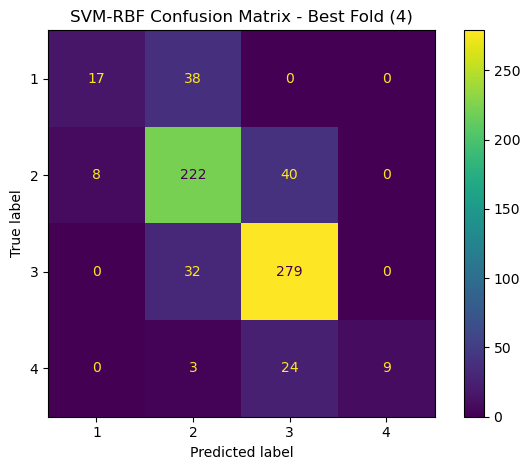

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. Select the final Top-10 features
# ============================================================

selected_top10 = top10_features['Feature'].tolist()

print("Selected Top-10 Features:")
for i, feature in enumerate(selected_top10, start=1):
    print(f"{i}. {feature}")


# ============================================================
# 2. Prepare X and y
# ============================================================

X = Soh_df[selected_top10]
y = Soh_df['ACR']


# ============================================================
# 3. 5-Fold Stratified Cross Validation
#    Shuffle = True
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 4. SVM-RBF Pipeline
# ============================================================
# StandardScaler must be fitted ONLY on training data.
# Pipeline prevents data leakage.

svm_rbf = Pipeline([
    
    ('scaler', StandardScaler()),
    
    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale'
    ))
])


# ============================================================
# 5. Storage for metrics
# ============================================================

metrics = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'specificity': []
}

confusion_matrices = []

fold_results = []


# ============================================================
# 6. 5-Fold Cross Validation
# ============================================================

for fold, (train_idx, test_idx) in enumerate(
    skf.split(X, y), start=1
):

    # -----------------------------
    # Split data
    # -----------------------------

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]


    # -----------------------------
    # Train SVM-RBF
    # -----------------------------

    svm_rbf.fit(X_train, y_train)


    # -----------------------------
    # Prediction
    # -----------------------------

    y_pred = svm_rbf.predict(X_test)


    # ========================================================
    # Metrics
    # ========================================================

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )


    # ========================================================
    # Confusion Matrix
    # ========================================================

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    confusion_matrices.append(cm)


    # ========================================================
    # Specificity
    # ========================================================
    # For binary classification

    if cm.shape == (2, 2):

        TN, FP, FN, TP = cm.ravel()

        specificity = TN / (TN + FP) \
            if (TN + FP) > 0 else 0

    else:
        specificity = np.nan


    # ========================================================
    # Save metrics
    # ========================================================

    metrics['accuracy'].append(accuracy)
    metrics['precision'].append(precision)
    metrics['recall'].append(recall)
    metrics['f1'].append(f1)
    metrics['specificity'].append(specificity)


    fold_results.append({
        'Fold': fold,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Specificity': specificity
    })


# ============================================================
# 7. Results for each Fold
# ============================================================

results_df = pd.DataFrame(fold_results)

print("\n" + "=" * 70)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 70)

print(
    results_df.to_string(index=False)
)


# ============================================================
# 8. Mean ± Standard Deviation
# ============================================================

summary = pd.DataFrame({
    
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-score',
        'Specificity'
    ],

    'Mean': [
        np.mean(metrics['accuracy']),
        np.mean(metrics['precision']),
        np.mean(metrics['recall']),
        np.mean(metrics['f1']),
        np.nanmean(metrics['specificity'])
    ],

    'SD': [
        np.std(metrics['accuracy'], ddof=1),
        np.std(metrics['precision'], ddof=1),
        np.std(metrics['recall'], ddof=1),
        np.std(metrics['f1'], ddof=1),
        np.nanstd(metrics['specificity'], ddof=1)
    ]
})


# ============================================================
# 9. Mean ± SD in percentage
# ============================================================

summary['Mean (%)'] = summary['Mean'] * 100
summary['SD (%)'] = summary['SD'] * 100

summary['Mean ± SD'] = (
    summary['Mean (%)'].map(lambda x: f"{x:.2f}")
    + " ± "
    + summary['SD (%)'].map(lambda x: f"{x:.2f}")
)


print("\n" + "=" * 70)
print("FINAL SVM-RBF PERFORMANCE")
print("=" * 70)

print(
    summary[
        ['Metric', 'Mean ± SD']
    ].to_string(index=False)
)


# ============================================================
# 10. Determine the Best Fold
# ============================================================

best_fold_index = np.argmax(
    metrics['f1']
)

best_fold = best_fold_index + 1

best_f1 = metrics['f1'][best_fold_index]


print("\n" + "=" * 70)
print("BEST FOLD")
print("=" * 70)

print(f"Best Fold: {best_fold}")
print(f"Best F1-score: {best_f1:.4f}")


# ============================================================
# 11. Confusion Matrix of Best Fold
# ============================================================

best_cm = confusion_matrices[best_fold_index]

print("\nConfusion Matrix of Best Fold:")
print(best_cm)


# ============================================================
# 12. Plot Confusion Matrix
# ============================================================

class_labels = np.unique(y)

disp = ConfusionMatrixDisplay(
    confusion_matrix=best_cm,
    display_labels=class_labels
)

disp.plot()

plt.title(
    f"SVM-RBF Confusion Matrix - Best Fold ({best_fold})"
)

plt.tight_layout()
plt.show()


FIXED TOP-10 FEATURES
1. skewness2
2. homogeneity0_2_bin2_6
3. entropy0_50
4. entropy0_3_bin2_6
5. 4bin_pol5-4
6. entropy45_3_bin1_3
7. entropy0_40
8. entropy90_2_bin2_4
9. bin1_5_20_IMC1
10. ASM135_20_bin3_7

SOH DATASET
Total samples  : 3362
Number features: 10

Training samples: 2689
Final test samples: 673


OUTER FOLD 1
Outer training samples: 2151
Outer validation samples: 538

Running Hyperparameter Optimization...

Best Parameters:
{'svm__C': 10, 'svm__gamma': 'scale'}
Best Inner-CV F1: 0.7427

Outer Fold Performance:
Accuracy : 0.7788
Precision: 0.7818
Recall   : 0.7788
F1-score : 0.7603


OUTER FOLD 2
Outer training samples: 2151
Outer validation samples: 538

Running Hyperparameter Optimization...

Best Parameters:
{'svm__C': 10, 'svm__gamma': 'scale'}
Best Inner-CV F1: 0.7376

Outer Fold Performance:
Accuracy : 0.7732
Precision: 0.7707
Recall   : 0.7732
F1-score : 0.7627


OUTER FOLD 3
Outer training samples: 2151
Outer validation samples: 538

Running Hyperparameter Optim

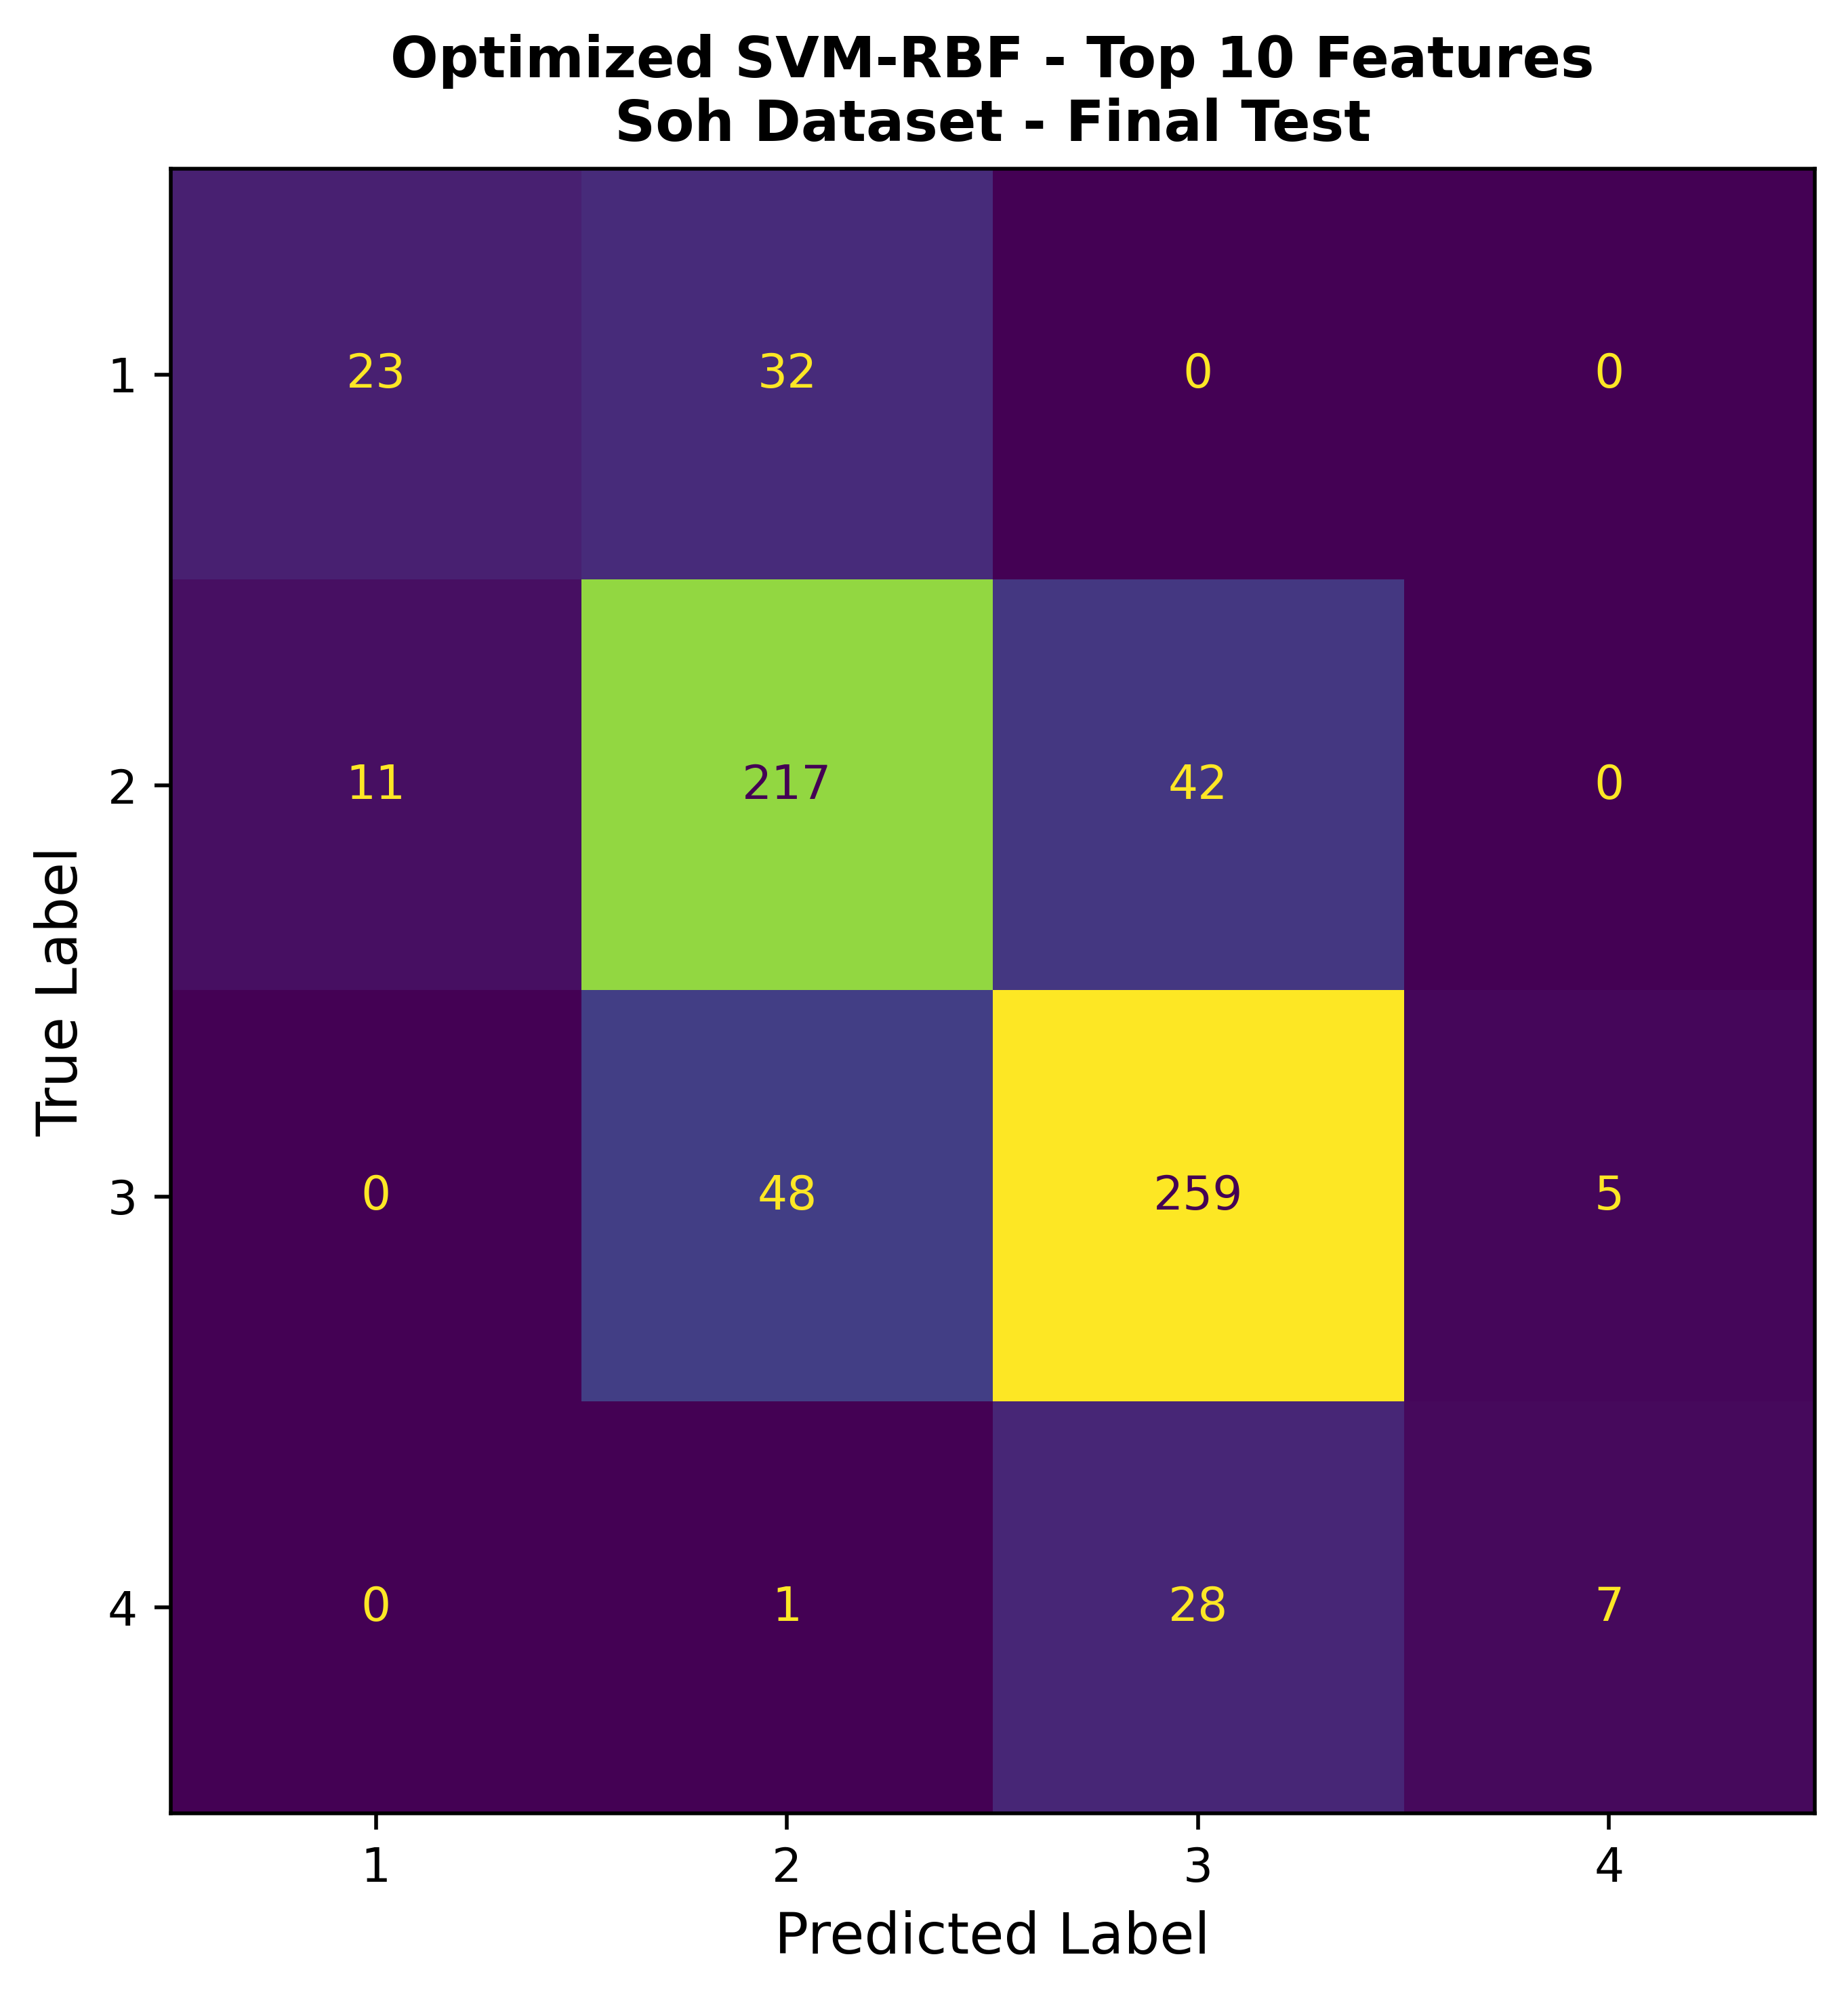

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. Fixed Top-10 Features
# ============================================================
# These features were selected previously.
# NO feature selection is performed in this code.

selected_top10 = [

    'skewness2',

    'homogeneity0_2_bin2_6',

    'entropy0_50',

    'entropy0_3_bin2_6',

    '4bin_pol5-4',

    'entropy45_3_bin1_3',

    'entropy0_40',

    'entropy90_2_bin2_4',

    'bin1_5_20_IMC1',

    'ASM135_20_bin3_7'
]


print("\n" + "=" * 80)
print("FIXED TOP-10 FEATURES")
print("=" * 80)

for i, feature in enumerate(
    selected_top10,
    start=1
):
    print(f"{i}. {feature}")


# ============================================================
# 2. Prepare Soh Dataset
# ============================================================

X = Soh_df[selected_top10]

y = Soh_df['ACR']


print("\n" + "=" * 80)
print("SOH DATASET")
print("=" * 80)

print(
    f"Total samples  : {X.shape[0]}"
)

print(
    f"Number features: {X.shape[1]}"
)


# ============================================================
# 3. Train / Final Test Split
# ============================================================
# IMPORTANT:
# The final test set is NOT used during hyperparameter
# optimization.

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    shuffle=True,

    random_state=42
)


print("\nTraining samples:",
      X_train.shape[0])

print("Final test samples:",
      X_test.shape[0])


# ============================================================
# 4. Outer 5-Fold CV
# ============================================================

outer_cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)


# ============================================================
# 5. SVM-RBF Hyperparameter Search Space
# ============================================================

param_grid = {

    'svm__C': [

        0.01,

        0.1,

        1,

        10,

        100
    ],

    'svm__gamma': [

        'scale',

        0.001,

        0.01,

        0.1,

        1
    ]
}


# ============================================================
# 6. Storage
# ============================================================

outer_results = []

best_parameters_each_fold = []


# ============================================================
# 7. OUTER 5-FOLD NESTED CROSS VALIDATION
# ============================================================

for fold, (train_idx, val_idx) in enumerate(

    outer_cv.split(
        X_train,
        y_train
    ),

    start=1
):

    print("\n")

    print("=" * 90)

    print(
        f"OUTER FOLD {fold}"
    )

    print("=" * 90)


    # ========================================================
    # A. Outer Train / Validation
    # ========================================================

    X_outer_train = X_train.iloc[
        train_idx
    ]

    X_outer_val = X_train.iloc[
        val_idx
    ]

    y_outer_train = y_train.iloc[
        train_idx
    ]

    y_outer_val = y_train.iloc[
        val_idx
    ]


    print(
        "Outer training samples:",
        X_outer_train.shape[0]
    )

    print(
        "Outer validation samples:",
        X_outer_val.shape[0]
    )


    # ========================================================
    # B. SVM-RBF Pipeline
    # ========================================================
    # Scaling is performed independently inside each fold.

    svm_pipeline = Pipeline([

        (
            'scaler',

            StandardScaler()
        ),

        (
            'svm',

            SVC(
                kernel='rbf'
            )
        )
    ])


    # ========================================================
    # C. Inner 5-Fold CV
    # ========================================================

    inner_cv = StratifiedKFold(

        n_splits=5,

        shuffle=True,

        random_state=42
    )


    # ========================================================
    # D. GridSearchCV
    # ========================================================

    grid_search = GridSearchCV(

        estimator=svm_pipeline,

        param_grid=param_grid,

        scoring='f1_weighted',

        cv=inner_cv,

        n_jobs=-1,

        refit=True
    )


    print("\nRunning Hyperparameter Optimization...")


    grid_search.fit(

        X_outer_train,

        y_outer_train
    )


    # ========================================================
    # E. Best Parameters
    # ========================================================

    best_C = grid_search.best_params_[
        'svm__C'
    ]

    best_gamma = grid_search.best_params_[
        'svm__gamma'
    ]


    print("\nBest Parameters:")

    print(
        grid_search.best_params_
    )


    print(
        f"Best Inner-CV F1: "
        f"{grid_search.best_score_:.4f}"
    )


    best_parameters_each_fold.append({

        'Fold': fold,

        'C': best_C,

        'Gamma': best_gamma,

        'Inner_CV_F1':
            grid_search.best_score_
    })


    # ========================================================
    # F. Evaluate on Outer Validation
    # ========================================================

    y_pred = grid_search.predict(

        X_outer_val
    )


    # ========================================================
    # G. Metrics
    # ========================================================

    accuracy = accuracy_score(

        y_outer_val,

        y_pred
    )


    precision = precision_score(

        y_outer_val,

        y_pred,

        average='weighted',

        zero_division=0
    )


    recall = recall_score(

        y_outer_val,

        y_pred,

        average='weighted',

        zero_division=0
    )


    f1 = f1_score(

        y_outer_val,

        y_pred,

        average='weighted',

        zero_division=0
    )


    # ========================================================
    # H. Save Results
    # ========================================================

    outer_results.append({

        'Fold': fold,

        'Accuracy': accuracy,

        'Precision': precision,

        'Recall': recall,

        'F1': f1,

        'Best_C': best_C,

        'Best_Gamma': best_gamma
    })


    print("\nOuter Fold Performance:")

    print(
        f"Accuracy : {accuracy:.4f}"
    )

    print(
        f"Precision: {precision:.4f}"
    )

    print(
        f"Recall   : {recall:.4f}"
    )

    print(
        f"F1-score : {f1:.4f}"
    )


# ============================================================
# 8. Nested CV Results
# ============================================================

nested_results = pd.DataFrame(

    outer_results
)


print("\n")

print("=" * 90)

print(
    "NESTED 5-FOLD CV RESULTS - SOH DATASET"
)

print("=" * 90)


print(

    nested_results.to_string(
        index=False
    )
)


# ============================================================
# 9. Mean ± SD
# ============================================================

summary = pd.DataFrame({

    'Metric': [

        'Accuracy',

        'Precision',

        'Recall',

        'F1-score'
    ],

    'Mean': [

        nested_results[
            'Accuracy'
        ].mean(),

        nested_results[
            'Precision'
        ].mean(),

        nested_results[
            'Recall'
        ].mean(),

        nested_results[
            'F1'
        ].mean()
    ],

    'SD': [

        nested_results[
            'Accuracy'
        ].std(
            ddof=1
        ),

        nested_results[
            'Precision'
        ].std(
            ddof=1
        ),

        nested_results[
            'Recall'
        ].std(
            ddof=1
        ),

        nested_results[
            'F1'
        ].std(
            ddof=1
        )
    ]
})


# ============================================================
# 10. Convert to Percentage
# ============================================================

summary['Mean (%)'] = (

    summary['Mean'] * 100
)


summary['SD (%)'] = (

    summary['SD'] * 100
)


summary['Mean ± SD'] = (

    summary['Mean (%)'].map(

        lambda x:
        f"{x:.2f}"
    )

    + " ± "

    +

    summary['SD (%)'].map(

        lambda x:
        f"{x:.2f}"
    )
)


# ============================================================
# 11. Final Nested CV Performance
# ============================================================

print("\n")

print("=" * 90)

print(
    "FINAL NESTED 5-FOLD CV PERFORMANCE"
)

print("=" * 90)


print(

    summary[
        ['Metric', 'Mean ± SD']
    ].to_string(
        index=False
    )
)


# ============================================================
# 12. Hyperparameter Stability Across Folds
# ============================================================

parameters_df = pd.DataFrame(

    best_parameters_each_fold
)


print("\n")

print("=" * 90)

print(
    "BEST PARAMETERS IN EACH OUTER FOLD"
)

print("=" * 90)


print(

    parameters_df.to_string(
        index=False
    )
)


# ============================================================
# 13. Final Hyperparameter Optimization
# ============================================================
# IMPORTANT:
# Final test set is STILL untouched.

final_svm_pipeline = Pipeline([

    (
        'scaler',

        StandardScaler()
    ),

    (
        'svm',

        SVC(
            kernel='rbf'
        )
    )
])


final_inner_cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)


final_grid_search = GridSearchCV(

    estimator=final_svm_pipeline,

    param_grid=param_grid,

    scoring='f1_weighted',

    cv=final_inner_cv,

    n_jobs=-1,

    refit=True
)


print("\n")

print("=" * 90)

print(
    "FINAL SVM-RBF HYPERPARAMETER OPTIMIZATION"
)

print("=" * 90)


final_grid_search.fit(

    X_train,

    y_train
)


# ============================================================
# 14. Final Best Model
# ============================================================

print("\n")

print(
    "FINAL BEST PARAMETERS:"
)

print(

    final_grid_search.best_params_
)


print(

    f"Best Training CV F1: "
    f"{final_grid_search.best_score_:.4f}"
)


# ============================================================
# 15. Final Model on Test Data
# ============================================================

y_test_pred = final_grid_search.predict(

    X_test
)


# ============================================================
# 16. Final Test Metrics
# ============================================================

test_accuracy = accuracy_score(

    y_test,

    y_test_pred
)


test_precision = precision_score(

    y_test,

    y_test_pred,

    average='weighted',

    zero_division=0
)


test_recall = recall_score(

    y_test,

    y_test_pred,

    average='weighted',

    zero_division=0
)


test_f1 = f1_score(

    y_test,

    y_test_pred,

    average='weighted',

    zero_division=0
)


# ============================================================
# 17. FINAL TEST PERFORMANCE
# ============================================================

print("\n")

print("=" * 90)

print(
    "FINAL TEST PERFORMANCE - SOH DATASET"
)

print("=" * 90)


print(

    f"Accuracy : "
    f"{test_accuracy:.4f}"
)


print(

    f"Precision: "
    f"{test_precision:.4f}"
)


print(

    f"Recall   : "
    f"{test_recall:.4f}"
)


print(

    f"F1-score : "
    f"{test_f1:.4f}"
)


# ============================================================
# 18. Classification Report
# ============================================================

print("\n")

print(
    "CLASSIFICATION REPORT"
)

print(

    classification_report(

        y_test,

        y_test_pred,

        zero_division=0
    )
)


# ============================================================
# 19. Confusion Matrix
# ============================================================

cm = confusion_matrix(

    y_test,

    y_test_pred
)


print("\n")

print(
    "CONFUSION MATRIX - FINAL TEST"
)

print(cm)


# ============================================================
# 20. Plot Confusion Matrix
# ============================================================

class_labels = np.unique(y)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_labels
)


fig, ax = plt.subplots(

    figsize=(7, 6),

    dpi=500
)


disp.plot(

    ax=ax,

    values_format='d',

    colorbar=False
)


plt.title(

    "Optimized SVM-RBF - Top 10 Features\n"
    "Soh Dataset - Final Test",

    fontsize=12,

    weight='bold'
)


plt.xlabel(

    "Predicted Label",

    fontsize=12
)


plt.ylabel(

    "True Label",

    fontsize=12
)


plt.xticks(
    fontsize=10
)

plt.yticks(
    fontsize=10
)


plt.tight_layout()

plt.show()

Selected Top-10 Features:
1. skewness2
2. homogeneity0_2_bin2_6
3. entropy0_50
4. entropy0_3_bin2_6
5. 4bin_pol5-4
6. entropy45_3_bin1_3
7. entropy0_40
8. entropy90_2_bin2_4
9. bin1_5_20_IMC1
10. ASM135_20_bin3_7

Fold 1

Fold 2

Fold 3

Fold 4

Fold 5


ANN - 5-FOLD CROSS-VALIDATION RESULTS
 Fold  Accuracy  Precision   Recall       F1
    1  0.742942   0.694308 0.742942 0.709960
    2  0.750371   0.746099 0.750371 0.738728
    3  0.735119   0.733033 0.735119 0.709591
    4  0.775298   0.765031 0.775298 0.759892
    5  0.742560   0.737176 0.742560 0.732267


FINAL ANN PERFORMANCE
   Metric    Mean ± SD
 Accuracy 74.93 ± 1.55
Precision 73.51 ± 2.59
   Recall 74.93 ± 1.55
 F1-score 73.01 ± 2.12


BEST FOLD
Best Fold: 4
Best F1-score: 0.7599

Confusion Matrix:
[[ 17  38   0   0]
 [ 12 223  35   0]
 [  0  35 272   4]
 [  0   3  24   9]]


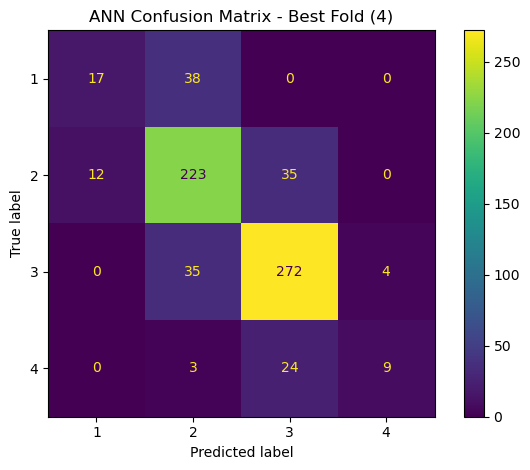

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. Top-10 Features selected in previous step
# ============================================================

selected_top10 = top10_features['Feature'].tolist()

print("Selected Top-10 Features:")
for i, feature in enumerate(selected_top10, start=1):
    print(f"{i}. {feature}")


# ============================================================
# 2. Prepare X and y
# ============================================================

X = Soh_df[selected_top10]
y = Soh_df['ACR']


# ============================================================
# 3. Stratified 5-Fold Cross Validation
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 4. ANN / MLP Pipeline
# ============================================================
# StandardScaler is fitted separately inside each Fold.

ann = Pipeline([

    ('scaler', StandardScaler()),

    ('mlp', MLPClassifier(
        hidden_layer_sizes=(16, 8),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=30,
        random_state=42
    ))
])


# ============================================================
# 5. Storage
# ============================================================

metrics = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

confusion_matrices = []

fold_results = []


# ============================================================
# 6. 5-Fold Cross Validation
# ============================================================

for fold, (train_idx, test_idx) in enumerate(
    skf.split(X, y),
    start=1
):

    print("\n" + "=" * 60)
    print(f"Fold {fold}")
    print("=" * 60)

    # --------------------------------------------------------
    # Train / Test split for current Fold
    # --------------------------------------------------------

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]


    # --------------------------------------------------------
    # Train ANN
    # --------------------------------------------------------

    ann.fit(
        X_train,
        y_train
    )


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    y_pred = ann.predict(X_test)


    # ========================================================
    # Metrics
    # ========================================================

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )


    # ========================================================
    # Confusion Matrix
    # ========================================================

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    confusion_matrices.append(cm)


    # ========================================================
    # Save metrics
    # ========================================================

    metrics['accuracy'].append(accuracy)
    metrics['precision'].append(precision)
    metrics['recall'].append(recall)
    metrics['f1'].append(f1)


    fold_results.append({

        'Fold': fold,

        'Accuracy': accuracy,

        'Precision': precision,

        'Recall': recall,

        'F1': f1
    })


# ============================================================
# 7. Fold-by-Fold Results
# ============================================================

results_df = pd.DataFrame(
    fold_results
)

print("\n")
print("=" * 70)
print("ANN - 5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 70)

print(
    results_df.to_string(index=False)
)


# ============================================================
# 8. Calculate Mean ± SD
# ============================================================

summary = pd.DataFrame({

    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1-score'
    ],

    'Mean': [

        np.mean(metrics['accuracy']),

        np.mean(metrics['precision']),

        np.mean(metrics['recall']),

        np.mean(metrics['f1'])
    ],

    'SD': [

        np.std(
            metrics['accuracy'],
            ddof=1
        ),

        np.std(
            metrics['precision'],
            ddof=1
        ),

        np.std(
            metrics['recall'],
            ddof=1
        ),

        np.std(
            metrics['f1'],
            ddof=1
        )
    ]
})


# ============================================================
# 9. Convert to Percentage
# ============================================================

summary['Mean (%)'] = (
    summary['Mean'] * 100
)

summary['SD (%)'] = (
    summary['SD'] * 100
)


summary['Mean ± SD'] = (

    summary['Mean (%)'].map(
        lambda x: f"{x:.2f}"
    )

    + " ± "

    + summary['SD (%)'].map(
        lambda x: f"{x:.2f}"
    )
)


# ============================================================
# 10. Final Results
# ============================================================

print("\n")
print("=" * 70)
print("FINAL ANN PERFORMANCE")
print("=" * 70)

print(
    summary[
        ['Metric', 'Mean ± SD']
    ].to_string(index=False)
)


# ============================================================
# 11. Best Fold
# ============================================================
# F1-score is used to select the best Fold.

best_fold_index = np.argmax(
    metrics['f1']
)

best_fold = (
    best_fold_index + 1
)

best_f1 = (
    metrics['f1'][best_fold_index]
)


print("\n")
print("=" * 70)
print("BEST FOLD")
print("=" * 70)

print(
    f"Best Fold: {best_fold}"
)

print(
    f"Best F1-score: {best_f1:.4f}"
)


# ============================================================
# 12. Confusion Matrix of Best Fold
# ============================================================

best_cm = confusion_matrices[
    best_fold_index
]

print("\nConfusion Matrix:")
print(best_cm)


# ============================================================
# 13. Plot Confusion Matrix
# ============================================================

class_labels = np.unique(y)

disp = ConfusionMatrixDisplay(
    confusion_matrix=best_cm,
    display_labels=class_labels
)

disp.plot()

plt.title(
    f"ANN Confusion Matrix - Best Fold ({best_fold})"
)

plt.tight_layout()

plt.show()

In [18]:
import numpy as np
import pandas as pd
import os

from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import StratifiedKFold


# ============================================================
# 1. Prepare data
# ============================================================

X = Soh_df.drop(columns=['ACR'])
y = Soh_df['ACR']


# ============================================================
# 2. 5-Fold Stratified Cross Validation
#    Shuffle = True
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 3. Storage for feature selection results
# ============================================================

feature_names = X.columns

# تعداد دفعاتی که هر ویژگی در Top 25 انتخاب شده
selection_count = pd.Series(
    0,
    index=feature_names,
    dtype=int
)

# رتبه هر ویژگی در هر Fold
rank_matrix = pd.DataFrame(
    index=feature_names,
    columns=[f'Fold_{i}' for i in range(1, 6)],
    dtype=float
)


# ============================================================
# 4. Perform RFE inside each Fold
# ============================================================

for fold, (train_idx, test_idx) in enumerate(
    skf.split(X, y),
    start=1
):

    print("=" * 60)
    print(f"Fold {fold}")
    print("=" * 60)

    # -----------------------------
    # Train data for this fold
    # -----------------------------

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    # -----------------------------
    # Decision Tree estimator
    # -----------------------------

    dt = DecisionTreeClassifier(
        random_state=42,
        criterion='gini',
        max_depth=None
    )

    # -----------------------------
    # RFE
    # -----------------------------

    selector = RFE(
        estimator=dt,
        n_features_to_select=25,
        step=0.01
    )

    selector.fit(
        X_train,
        y_train
    )

    # -----------------------------
    # Selected features
    # -----------------------------

    selected_features = feature_names[
        selector.get_support()
    ]

    print("\nTop 25 features in this fold:")

    for i, feature in enumerate(
        selected_features,
        start=1
    ):
        print(f"{i}. {feature}")

    # -----------------------------
    # Count selection frequency
    # -----------------------------

    selection_count.loc[
        selected_features
    ] += 1

    # -----------------------------
    # Save feature ranking
    # -----------------------------

    rank_matrix[
        f'Fold_{fold}'
    ] = selector.ranking_


# ============================================================
# 5. Calculate selection frequency
# ============================================================

selection_frequency = (
    selection_count / skf.n_splits
) * 100


# ============================================================
# 6. Calculate mean RFE rank
# ============================================================

mean_rank = rank_matrix.mean(
    axis=1
)


# ============================================================
# 7. Create final feature ranking table
# ============================================================

results = pd.DataFrame({

    'Feature': feature_names,

    'Selection_Count':
        selection_count.values,

    'Selection_Frequency_%':
        selection_frequency.values,

    'Mean_Rank':
        mean_rank.values
})


# ============================================================
# 8. Sort features
# ============================================================

results = results.sort_values(

    by=[
        'Selection_Count',
        'Mean_Rank'
    ],

    ascending=[
        False,
        True
    ]

).reset_index(drop=True)


# ============================================================
# 9. Final Top 25 Features
# ============================================================

top25_features = results.head(25)


print("\n")
print("=" * 80)
print("FINAL TOP 25 FEATURES")
print("=" * 80)

print(
    top25_features.to_string(
        index=False
    )
)


# ============================================================
# 10. List only feature names
# ============================================================

selected_top25 = (
    top25_features['Feature'].tolist()
)


print("\nTop 25 Feature Names:")

for i, feature in enumerate(
    selected_top25,
    start=1
):
    print(f"{i}. {feature}")


# ============================================================
# 11. Voice notification
# ============================================================

os.system(
    'say "Feature selection completed"'
)

Fold 1

Top 25 features in this fold:
1. pol5-6_256
2. contrast45_5_bin1_3
3. contrast90_3_bin1_3
4. dissimilarity45_3_bin2_4
5. entropy90_2_bin2_4
6. entropy90_3_bin4_4
7. entropy45_3_bin1_6
8. entropy90_2_bin1_6
9. entropy0_3_bin2_6
10. entropy0_20_bin2_6
11. correlation45_20_bin2_6
12. homogeneity135_2_bin3_7
13. ASM135_20_bin3_7
14. ASM45_50_bin4_7
15. ASM90_30_bin5_7
16. ASM45_3_bin7_7
17. bin1_5_20_IMC1
18. bin3_5_5_sumvar
19. bin4_5_3_sumvar
20. bin5_5_20_correlation
21. bin5_5_40_sumvar
22. bin1_7_50_IMC1
23. bin2_7_10_IMC2
24. entropy0_50
25. skewness2
Fold 2

Top 25 features in this fold:
1. bin2_4_area3max
2. bin2 to 3_area3max
3. 7bin_pol3-3
4. entropy45_3_bin1_3
5. ASM90_30_bin1_3
6. contrast45_2_bin2_4
7. homogeneity0_2_bin2_6
8. entropy0_3_bin2_6
9. dissimilarity0_10_bin2_6
10. ASM0_50_bin4_6
11. correlation45_1_bin4_6
12. correlation45_3_bin4_6
13. homogeneity45_2_bin6_6
14. ASM0_20_bin2_7
15. entropy135_30_bin3_7
16. bin1_5_20_IMC1
17. bin3_6_1_IMC1
18. bin5_7_4_IMC1
1

0

In [19]:
top25_features

,Feature,Selection_Count,Selection_Frequency_%,Mean_Rank
0,skewness2,5,100.0,1.0
1,homogeneity0_2_bin2_6,4,80.0,11.2
2,entropy0_50,3,60.0,10.8
3,entropy0_3_bin2_6,3,60.0,21.6
4,4bin_pol5-4,2,40.0,4.8
5,entropy45_3_bin1_3,2,40.0,9.4
6,entropy0_40,2,40.0,12.8
7,entropy90_2_bin2_4,2,40.0,22.2
8,entropy45_3_bin1_6,2,40.0,28.4
9,bin1_5_20_IMC1,2,40.0,44.2


### To Train SVM

Selected Top-25 Features:
1. skewness2
2. homogeneity0_2_bin2_6
3. entropy0_50
4. entropy0_3_bin2_6
5. 4bin_pol5-4
6. entropy45_3_bin1_3
7. entropy0_40
8. entropy90_2_bin2_4
9. entropy45_3_bin1_6
10. bin1_5_20_IMC1
11. homogeneity45_2_bin6_6
12. ASM135_20_bin3_7
13. bin2 to 3_area3max
14. bin1_7_maxisland
15. bin3 to 7_maxisland
16. bin3 to 6_meanof3max
17. bin6_6_40_sumvar
18. 8bin-pol7_1
19. 64bin-pol6_1
20. contrast0_30_bin1_3
21. 7bin_pol3-3
22. correlation0_30_bin1_3
23. ASM90_30_bin1_3
24. contrast45_5_bin1_3
25. pol5-6_256

Fold 1

Fold 2

Fold 3

Fold 4

Fold 5

SVM-RBF - TOP 25 FEATURES
5-FOLD CROSS-VALIDATION RESULTS
 Fold  Accuracy  Precision   Recall       F1  Specificity
    1  0.769688   0.772014 0.769688 0.748533          NaN
    2  0.753343   0.762996 0.753343 0.723958          NaN
    3  0.748512   0.757774 0.748512 0.727592          NaN
    4  0.761905   0.757447 0.761905 0.732306          NaN
    5  0.750000   0.744757 0.750000 0.727951          NaN

FINAL SVM-RBF PE

/var/folders/65/pcvy2phn43vfvlpmhhpv2pj40000gn/T/ipykernel_7373/3981385189.py:307: RuntimeWarning: Mean of empty slice
  np.nanmean(
/opt/anaconda3/envs/Myenv1/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


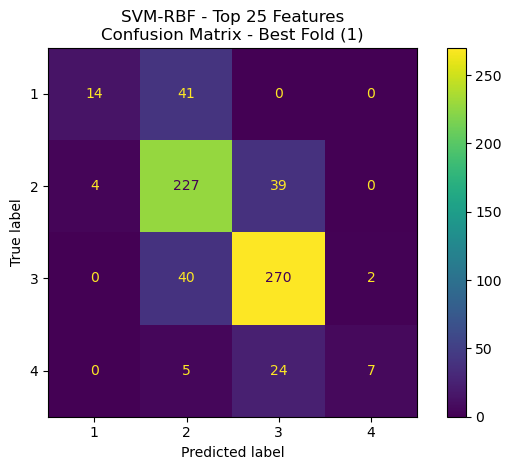

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. Select the final Top-25 features
# ============================================================

selected_top25 = top25_features['Feature'].tolist()

print("Selected Top-25 Features:")

for i, feature in enumerate(
    selected_top25,
    start=1
):
    print(f"{i}. {feature}")


# ============================================================
# 2. Prepare X and y
# ============================================================

X = Soh_df[selected_top25]
y = Soh_df['ACR']


# ============================================================
# 3. 5-Fold Stratified Cross Validation
#    Shuffle = True
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 4. SVM-RBF Pipeline
# ============================================================
# StandardScaler is fitted ONLY on training data.
# Pipeline prevents data leakage.

svm_rbf = Pipeline([

    ('scaler', StandardScaler()),

    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale'
    ))
])


# ============================================================
# 5. Storage for metrics
# ============================================================

metrics = {

    'accuracy': [],

    'precision': [],

    'recall': [],

    'f1': [],

    'specificity': []
}

confusion_matrices = []

fold_results = []


# ============================================================
# 6. 5-Fold Cross Validation
# ============================================================

for fold, (train_idx, test_idx) in enumerate(
    skf.split(X, y),
    start=1
):

    print("\n" + "=" * 70)
    print(f"Fold {fold}")
    print("=" * 70)


    # --------------------------------------------------------
    # Split data
    # --------------------------------------------------------

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]


    # --------------------------------------------------------
    # Train SVM-RBF
    # --------------------------------------------------------

    svm_rbf.fit(
        X_train,
        y_train
    )


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    y_pred = svm_rbf.predict(
        X_test
    )


    # ========================================================
    # Metrics
    # ========================================================

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )


    # ========================================================
    # Confusion Matrix
    # ========================================================

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    confusion_matrices.append(
        cm
    )


    # ========================================================
    # Specificity
    # ========================================================
    # For binary classification only

    if cm.shape == (2, 2):

        TN, FP, FN, TP = cm.ravel()

        specificity = (
            TN / (TN + FP)
            if (TN + FP) > 0
            else 0
        )

    else:

        specificity = np.nan


    # ========================================================
    # Save metrics
    # ========================================================

    metrics['accuracy'].append(
        accuracy
    )

    metrics['precision'].append(
        precision
    )

    metrics['recall'].append(
        recall
    )

    metrics['f1'].append(
        f1
    )

    metrics['specificity'].append(
        specificity
    )


    # ========================================================
    # Save Fold results
    # ========================================================

    fold_results.append({

        'Fold': fold,

        'Accuracy': accuracy,

        'Precision': precision,

        'Recall': recall,

        'F1': f1,

        'Specificity': specificity
    })


# ============================================================
# 7. Results for each Fold
# ============================================================

results_df = pd.DataFrame(
    fold_results
)


print("\n" + "=" * 70)
print("SVM-RBF - TOP 25 FEATURES")
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 70)

print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# 8. Mean ± Standard Deviation
# ============================================================

summary = pd.DataFrame({

    'Metric': [

        'Accuracy',

        'Precision',

        'Recall',

        'F1-score',

        'Specificity'
    ],

    'Mean': [

        np.mean(
            metrics['accuracy']
        ),

        np.mean(
            metrics['precision']
        ),

        np.mean(
            metrics['recall']
        ),

        np.mean(
            metrics['f1']
        ),

        np.nanmean(
            metrics['specificity']
        )
    ],

    'SD': [

        np.std(
            metrics['accuracy'],
            ddof=1
        ),

        np.std(
            metrics['precision'],
            ddof=1
        ),

        np.std(
            metrics['recall'],
            ddof=1
        ),

        np.std(
            metrics['f1'],
            ddof=1
        ),

        np.nanstd(
            metrics['specificity'],
            ddof=1
        )
    ]
})


# ============================================================
# 9. Mean ± SD in percentage
# ============================================================

summary['Mean (%)'] = (
    summary['Mean'] * 100
)

summary['SD (%)'] = (
    summary['SD'] * 100
)


summary['Mean ± SD'] = (

    summary['Mean (%)'].map(
        lambda x: f"{x:.2f}"
    )

    + " ± "

    + summary['SD (%)'].map(
        lambda x: f"{x:.2f}"
    )
)


# ============================================================
# 10. Final SVM-RBF Performance
# ============================================================

print("\n" + "=" * 70)
print("FINAL SVM-RBF PERFORMANCE - TOP 25 FEATURES")
print("=" * 70)

print(
    summary[
        ['Metric', 'Mean ± SD']
    ].to_string(
        index=False
    )
)


# ============================================================
# 11. Determine the Best Fold
# ============================================================
# Best Fold = highest F1-score

best_fold_index = np.argmax(
    metrics['f1']
)

best_fold = (
    best_fold_index + 1
)

best_f1 = (
    metrics['f1'][best_fold_index]
)


print("\n" + "=" * 70)
print("BEST FOLD")
print("=" * 70)

print(
    f"Best Fold: {best_fold}"
)

print(
    f"Best F1-score: {best_f1:.4f}"
)


# ============================================================
# 12. Confusion Matrix of Best Fold
# ============================================================

best_cm = confusion_matrices[
    best_fold_index
]


print("\nConfusion Matrix of Best Fold:")

print(
    best_cm
)


# ============================================================
# 13. Plot Confusion Matrix
# ============================================================

class_labels = np.unique(y)


disp = ConfusionMatrixDisplay(

    confusion_matrix=best_cm,

    display_labels=class_labels
)


disp.plot()


plt.title(
    f"SVM-RBF - Top 25 Features\n"
    f"Confusion Matrix - Best Fold ({best_fold})"
)

plt.tight_layout()

plt.show()

### To Train ANN

Selected Top-25 Features:
1. skewness2
2. homogeneity0_2_bin2_6
3. entropy0_50
4. entropy0_3_bin2_6
5. 4bin_pol5-4
6. entropy45_3_bin1_3
7. entropy0_40
8. entropy90_2_bin2_4
9. entropy45_3_bin1_6
10. bin1_5_20_IMC1
11. homogeneity45_2_bin6_6
12. ASM135_20_bin3_7
13. bin2 to 3_area3max
14. bin1_7_maxisland
15. bin3 to 7_maxisland
16. bin3 to 6_meanof3max
17. bin6_6_40_sumvar
18. 8bin-pol7_1
19. 64bin-pol6_1
20. contrast0_30_bin1_3
21. 7bin_pol3-3
22. correlation0_30_bin1_3
23. ASM90_30_bin1_3
24. contrast45_5_bin1_3
25. pol5-6_256

Fold 1

Fold 2

Fold 3

Fold 4

Fold 5


ANN - TOP 25 FEATURES - 5-FOLD CROSS-VALIDATION RESULTS
 Fold  Accuracy  Precision   Recall       F1
    1  0.756315   0.747884 0.756315 0.747049
    2  0.760773   0.757387 0.760773 0.749042
    3  0.718750   0.675359 0.718750 0.687218
    4  0.757440   0.752522 0.757440 0.737727
    5  0.738095   0.728572 0.738095 0.726731


FINAL ANN PERFORMANCE - TOP 25 FEATURES
   Metric    Mean ± SD
 Accuracy 74.63 ± 1.77
Precisio

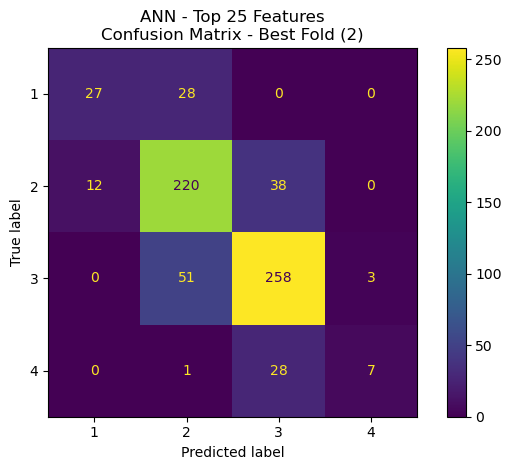

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. Top-25 Features selected in previous step
# ============================================================

selected_top25 = top25_features['Feature'].tolist()

print("Selected Top-25 Features:")

for i, feature in enumerate(
    selected_top25,
    start=1
):
    print(f"{i}. {feature}")


# ============================================================
# 2. Prepare X and y
# ============================================================

X = Soh_df[selected_top25]
y = Soh_df['ACR']


# ============================================================
# 3. Stratified 5-Fold Cross Validation
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 4. ANN / MLP Pipeline
# ============================================================
# StandardScaler is fitted separately inside each Fold.
# This prevents data leakage.

ann = Pipeline([

    ('scaler', StandardScaler()),

    ('mlp', MLPClassifier(

        hidden_layer_sizes=(16, 8),

        activation='relu',

        solver='adam',

        alpha=0.0001,

        learning_rate_init=0.001,

        max_iter=1000,

        early_stopping=True,

        validation_fraction=0.15,

        n_iter_no_change=30,

        random_state=42
    ))
])


# ============================================================
# 5. Storage
# ============================================================

metrics = {

    'accuracy': [],

    'precision': [],

    'recall': [],

    'f1': []
}

confusion_matrices = []

fold_results = []


# ============================================================
# 6. 5-Fold Cross Validation
# ============================================================

for fold, (train_idx, test_idx) in enumerate(
    skf.split(X, y),
    start=1
):

    print("\n" + "=" * 60)
    print(f"Fold {fold}")
    print("=" * 60)


    # --------------------------------------------------------
    # Train / Test split for current Fold
    # --------------------------------------------------------

    X_train = X.iloc[train_idx]

    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]

    y_test = y.iloc[test_idx]


    # --------------------------------------------------------
    # Train ANN
    # --------------------------------------------------------

    ann.fit(
        X_train,
        y_train
    )


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    y_pred = ann.predict(
        X_test
    )


    # ========================================================
    # Metrics
    # ========================================================

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )


    # ========================================================
    # Confusion Matrix
    # ========================================================

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    confusion_matrices.append(
        cm
    )


    # ========================================================
    # Save metrics
    # ========================================================

    metrics['accuracy'].append(
        accuracy
    )

    metrics['precision'].append(
        precision
    )

    metrics['recall'].append(
        recall
    )

    metrics['f1'].append(
        f1
    )


    # ========================================================
    # Save Fold Results
    # ========================================================

    fold_results.append({

        'Fold': fold,

        'Accuracy': accuracy,

        'Precision': precision,

        'Recall': recall,

        'F1': f1
    })


# ============================================================
# 7. Fold-by-Fold Results
# ============================================================

results_df = pd.DataFrame(
    fold_results
)


print("\n")

print("=" * 70)

print(
    "ANN - TOP 25 FEATURES - "
    "5-FOLD CROSS-VALIDATION RESULTS"
)

print("=" * 70)


print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# 8. Calculate Mean ± Standard Deviation
# ============================================================

summary = pd.DataFrame({

    'Metric': [

        'Accuracy',

        'Precision',

        'Recall',

        'F1-score'
    ],

    'Mean': [

        np.mean(
            metrics['accuracy']
        ),

        np.mean(
            metrics['precision']
        ),

        np.mean(
            metrics['recall']
        ),

        np.mean(
            metrics['f1']
        )
    ],

    'SD': [

        np.std(
            metrics['accuracy'],
            ddof=1
        ),

        np.std(
            metrics['precision'],
            ddof=1
        ),

        np.std(
            metrics['recall'],
            ddof=1
        ),

        np.std(
            metrics['f1'],
            ddof=1
        )
    ]
})


# ============================================================
# 9. Convert to Percentage
# ============================================================

summary['Mean (%)'] = (
    summary['Mean'] * 100
)

summary['SD (%)'] = (
    summary['SD'] * 100
)


summary['Mean ± SD'] = (

    summary['Mean (%)'].map(
        lambda x: f"{x:.2f}"
    )

    + " ± "

    + summary['SD (%)'].map(
        lambda x: f"{x:.2f}"
    )
)


# ============================================================
# 10. Final ANN Results
# ============================================================

print("\n")

print("=" * 70)

print(
    "FINAL ANN PERFORMANCE - TOP 25 FEATURES"
)

print("=" * 70)


print(
    summary[
        ['Metric', 'Mean ± SD']
    ].to_string(
        index=False
    )
)


# ============================================================
# 11. Best Fold
# ============================================================
# Best Fold = highest F1-score

best_fold_index = np.argmax(
    metrics['f1']
)

best_fold = (
    best_fold_index + 1
)

best_f1 = (
    metrics['f1'][best_fold_index]
)


print("\n")

print("=" * 70)

print("BEST FOLD")

print("=" * 70)


print(
    f"Best Fold: {best_fold}"
)

print(
    f"Best F1-score: {best_f1:.4f}"
)


# ============================================================
# 12. Confusion Matrix of Best Fold
# ============================================================

best_cm = confusion_matrices[
    best_fold_index
]


print("\nConfusion Matrix:")

print(
    best_cm
)


# ============================================================
# 13. Plot Confusion Matrix
# ============================================================

class_labels = np.unique(
    y
)


disp = ConfusionMatrixDisplay(

    confusion_matrix=best_cm,

    display_labels=class_labels
)


disp.plot()


plt.title(
    f"ANN - Top 25 Features\n"
    f"Confusion Matrix - Best Fold ({best_fold})"
)


plt.tight_layout()

plt.show()

In [26]:
selected_top10

['skewness2',
 'homogeneity0_2_bin2_6',
 'entropy0_50',
 'entropy0_3_bin2_6',
 '4bin_pol5-4',
 'entropy45_3_bin1_3',
 'entropy0_40',
 'entropy90_2_bin2_4',
 'bin1_5_20_IMC1',
 'ASM135_20_bin3_7']

In [27]:
selected_top25

['skewness2',
 'homogeneity0_2_bin2_6',
 'entropy0_50',
 'entropy0_3_bin2_6',
 '4bin_pol5-4',
 'entropy45_3_bin1_3',
 'entropy0_40',
 'entropy90_2_bin2_4',
 'entropy45_3_bin1_6',
 'bin1_5_20_IMC1',
 'homogeneity45_2_bin6_6',
 'ASM135_20_bin3_7',
 'bin2 to 3_area3max',
 'bin1_7_maxisland',
 'bin3 to 7_maxisland',
 'bin3 to 6_meanof3max',
 'bin6_6_40_sumvar',
 '8bin-pol7_1',
 '64bin-pol6_1',
 'contrast0_30_bin1_3',
 '7bin_pol3-3',
 'correlation0_30_bin1_3',
 'ASM90_30_bin1_3',
 'contrast45_5_bin1_3',
 'pol5-6_256']

In [3]:
VinDr_Path = '/Users/rezvaneh/Desktop/Mammo Research/SelectedFeatures_3Datasets/VinDr/train/Vindr_CC_train.xlsx'
tst_VinDr_Path = '/Users/rezvaneh/Desktop/Mammo Research/SelectedFeatures_3Datasets/VinDr/test/Vindr_CC_test.csv'
vin_df = pd.read_excel(VinDr_Path)
test_vin_df = pd.read_csv(tst_VinDr_Path)


In [29]:
vin_df

,bin1_3_area3max,bin1_3_maxisland,bin1_3_meanof3max,bin2_3_area3max,bin2_3_maxisland,bin2_3_meanof3max,bin3_3_area3max,bin3_3_maxisland,bin3_3_meanof3max,bin1_4_area3max,...,range_bin,entropy,contrast,peaks,auc,intensity_at_80,sort_intensity_at_80,intensity_at_50,sort_intensity_at_50,ACR
0,0.253807,0.252150,15672.666670,0.681179,0.671208,42063.00000,0.003142,0.002445,194.000000,0.090116,...,71,4.796483,251,3,0.990415,73,77.695312,32,129.492188,1
1,0.276026,0.144844,16493.666670,0.097132,0.071080,5804.00000,0.004201,0.003933,251.000000,0.086990,...,106,4.843007,235,1,0.993620,54,102.597656,26,86.660156,1
2,0.164761,0.164761,10250.000000,0.767518,0.765107,47748.33333,0.005508,0.002850,342.666667,0.088714,...,84,5.072877,236,2,0.991154,79,73.710938,29,127.500000,1
3,0.211107,0.166069,12057.333330,0.686660,0.686099,39218.33333,0.001920,0.001196,109.666667,0.124183,...,77,5.087778,237,2,0.988751,79,50.800781,33,85.664062,1
4,0.252813,0.242169,15264.666670,0.489180,0.458308,29536.33333,0.000000,0.000000,0.000000,0.136741,...,81,4.786144,248,1,0.993062,68,57.773438,30,105.585938,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
935,0.191462,0.190958,10126.000000,0.482255,0.480295,25505.33333,0.250178,0.249441,13231.333330,0.033001,...,38,5.227598,242,2,0.984223,101,106.582031,55,150.410156,4
936,0.151481,0.135396,9800.666667,0.385050,0.317753,24912.33333,0.221446,0.184006,14327.333330,0.025498,...,153,5.216412,250,2,0.992220,114,58.769531,59,97.617188,4
937,0.243366,0.122556,14869.333330,0.643931,0.616795,39343.33333,0.001097,0.000606,67.000000,0.100821,...,68,5.259962,228,1,0.990411,83,68.730469,44,120.527344,4
938,0.191123,0.187009,10297.000000,0.718126,0.705548,38690.00000,0.006911,0.003019,372.333333,0.042499,...,67,5.019302,248,2,0.996423,87,162.363281,43,109.570312,4


In [30]:
test_vin_df

,contrast0_1_bin1_3,correlation0_1_bin1_3,homogeneity0_1_bin1_3,entropy0_1_bin1_3,dissimilarity0_1_bin1_3,ASM0_1_bin1_3,contrast0_2_bin1_3,correlation0_2_bin1_3,homogeneity0_2_bin1_3,entropy0_2_bin1_3,...,range_bin,entropy,contrast,peaks,auc,intensity_at_80,sort_intensity_at_80,intensity_at_50,sort_intensity_at_50,ACR
0,1166.407225,0.772317,2561.393172,9079.165465,0.001893,-0.289769,0.948974,1507.267189,0.705891,2562.286973,...,94,4.902002,247,1,0.994529,70,149.414062,32,124.511719,1
1,834.337341,0.831026,2468.729792,9040.581829,0.002521,-0.380529,0.968154,1129.581367,0.771352,2469.936945,...,84,4.861752,253,4,0.989666,82,67.734375,37,96.621094,1
2,173.241618,0.946303,1613.447111,6280.546825,0.001490,-0.430806,0.992490,275.499538,0.914471,1611.094304,...,149,4.626623,252,2,0.991451,54,105.585938,30,76.699219,1
3,935.869529,0.772730,2058.955795,7299.953651,0.001500,-0.265033,0.949071,1208.996643,0.706363,2058.688667,...,69,4.982447,223,1,0.991715,52,123.515625,24,107.578125,1
4,495.717929,0.891010,2274.060027,8600.522180,0.001940,-0.390137,0.982631,685.838572,0.849193,2273.736998,...,86,4.784761,251,1,0.985045,72,65.742188,32,114.550781,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
765,499.314984,0.865209,1851.947586,6908.475359,0.003781,-0.430325,0.955388,741.908282,0.799811,1852.579484,...,67,5.206312,249,3,0.993571,108,72.714844,61,99.609375,4
766,783.451519,0.813690,2102.424247,7626.245468,0.003028,-0.356768,0.950787,1077.070285,0.744023,2103.647911,...,113,5.305604,242,5,0.993863,101,69.726562,54,148.417969,4
767,253.728859,0.885736,1110.242614,4187.241598,0.005348,-0.485193,0.913783,390.054975,0.824370,1110.367827,...,63,5.177569,247,4,0.991565,107,78.691406,41,149.414062,4
768,336.165406,0.870141,1294.287495,4840.984576,0.005072,-0.459354,0.917654,499.775098,0.806982,1294.490156,...,68,5.255957,246,4,0.994408,111,107.578125,49,188.261719,4


Selected Top-10 Features:
1. skewness2
2. homogeneity0_2_bin2_6
3. entropy0_50
4. entropy0_3_bin2_6
5. 4bin_pol5-4
6. entropy45_3_bin1_3
7. entropy0_40
8. entropy90_2_bin2_4
9. bin1_5_20_IMC1
10. ASM135_20_bin3_7

Fold 1

Fold 2

Fold 3

Fold 4

Fold 5

SVM-RBF - TOP 10 FEATURES
5-FOLD CROSS-VALIDATION ON vin_df
 Fold  Accuracy  Precision   Recall       F1
    1  0.734043   0.725684 0.734043 0.723337
    2  0.734043   0.741009 0.734043 0.733417
    3  0.718085   0.685866 0.718085 0.699475
    4  0.739362   0.735050 0.739362 0.734912
    5  0.776596   0.743351 0.776596 0.758606

FINAL 5-FOLD CV PERFORMANCE
   Metric    Mean ± SD
 Accuracy 74.04 ± 2.17
Precision 72.62 ± 2.36
   Recall 74.04 ± 2.17
 F1-score 72.99 ± 2.14

EXTERNAL TEST PERFORMANCE - test_vin_df
Accuracy : 0.7182
Precision: 0.7342
Recall   : 0.7182
F1-score : 0.7171

Classification Report:
              precision    recall  f1-score   support

           1       0.18      0.20      0.19        10
           2       0.62   

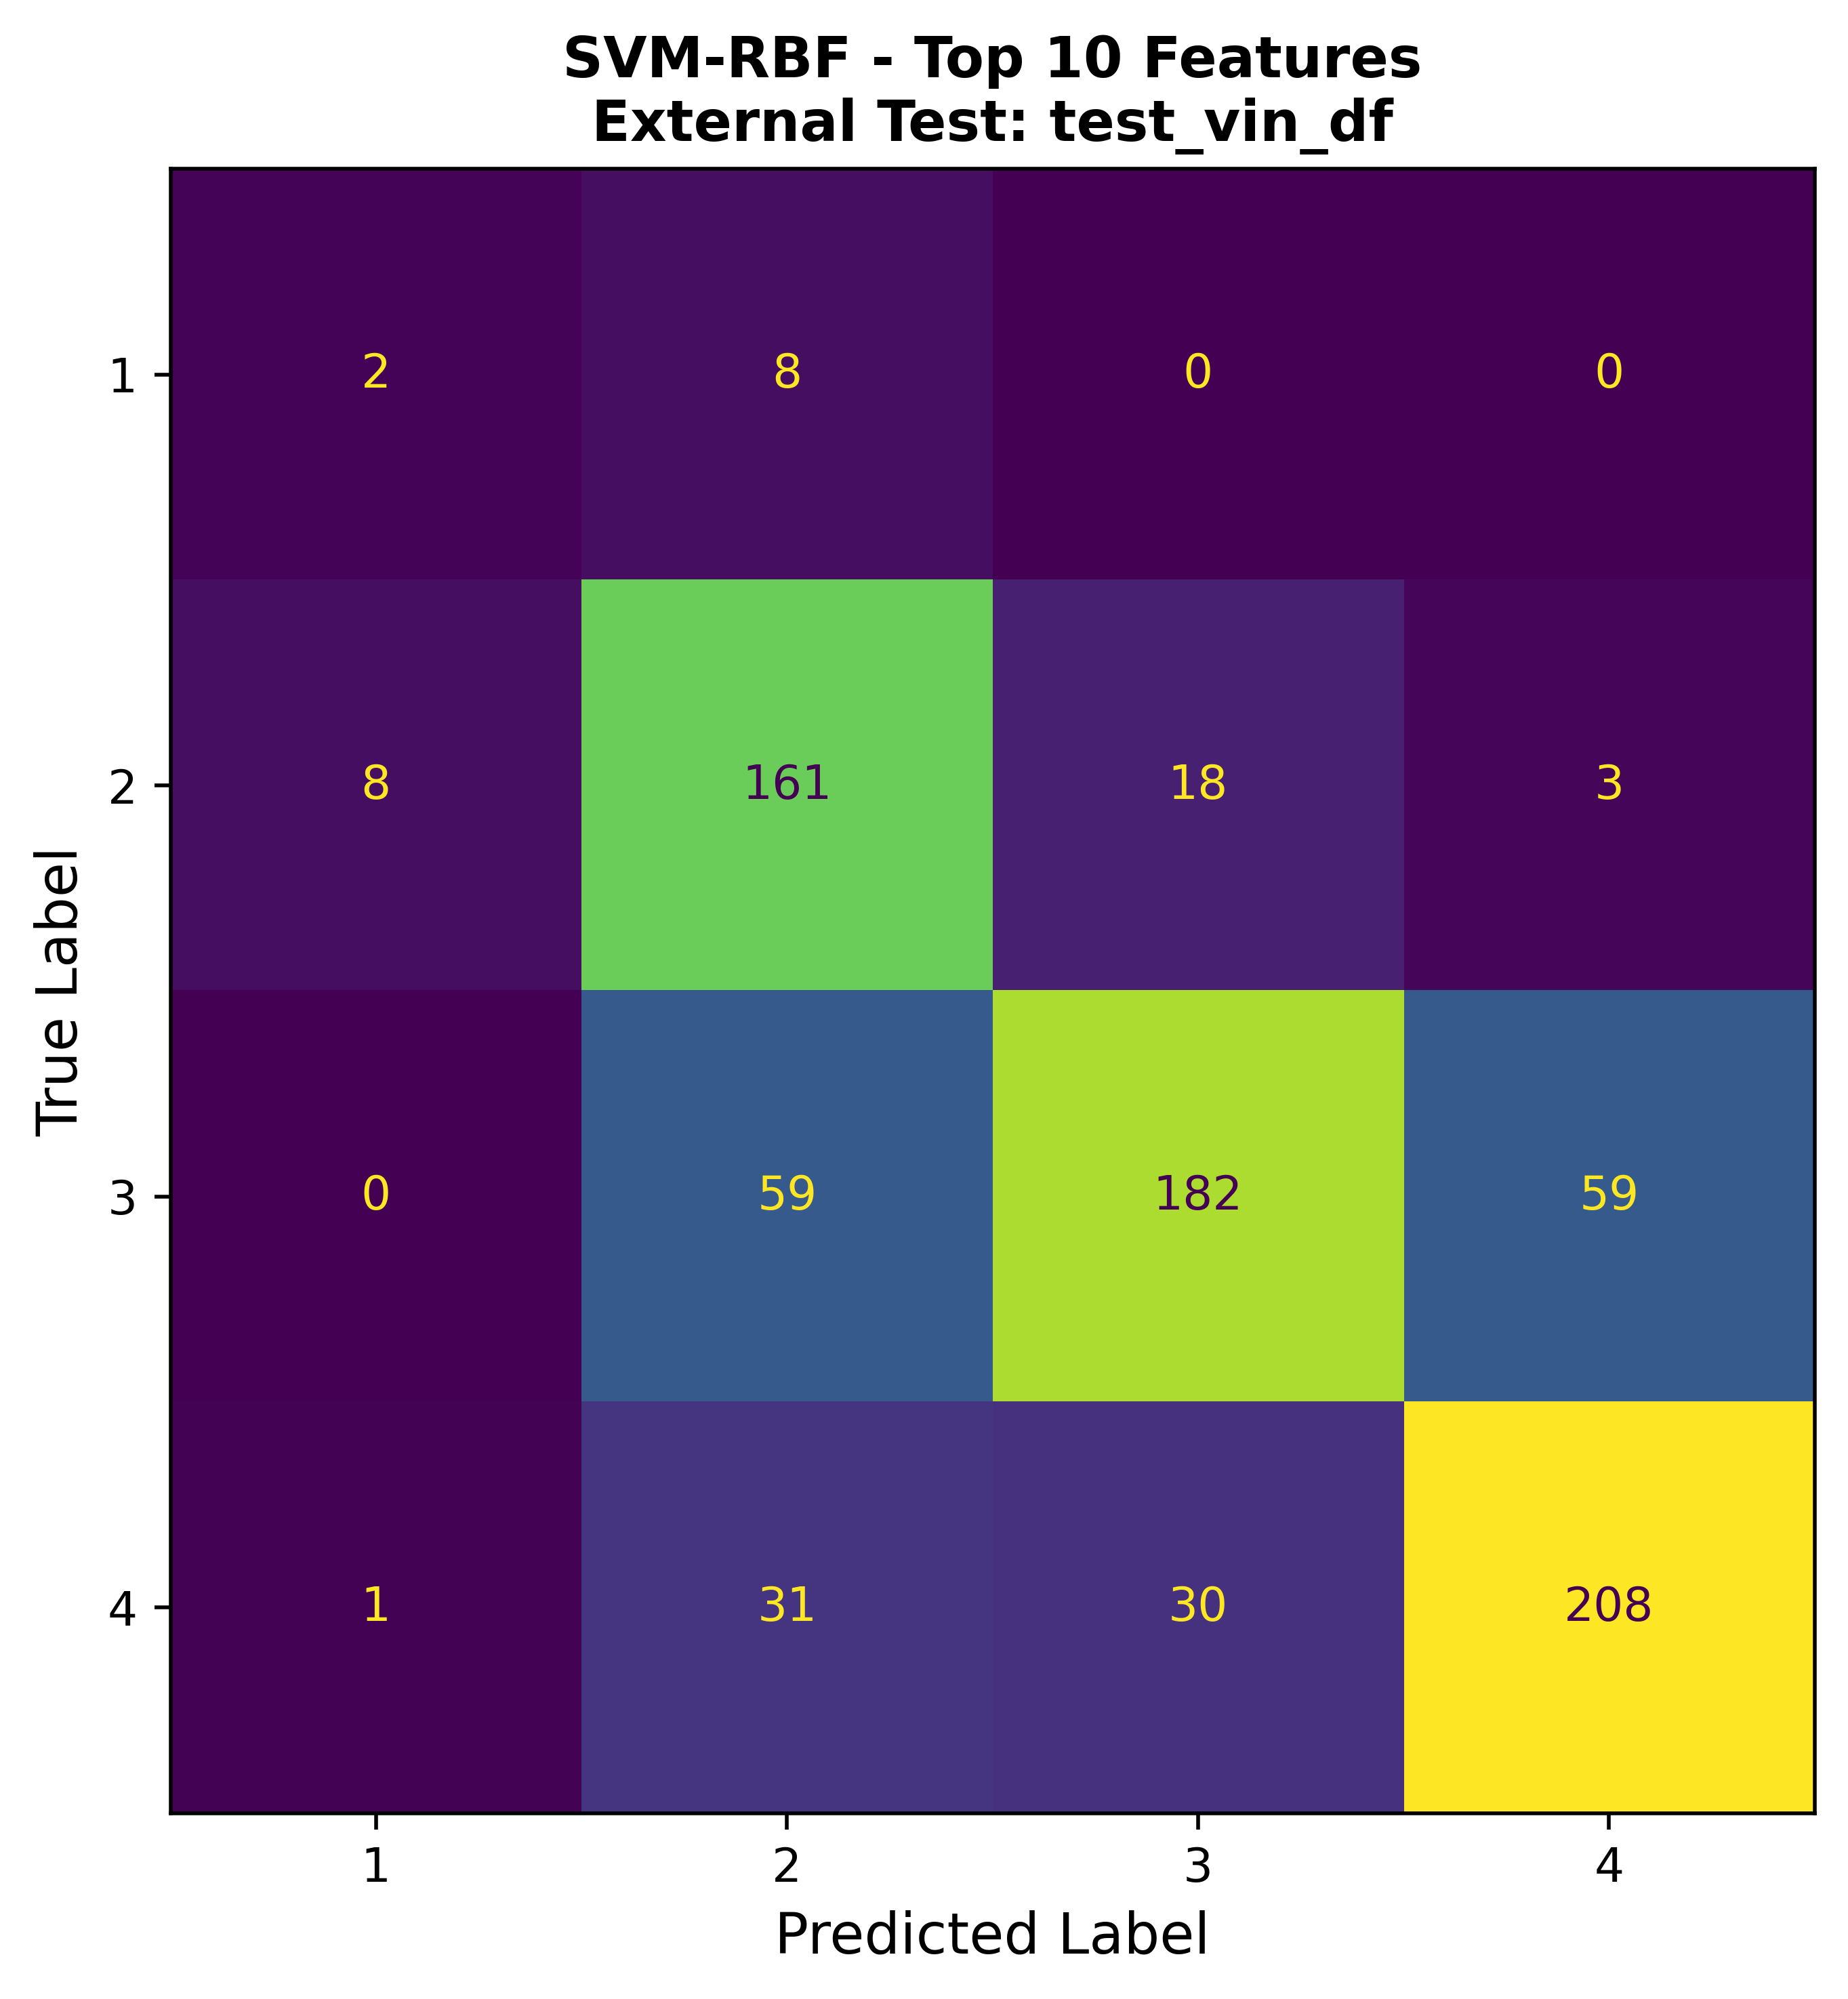

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. Select final Top-10 features
# ============================================================

selected_top10 = top10_features['Feature'].tolist()

print("Selected Top-10 Features:")

for i, feature in enumerate(
    selected_top10,
    start=1
):
    print(f"{i}. {feature}")


# ============================================================
# 2. Training Dataset: vin_df
# ============================================================

X_vin_df = vin_df[selected_top10]

y_vin_df = vin_df['ACR']


# ============================================================
# 3. External Test Dataset: test_vin_df
# ============================================================

X_test_top10 = test_vin_df[selected_top10]

y_test = test_vin_df['ACR']


# ============================================================
# 4. 5-Fold Stratified Cross Validation
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 5. SVM-RBF Pipeline
# ============================================================

svm_rbf = Pipeline([

    ('scaler', StandardScaler()),

    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale'
    ))
])


# ============================================================
# 6. Storage for CV metrics
# ============================================================

metrics = {

    'accuracy': [],

    'precision': [],

    'recall': [],

    'f1': []
}

fold_results = []


# ============================================================
# 7. 5-Fold Cross Validation on vin_df
# ============================================================

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_vin_df, y_vin_df),
    start=1
):

    print("\n" + "=" * 70)
    print(f"Fold {fold}")
    print("=" * 70)


    # --------------------------------------------------------
    # Train / Validation split
    # --------------------------------------------------------

    X_train = X_vin_df.iloc[train_idx]

    X_val = X_vin_df.iloc[val_idx]

    y_train = y_vin_df.iloc[train_idx]

    y_val = y_vin_df.iloc[val_idx]


    # --------------------------------------------------------
    # Train SVM-RBF
    # --------------------------------------------------------

    svm_rbf.fit(
        X_train,
        y_train
    )


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    y_pred = svm_rbf.predict(
        X_val
    )


    # ========================================================
    # Metrics
    # ========================================================

    accuracy = accuracy_score(
        y_val,
        y_pred
    )

    precision = precision_score(
        y_val,
        y_pred,
        average='weighted',
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred,
        average='weighted',
        zero_division=0
    )


    # ========================================================
    # Save metrics
    # ========================================================

    metrics['accuracy'].append(
        accuracy
    )

    metrics['precision'].append(
        precision
    )

    metrics['recall'].append(
        recall
    )

    metrics['f1'].append(
        f1
    )


    fold_results.append({

        'Fold': fold,

        'Accuracy': accuracy,

        'Precision': precision,

        'Recall': recall,

        'F1': f1
    })


# ============================================================
# 8. Fold-by-Fold CV Results
# ============================================================

results_df = pd.DataFrame(
    fold_results
)


print("\n" + "=" * 70)

print(
    "SVM-RBF - TOP 10 FEATURES"
)

print(
    "5-FOLD CROSS-VALIDATION ON vin_df"
)

print("=" * 70)


print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# 9. Mean ± SD
# ============================================================

summary = pd.DataFrame({

    'Metric': [

        'Accuracy',

        'Precision',

        'Recall',

        'F1-score'
    ],

    'Mean': [

        np.mean(
            metrics['accuracy']
        ),

        np.mean(
            metrics['precision']
        ),

        np.mean(
            metrics['recall']
        ),

        np.mean(
            metrics['f1']
        )
    ],

    'SD': [

        np.std(
            metrics['accuracy'],
            ddof=1
        ),

        np.std(
            metrics['precision'],
            ddof=1
        ),

        np.std(
            metrics['recall'],
            ddof=1
        ),

        np.std(
            metrics['f1'],
            ddof=1
        )
    ]
})


# ============================================================
# 10. Convert to Percentage
# ============================================================

summary['Mean (%)'] = (
    summary['Mean'] * 100
)

summary['SD (%)'] = (
    summary['SD'] * 100
)


summary['Mean ± SD'] = (

    summary['Mean (%)'].map(
        lambda x: f"{x:.2f}"
    )

    + " ± "

    + summary['SD (%)'].map(
        lambda x: f"{x:.2f}"
    )
)


# ============================================================
# 11. Final 5-Fold CV Performance
# ============================================================

print("\n" + "=" * 70)

print(
    "FINAL 5-FOLD CV PERFORMANCE"
)

print("=" * 70)


print(
    summary[
        ['Metric', 'Mean ± SD']
    ].to_string(
        index=False
    )
)


# ============================================================
# 12. Train Final Model on ALL vin_df
# ============================================================
# Important:
# After CV, train the final SVM on the complete vin_df.

final_svm_rbf = Pipeline([

    ('scaler', StandardScaler()),

    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale'
    ))
])


final_svm_rbf.fit(
    X_vin_df,
    y_vin_df
)


# ============================================================
# 13. External Test on test_vin_df
# ============================================================

y_test_pred = final_svm_rbf.predict(
    X_test_top10
)


# ============================================================
# 14. External Test Metrics
# ============================================================

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred,
    average='weighted',
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    average='weighted',
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    average='weighted',
    zero_division=0
)


# ============================================================
# 15. External Test Results
# ============================================================

print("\n" + "=" * 70)

print(
    "EXTERNAL TEST PERFORMANCE - test_vin_df"
)

print("=" * 70)

print(
    f"Accuracy : {test_accuracy:.4f}"
)

print(
    f"Precision: {test_precision:.4f}"
)

print(
    f"Recall   : {test_recall:.4f}"
)

print(
    f"F1-score : {test_f1:.4f}"
)


# ============================================================
# 16. Classification Report
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_test_pred,
        zero_division=0
    )
)


# ============================================================
# 17. Confusion Matrix - External Test
# ============================================================

cm = confusion_matrix(
    y_test,
    y_test_pred
)


print("\nConfusion Matrix - External Test:")

print(cm)


# ============================================================
# 18. Plot Confusion Matrix
# ============================================================

class_labels = np.unique(
    y_vin_df
)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_labels
)


fig, ax = plt.subplots(
    figsize=(7, 6),
    dpi=500
)


disp.plot(
    ax=ax,
    values_format='d',
    colorbar=False
)


plt.title(
    "SVM-RBF - Top 10 Features\n"
    "External Test: test_vin_df",
    fontsize=12,
    weight='bold'
)

plt.xlabel(
    "Predicted Label",
    fontsize=12
)

plt.ylabel(
    "True Label",
    fontsize=12
)

plt.xticks(
    fontsize=10
)

plt.yticks(
    fontsize=10
)

plt.tight_layout()

plt.show()

Selected Top-10 Features:
1. skewness2
2. homogeneity0_2_bin2_6
3. entropy0_50
4. entropy0_3_bin2_6
5. 4bin_pol5-4
6. entropy45_3_bin1_3
7. entropy0_40
8. entropy90_2_bin2_4
9. bin1_5_20_IMC1
10. ASM135_20_bin3_7


Testing Architecture: ANN_1L_8
Hidden Layers: (8,)


Testing Architecture: ANN_1L_16
Hidden Layers: (16,)


Testing Architecture: ANN_1L_32
Hidden Layers: (32,)


Testing Architecture: ANN_2L_16_8
Hidden Layers: (16, 8)


Testing Architecture: ANN_2L_32_16
Hidden Layers: (32, 16)


Testing Architecture: ANN_2L_64_32
Hidden Layers: (64, 32)


Testing Architecture: ANN_3L_32_16_8
Hidden Layers: (32, 16, 8)


Testing Architecture: ANN_3L_64_32_16
Hidden Layers: (64, 32, 16)


ANN ARCHITECTURE COMPARISON - 5-FOLD CV
   Architecture Hidden_Layers     Accuracy    Precision       Recall     F1-score
ANN_3L_64_32_16  (64, 32, 16) 72.77 ± 2.87 72.46 ± 3.27 72.77 ± 2.87 72.13 ± 2.68
   ANN_2L_64_32      (64, 32) 72.87 ± 1.99 72.42 ± 0.79 72.87 ± 1.99 71.81 ± 1.60
   ANN_2L_32_16      

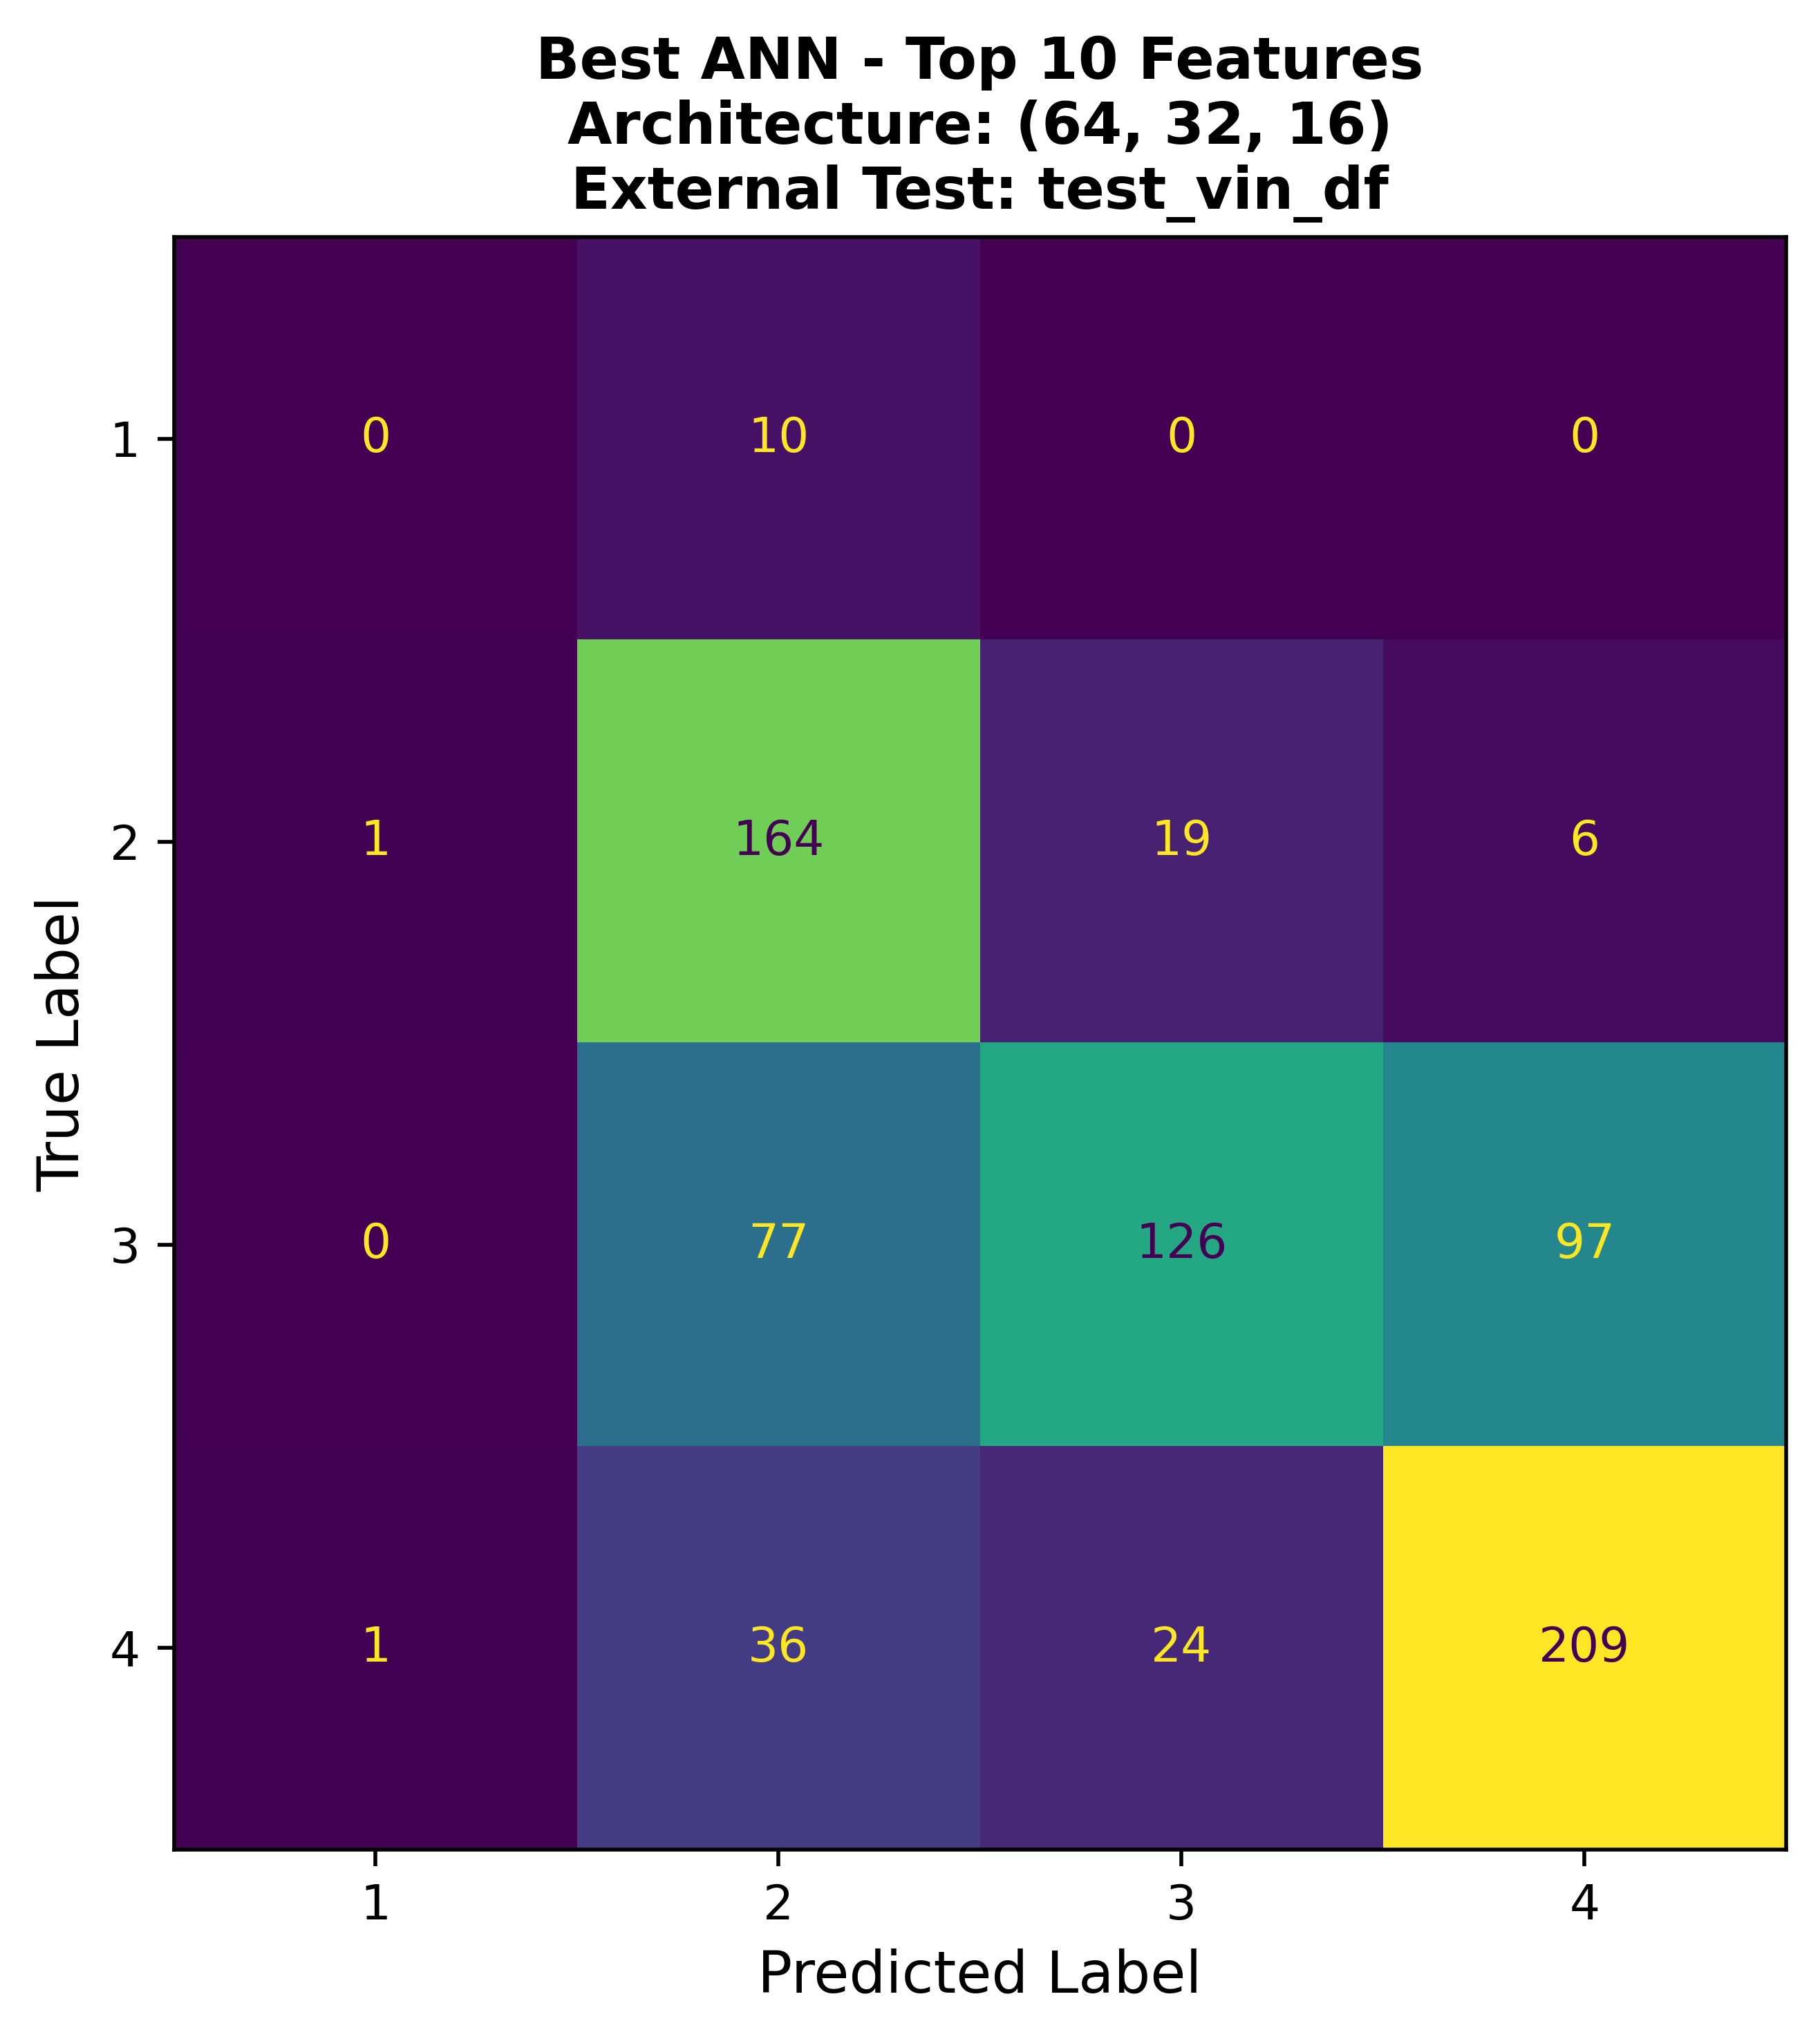

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. Select final Top-10 features
# ============================================================

selected_top10 = top10_features['Feature'].tolist()

print("Selected Top-10 Features:")

for i, feature in enumerate(
    selected_top10,
    start=1
):
    print(f"{i}. {feature}")


# ============================================================
# 2. Training Dataset: vin_df
# ============================================================

X_vin_df = vin_df[selected_top10]

y_vin_df = vin_df['ACR']


# ============================================================
# 3. External Test Dataset: test_vin_df
# ============================================================

X_test_top10 = test_vin_df[selected_top10]

y_test = test_vin_df['ACR']


# ============================================================
# 4. 5-Fold Stratified Cross Validation
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 5. Define ANN Architectures
# ============================================================
#
# hidden_layer_sizes:
#
# (8,)       -> 1 hidden layer
# (16,)      -> 1 hidden layer
# (32,)      -> 1 hidden layer
#
# (16, 8)    -> 2 hidden layers
# (32, 16)   -> 2 hidden layers
# (64, 32)   -> 2 hidden layers
#
# (32, 16, 8) -> 3 hidden layers
# (64, 32, 16)-> 3 hidden layers
#
# ============================================================

architectures = {

    'ANN_1L_8': (8,),

    'ANN_1L_16': (16,),

    'ANN_1L_32': (32,),

    'ANN_2L_16_8': (16, 8),

    'ANN_2L_32_16': (32, 16),

    'ANN_2L_64_32': (64, 32),

    'ANN_3L_32_16_8': (32, 16, 8),

    'ANN_3L_64_32_16': (64, 32, 16)
}


# ============================================================
# 6. Storage for all architecture results
# ============================================================

all_results = []

architecture_summary = []


# ============================================================
# 7. Evaluate each ANN architecture
# ============================================================

for architecture_name, hidden_layers in architectures.items():

    print("\n")
    print("=" * 80)
    print(f"Testing Architecture: {architecture_name}")
    print(f"Hidden Layers: {hidden_layers}")
    print("=" * 80)


    # --------------------------------------------------------
    # Create ANN Pipeline
    # --------------------------------------------------------

    ann = Pipeline([

        ('scaler', StandardScaler()),

        ('mlp', MLPClassifier(

            hidden_layer_sizes=hidden_layers,

            activation='relu',

            solver='adam',

            alpha=0.0001,

            learning_rate_init=0.001,

            max_iter=1000,

            early_stopping=True,

            validation_fraction=0.15,

            n_iter_no_change=30,

            random_state=42
        ))
    ])


    # --------------------------------------------------------
    # Storage for current architecture
    # --------------------------------------------------------

    accuracy_scores = []

    precision_scores = []

    recall_scores = []

    f1_scores = []


    # ========================================================
    # 5-Fold CV
    # ========================================================

    for fold, (train_idx, val_idx) in enumerate(
        skf.split(X_vin_df, y_vin_df),
        start=1
    ):


        # ----------------------------------------------------
        # Train / Validation split
        # ----------------------------------------------------

        X_train = X_vin_df.iloc[train_idx]

        X_val = X_vin_df.iloc[val_idx]

        y_train = y_vin_df.iloc[train_idx]

        y_val = y_vin_df.iloc[val_idx]


        # ----------------------------------------------------
        # Train ANN
        # ----------------------------------------------------

        ann.fit(
            X_train,
            y_train
        )


        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        y_pred = ann.predict(
            X_val
        )


        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        accuracy = accuracy_score(
            y_val,
            y_pred
        )

        precision = precision_score(
            y_val,
            y_pred,
            average='weighted',
            zero_division=0
        )

        recall = recall_score(
            y_val,
            y_pred,
            average='weighted',
            zero_division=0
        )

        f1 = f1_score(
            y_val,
            y_pred,
            average='weighted',
            zero_division=0
        )


        # ----------------------------------------------------
        # Save scores
        # ----------------------------------------------------

        accuracy_scores.append(
            accuracy
        )

        precision_scores.append(
            precision
        )

        recall_scores.append(
            recall
        )

        f1_scores.append(
            f1
        )


        # ----------------------------------------------------
        # Save fold result
        # ----------------------------------------------------

        all_results.append({

            'Architecture': architecture_name,

            'Hidden_Layers': str(hidden_layers),

            'Fold': fold,

            'Accuracy': accuracy,

            'Precision': precision,

            'Recall': recall,

            'F1': f1
        })


    # ========================================================
    # Mean ± SD for current architecture
    # ========================================================

    mean_accuracy = np.mean(
        accuracy_scores
    )

    sd_accuracy = np.std(
        accuracy_scores,
        ddof=1
    )


    mean_precision = np.mean(
        precision_scores
    )

    sd_precision = np.std(
        precision_scores,
        ddof=1
    )


    mean_recall = np.mean(
        recall_scores
    )

    sd_recall = np.std(
        recall_scores,
        ddof=1
    )


    mean_f1 = np.mean(
        f1_scores
    )

    sd_f1 = np.std(
        f1_scores,
        ddof=1
    )


    # ========================================================
    # Save architecture summary
    # ========================================================

    architecture_summary.append({

        'Architecture': architecture_name,

        'Hidden_Layers': str(hidden_layers),

        'Accuracy_Mean': mean_accuracy,

        'Accuracy_SD': sd_accuracy,

        'Precision_Mean': mean_precision,

        'Precision_SD': sd_precision,

        'Recall_Mean': mean_recall,

        'Recall_SD': sd_recall,

        'F1_Mean': mean_f1,

        'F1_SD': sd_f1
    })


# ============================================================
# 8. Create Summary DataFrame
# ============================================================

architecture_results = pd.DataFrame(
    architecture_summary
)


# ============================================================
# 9. Sort architectures by Mean F1
# ============================================================

architecture_results = architecture_results.sort_values(
    by='F1_Mean',
    ascending=False
).reset_index(drop=True)


# ============================================================
# 10. Display Architecture Comparison
# ============================================================

print("\n")
print("=" * 100)
print("ANN ARCHITECTURE COMPARISON - 5-FOLD CV")
print("=" * 100)


display_table = architecture_results.copy()


display_table['Accuracy'] = (

    display_table['Accuracy_Mean'] * 100
).map(
    lambda x: f"{x:.2f}"
) + " ± " + (

    display_table['Accuracy_SD'] * 100
).map(
    lambda x: f"{x:.2f}"
)


display_table['Precision'] = (

    display_table['Precision_Mean'] * 100
).map(
    lambda x: f"{x:.2f}"
) + " ± " + (

    display_table['Precision_SD'] * 100
).map(
    lambda x: f"{x:.2f}"
)


display_table['Recall'] = (

    display_table['Recall_Mean'] * 100
).map(
    lambda x: f"{x:.2f}"
) + " ± " + (

    display_table['Recall_SD'] * 100
).map(
    lambda x: f"{x:.2f}"
)


display_table['F1-score'] = (

    display_table['F1_Mean'] * 100
).map(
    lambda x: f"{x:.2f}"
) + " ± " + (

    display_table['F1_SD'] * 100
).map(
    lambda x: f"{x:.2f}"
)


print(
    display_table[
        [
            'Architecture',
            'Hidden_Layers',
            'Accuracy',
            'Precision',
            'Recall',
            'F1-score'
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# 11. Select BEST Architecture
# ============================================================
# Selection criterion:
# Highest Mean F1-score across 5 folds

best_architecture_row = architecture_results.iloc[0]


best_architecture_name = (
    best_architecture_row['Architecture']
)


best_hidden_layers = eval(
    best_architecture_row['Hidden_Layers']
)


best_cv_f1 = (
    best_architecture_row['F1_Mean']
)


best_cv_f1_sd = (
    best_architecture_row['F1_SD']
)


print("\n")
print("=" * 80)
print("BEST ANN ARCHITECTURE")
print("=" * 80)


print(
    f"Architecture: {best_architecture_name}"
)


print(
    f"Hidden Layers: {best_hidden_layers}"
)


print(
    f"Mean F1-score: "
    f"{best_cv_f1 * 100:.2f} ± "
    f"{best_cv_f1_sd * 100:.2f}%"
)


# ============================================================
# 12. Train BEST ANN on ALL vin_df
# ============================================================

final_ann = Pipeline([

    ('scaler', StandardScaler()),

    ('mlp', MLPClassifier(

        hidden_layer_sizes=best_hidden_layers,

        activation='relu',

        solver='adam',

        alpha=0.0001,

        learning_rate_init=0.001,

        max_iter=1000,

        early_stopping=True,

        validation_fraction=0.15,

        n_iter_no_change=30,

        random_state=42
    ))
])


print("\n")
print("=" * 80)
print("TRAINING FINAL ANN ON ALL vin_df")
print("=" * 80)


final_ann.fit(
    X_vin_df,
    y_vin_df
)


# ============================================================
# 13. External Test on test_vin_df
# ============================================================

y_test_pred = final_ann.predict(
    X_test_top10
)


# ============================================================
# 14. External Test Metrics
# ============================================================

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)


test_precision = precision_score(
    y_test,
    y_test_pred,
    average='weighted',
    zero_division=0
)


test_recall = recall_score(
    y_test,
    y_test_pred,
    average='weighted',
    zero_division=0
)


test_f1 = f1_score(
    y_test,
    y_test_pred,
    average='weighted',
    zero_division=0
)


# ============================================================
# 15. External Test Results
# ============================================================

print("\n")
print("=" * 80)
print("EXTERNAL TEST PERFORMANCE")
print("=" * 80)


print(
    f"Selected Architecture: "
    f"{best_architecture_name}"
)


print(
    f"Hidden Layers: "
    f"{best_hidden_layers}"
)


print(
    f"Accuracy : {test_accuracy * 100:.2f}%"
)


print(
    f"Precision: {test_precision * 100:.2f}%"
)


print(
    f"Recall   : {test_recall * 100:.2f}%"
)


print(
    f"F1-score : {test_f1 * 100:.2f}%"
)


# ============================================================
# 16. Classification Report
# ============================================================

print("\n")
print("=" * 80)
print("CLASSIFICATION REPORT - EXTERNAL TEST")
print("=" * 80)


print(
    classification_report(
        y_test,
        y_test_pred,
        zero_division=0
    )
)


# ============================================================
# 17. Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    y_test_pred
)


print("\n")
print("=" * 80)
print("CONFUSION MATRIX - EXTERNAL TEST")
print("=" * 80)


print(cm)


# ============================================================
# 18. Plot Confusion Matrix
# ============================================================

class_labels = np.unique(
    y_vin_df
)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_labels
)


fig, ax = plt.subplots(
    figsize=(7, 6),
    dpi=500
)


disp.plot(
    ax=ax,
    values_format='d',
    colorbar=False
)


plt.title(
    f"Best ANN - Top 10 Features\n"
    f"Architecture: {best_hidden_layers}\n"
    f"External Test: test_vin_df",
    fontsize=12,
    weight='bold'
)


plt.xlabel(
    "Predicted Label",
    fontsize=12
)


plt.ylabel(
    "True Label",
    fontsize=12
)


plt.xticks(
    fontsize=10
)


plt.yticks(
    fontsize=10
)


plt.tight_layout()

plt.show()

# with 25 top selected features

Selected Top-25 Features:
1. skewness2
2. homogeneity0_2_bin2_6
3. entropy0_50
4. entropy0_3_bin2_6
5. 4bin_pol5-4
6. entropy45_3_bin1_3
7. entropy0_40
8. entropy90_2_bin2_4
9. entropy45_3_bin1_6
10. bin1_5_20_IMC1
11. homogeneity45_2_bin6_6
12. ASM135_20_bin3_7
13. bin2 to 3_area3max
14. bin1_7_maxisland
15. bin3 to 7_maxisland
16. bin3 to 6_meanof3max
17. bin6_6_40_sumvar
18. 8bin-pol7_1
19. 64bin-pol6_1
20. contrast0_30_bin1_3
21. 7bin_pol3-3
22. correlation0_30_bin1_3
23. ASM90_30_bin1_3
24. contrast45_5_bin1_3
25. pol5-6_256

Fold 1

Fold 2

Fold 3

Fold 4

Fold 5

SVM-RBF - TOP 25 FEATURES
5-FOLD CROSS-VALIDATION ON vin_df
 Fold  Accuracy  Precision   Recall       F1
    1  0.734043   0.729905 0.734043 0.724407
    2  0.760638   0.725754 0.760638 0.741615
    3  0.739362   0.707129 0.739362 0.721932
    4  0.696809   0.686573 0.696809 0.688719
    5  0.765957   0.735942 0.765957 0.748466

FINAL 5-FOLD CV PERFORMANCE - SVM-RBF
   Metric    Mean ± SD
 Accuracy 73.94 ± 2.74
Precisio

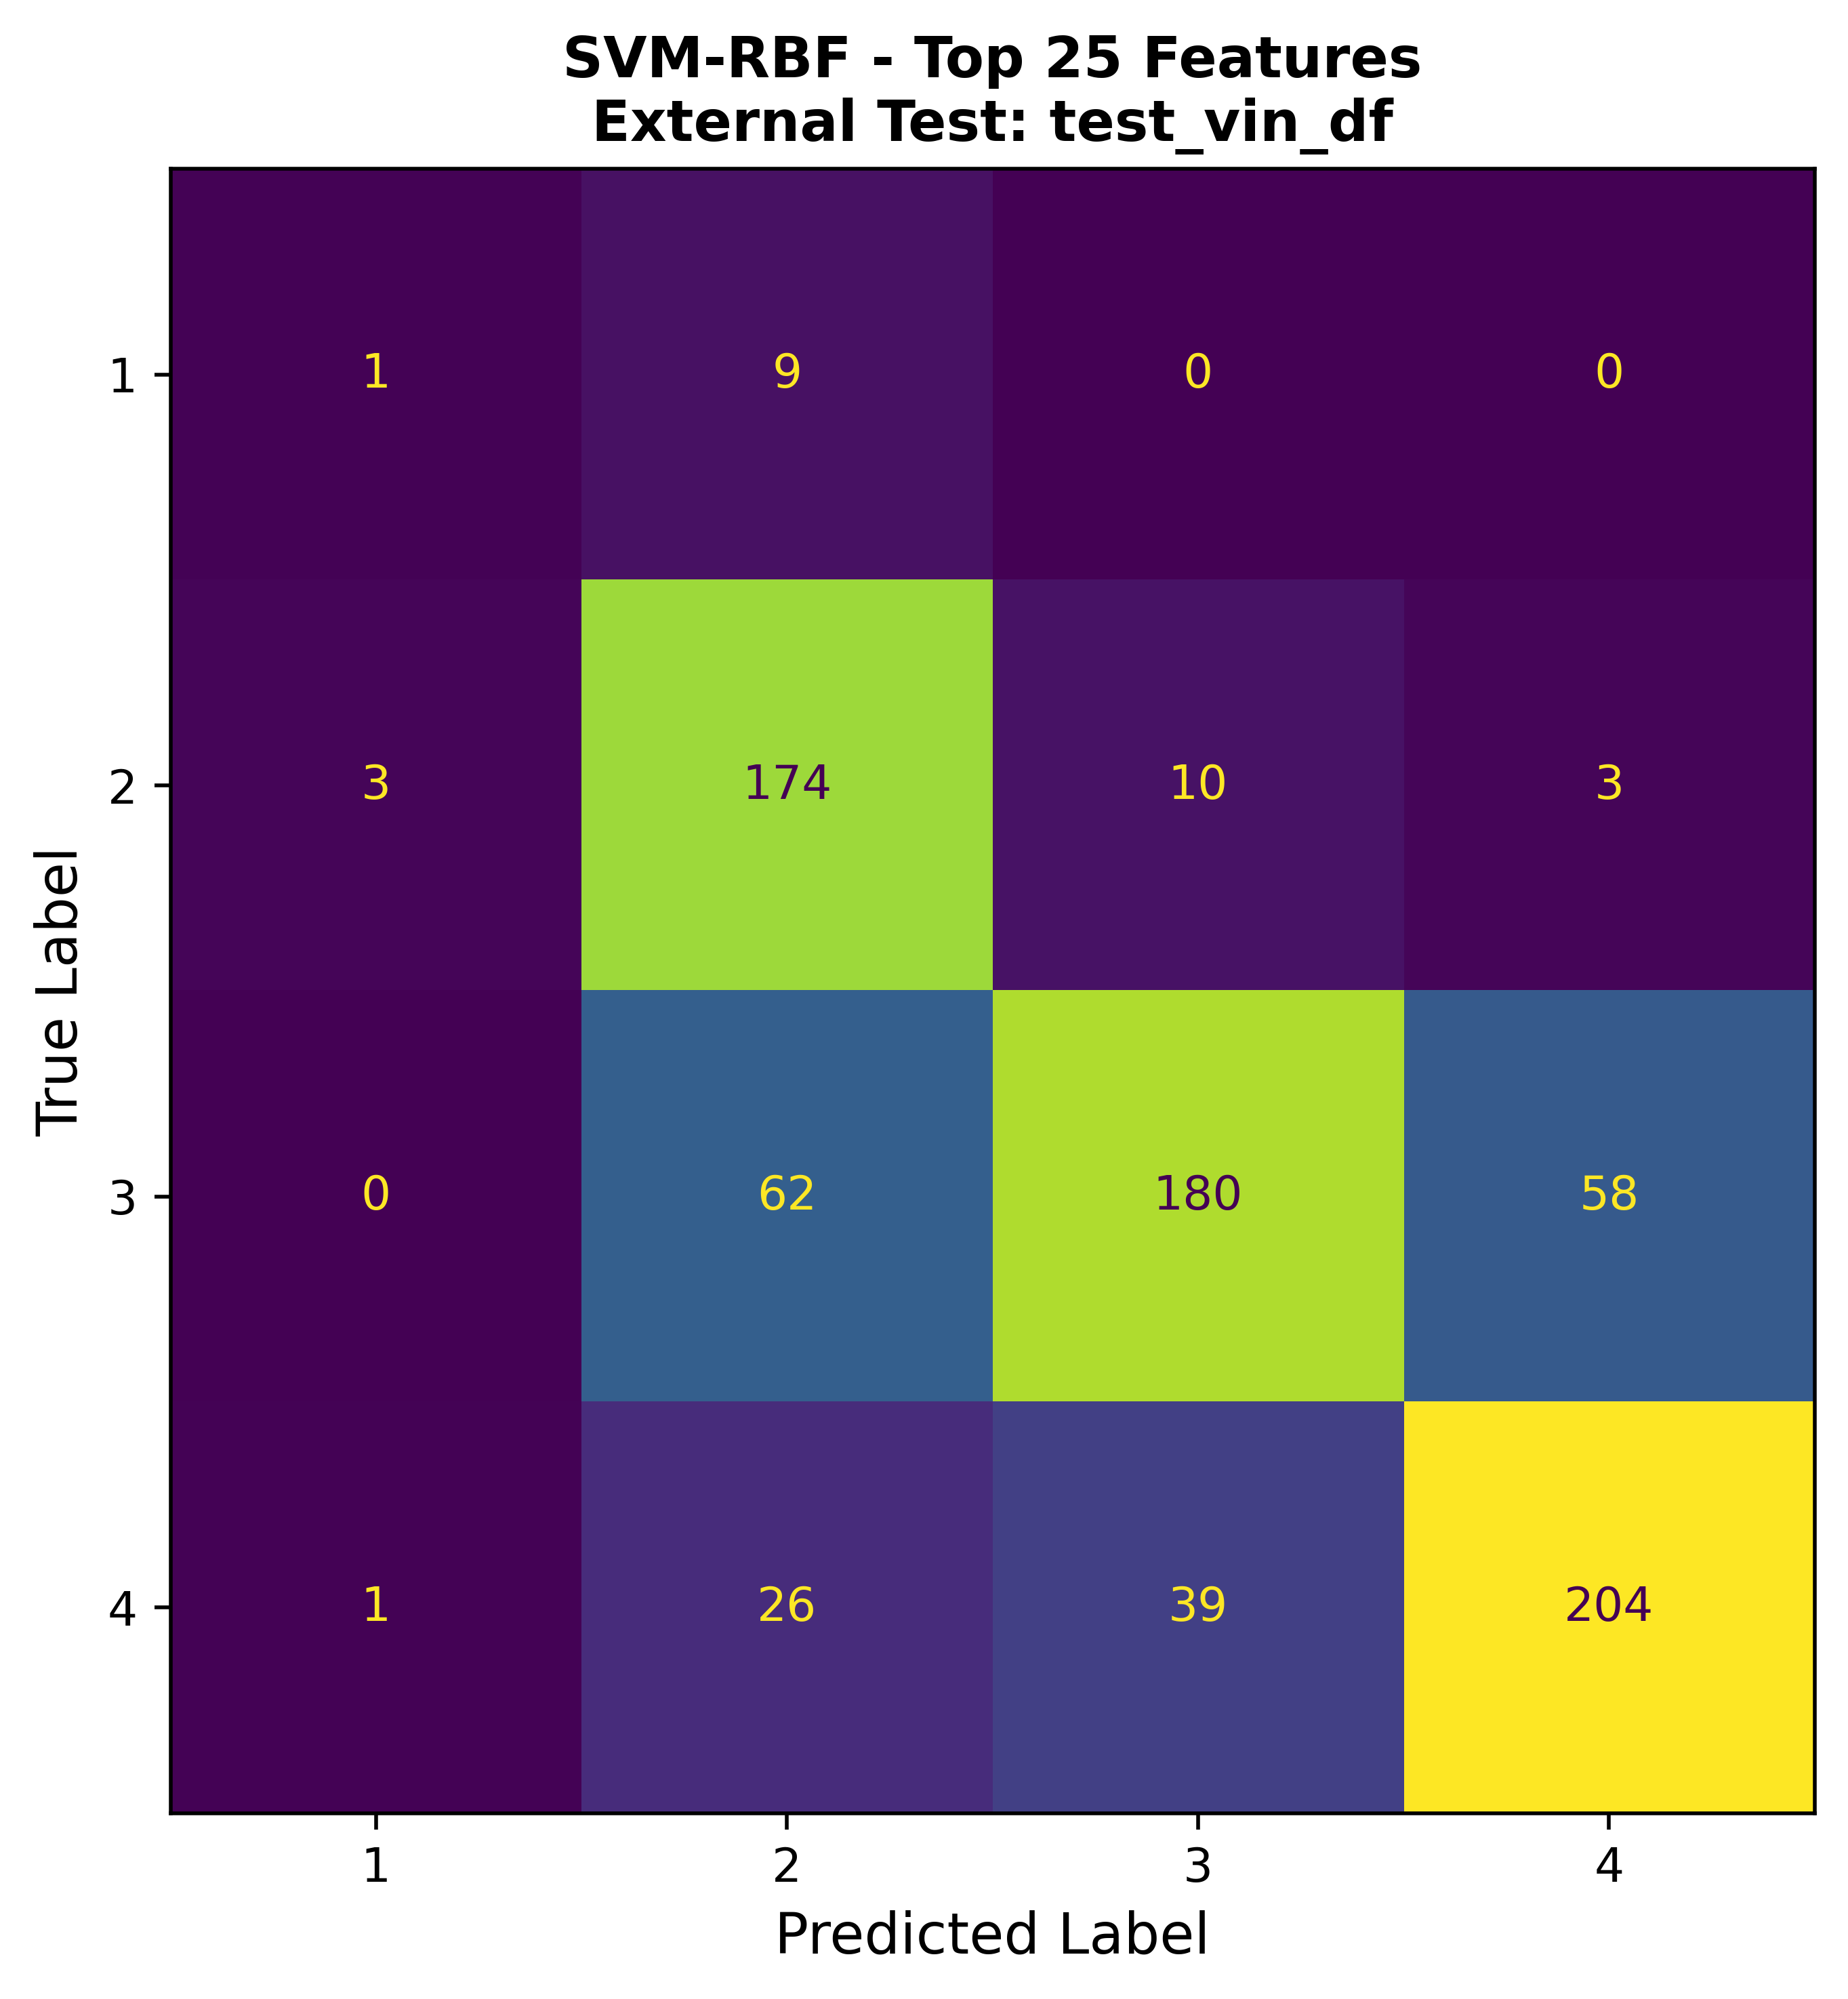

In [37]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. Select final Top-25 features
# ============================================================

selected_top25 = top25_features['Feature'].tolist()

print("Selected Top-25 Features:")

for i, feature in enumerate(
    selected_top25,
    start=1
):
    print(f"{i}. {feature}")


# ============================================================
# 2. Training Dataset: vin_df
# ============================================================

X_vin_df = vin_df[selected_top25]

y_vin_df = vin_df['ACR']


# ============================================================
# 3. External Test Dataset: test_vin_df
# ============================================================

X_test_top25 = test_vin_df[selected_top25]

y_test = test_vin_df['ACR']


# ============================================================
# 4. 5-Fold Stratified Cross Validation
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 5. SVM-RBF Pipeline
# ============================================================
# StandardScaler is fitted separately inside each Fold.
# This prevents data leakage.

svm_rbf = Pipeline([

    ('scaler', StandardScaler()),

    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale'
    ))
])


# ============================================================
# 6. Storage for CV metrics
# ============================================================

metrics = {

    'accuracy': [],

    'precision': [],

    'recall': [],

    'f1': []
}

fold_results = []


# ============================================================
# 7. 5-Fold Cross Validation on vin_df
# ============================================================

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_vin_df, y_vin_df),
    start=1
):

    print("\n" + "=" * 70)
    print(f"Fold {fold}")
    print("=" * 70)


    # --------------------------------------------------------
    # Train / Validation split
    # --------------------------------------------------------

    X_train = X_vin_df.iloc[train_idx]

    X_val = X_vin_df.iloc[val_idx]

    y_train = y_vin_df.iloc[train_idx]

    y_val = y_vin_df.iloc[val_idx]


    # --------------------------------------------------------
    # Train SVM-RBF
    # --------------------------------------------------------

    svm_rbf.fit(
        X_train,
        y_train
    )


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    y_pred = svm_rbf.predict(
        X_val
    )


    # ========================================================
    # Metrics
    # ========================================================

    accuracy = accuracy_score(
        y_val,
        y_pred
    )

    precision = precision_score(
        y_val,
        y_pred,
        average='weighted',
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred,
        average='weighted',
        zero_division=0
    )


    # ========================================================
    # Save metrics
    # ========================================================

    metrics['accuracy'].append(
        accuracy
    )

    metrics['precision'].append(
        precision
    )

    metrics['recall'].append(
        recall
    )

    metrics['f1'].append(
        f1
    )


    fold_results.append({

        'Fold': fold,

        'Accuracy': accuracy,

        'Precision': precision,

        'Recall': recall,

        'F1': f1
    })


# ============================================================
# 8. Fold-by-Fold CV Results
# ============================================================

results_df = pd.DataFrame(
    fold_results
)


print("\n" + "=" * 70)

print(
    "SVM-RBF - TOP 25 FEATURES"
)

print(
    "5-FOLD CROSS-VALIDATION ON vin_df"
)

print("=" * 70)


print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# 9. Mean ± SD
# ============================================================

summary = pd.DataFrame({

    'Metric': [

        'Accuracy',

        'Precision',

        'Recall',

        'F1-score'
    ],

    'Mean': [

        np.mean(
            metrics['accuracy']
        ),

        np.mean(
            metrics['precision']
        ),

        np.mean(
            metrics['recall']
        ),

        np.mean(
            metrics['f1']
        )
    ],

    'SD': [

        np.std(
            metrics['accuracy'],
            ddof=1
        ),

        np.std(
            metrics['precision'],
            ddof=1
        ),

        np.std(
            metrics['recall'],
            ddof=1
        ),

        np.std(
            metrics['f1'],
            ddof=1
        )
    ]
})


# ============================================================
# 10. Convert to Percentage
# ============================================================

summary['Mean (%)'] = (
    summary['Mean'] * 100
)

summary['SD (%)'] = (
    summary['SD'] * 100
)


summary['Mean ± SD'] = (

    summary['Mean (%)'].map(
        lambda x: f"{x:.2f}"
    )

    + " ± "

    + summary['SD (%)'].map(
        lambda x: f"{x:.2f}"
    )
)


# ============================================================
# 11. Final 5-Fold CV Performance
# ============================================================

print("\n" + "=" * 70)

print(
    "FINAL 5-FOLD CV PERFORMANCE - SVM-RBF"
)

print("=" * 70)


print(
    summary[
        ['Metric', 'Mean ± SD']
    ].to_string(
        index=False
    )
)


# ============================================================
# 12. Train Final SVM on ALL vin_df
# ============================================================
# Important:
# After CV, train the final SVM using all training data.

final_svm_rbf = Pipeline([

    ('scaler', StandardScaler()),

    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale'
    ))
])


final_svm_rbf.fit(
    X_vin_df,
    y_vin_df
)


# ============================================================
# 13. External Test on test_vin_df
# ============================================================

y_test_pred = final_svm_rbf.predict(
    X_test_top25
)


# ============================================================
# 14. External Test Metrics
# ============================================================

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred,
    average='weighted',
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    average='weighted',
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    average='weighted',
    zero_division=0
)


# ============================================================
# 15. External Test Results
# ============================================================

print("\n" + "=" * 70)

print(
    "EXTERNAL TEST PERFORMANCE - SVM-RBF - TOP 25 FEATURES"
)

print("=" * 70)

print(
    f"Accuracy : {test_accuracy:.4f}"
)

print(
    f"Precision: {test_precision:.4f}"
)

print(
    f"Recall   : {test_recall:.4f}"
)

print(
    f"F1-score : {test_f1:.4f}"
)


# ============================================================
# 16. Classification Report
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_test_pred,
        zero_division=0
    )
)


# ============================================================
# 17. Confusion Matrix - External Test
# ============================================================

cm = confusion_matrix(
    y_test,
    y_test_pred
)


print("\nConfusion Matrix - External Test:")

print(cm)


# ============================================================
# 18. Plot Confusion Matrix
# ============================================================

class_labels = np.unique(
    y_vin_df
)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_labels
)


fig, ax = plt.subplots(
    figsize=(7, 6),
    dpi=500
)


disp.plot(
    ax=ax,
    values_format='d',
    colorbar=False
)


plt.title(
    "SVM-RBF - Top 25 Features\n"
    "External Test: test_vin_df",
    fontsize=12,
    weight='bold'
)


plt.xlabel(
    "Predicted Label",
    fontsize=12
)


plt.ylabel(
    "True Label",
    fontsize=12
)


plt.xticks(
    fontsize=10
)


plt.yticks(
    fontsize=10
)


plt.tight_layout()

plt.show()



# Hyperparameter Optimization

Selected Top-25 Features:
1. skewness2
2. homogeneity0_2_bin2_6
3. entropy0_50
4. entropy0_3_bin2_6
5. 4bin_pol5-4
6. entropy45_3_bin1_3
7. entropy0_40
8. entropy90_2_bin2_4
9. entropy45_3_bin1_6
10. bin1_5_20_IMC1
11. homogeneity45_2_bin6_6
12. ASM135_20_bin3_7
13. bin2 to 3_area3max
14. bin1_7_maxisland
15. bin3 to 7_maxisland
16. bin3 to 6_meanof3max
17. bin6_6_40_sumvar
18. 8bin-pol7_1
19. 64bin-pol6_1
20. contrast0_30_bin1_3
21. 7bin_pol3-3
22. correlation0_30_bin1_3
23. ASM90_30_bin1_3
24. contrast45_5_bin1_3
25. pol5-6_256


Testing Architecture: ANN_1L_8
Hidden Layers: (8,)


Testing Architecture: ANN_1L_16
Hidden Layers: (16,)


Testing Architecture: ANN_1L_32
Hidden Layers: (32,)


Testing Architecture: ANN_2L_16_8
Hidden Layers: (16, 8)


Testing Architecture: ANN_2L_32_16
Hidden Layers: (32, 16)


Testing Architecture: ANN_2L_64_32
Hidden Layers: (64, 32)


Testing Architecture: ANN_3L_32_16_8
Hidden Layers: (32, 16, 8)


Testing Architecture: ANN_3L_64_32_16
Hidden Layers:

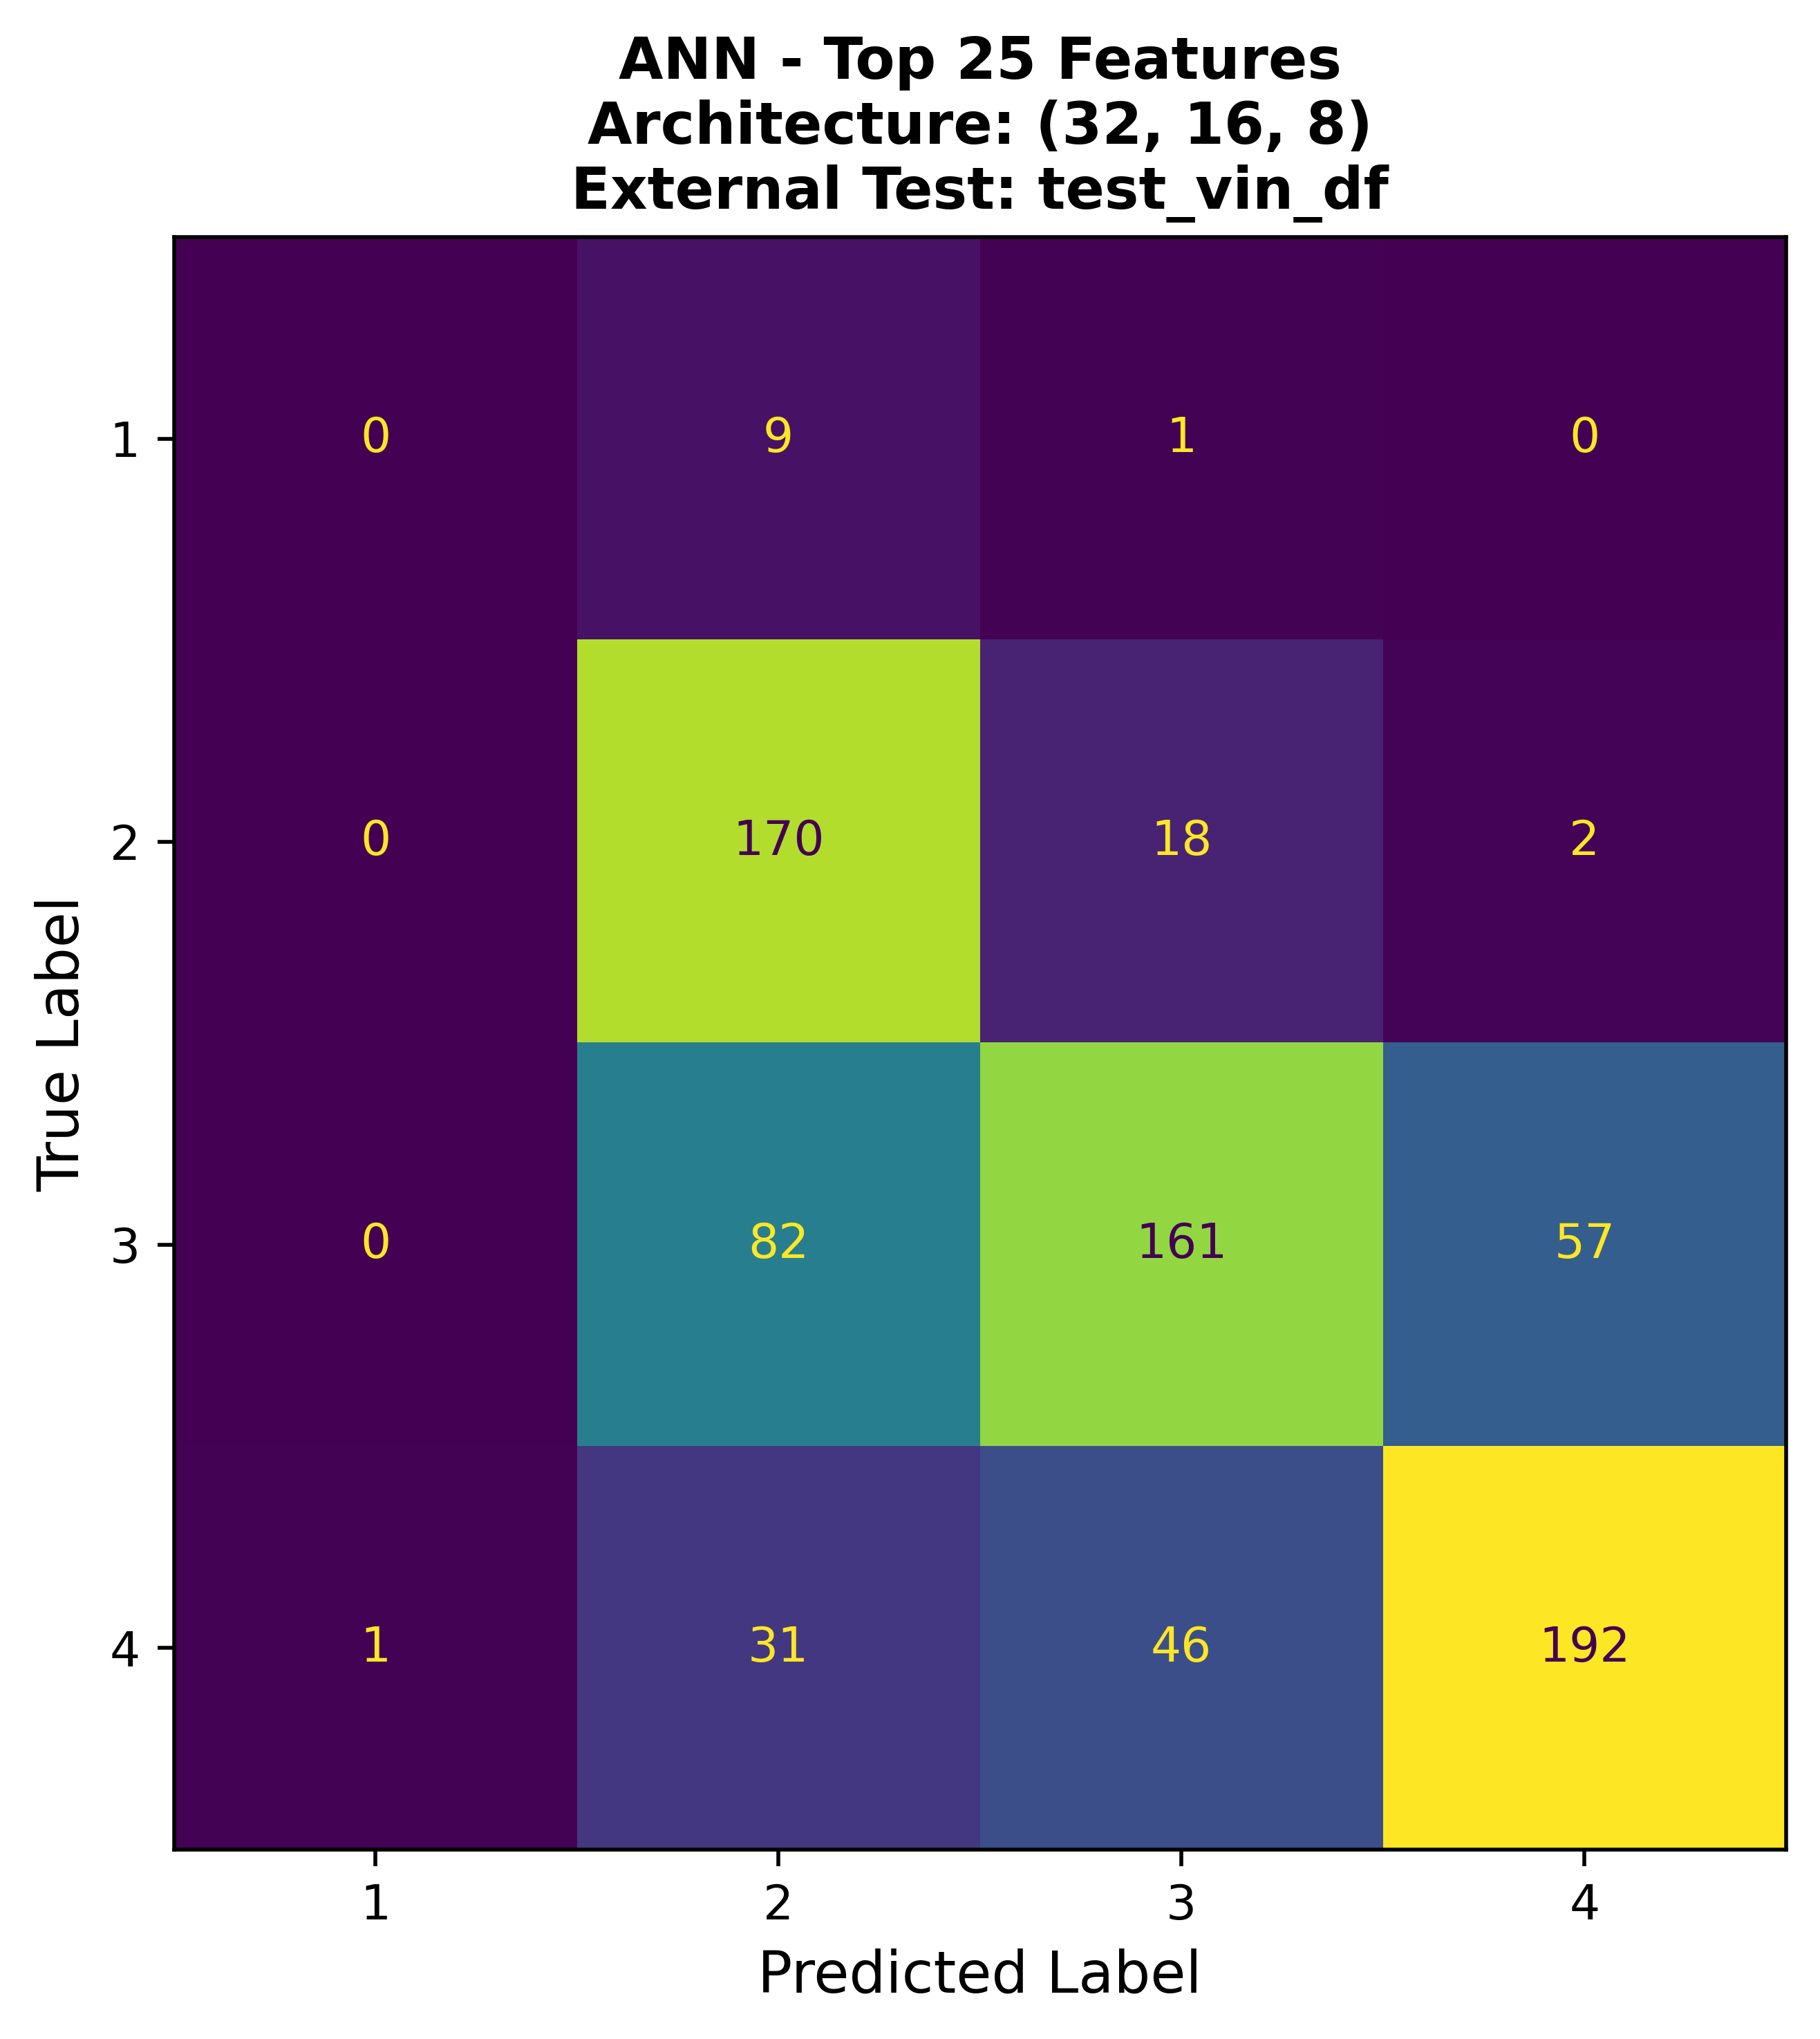

In [36]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. Select final Top-25 features
# ============================================================

selected_top25 = top25_features['Feature'].tolist()

print("Selected Top-25 Features:")

for i, feature in enumerate(
    selected_top25,
    start=1
):
    print(f"{i}. {feature}")


# ============================================================
# 2. Training Dataset: vin_df
# ============================================================

X_vin_df = vin_df[selected_top25]

y_vin_df = vin_df['ACR']


# ============================================================
# 3. External Test Dataset: test_vin_df
# ============================================================

X_test_top25 = test_vin_df[selected_top25]

y_test = test_vin_df['ACR']


# ============================================================
# 4. 5-Fold Stratified Cross Validation
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 5. ANN Architectures
# ============================================================

architectures = {

    'ANN_1L_8': (8,),

    'ANN_1L_16': (16,),

    'ANN_1L_32': (32,),

    'ANN_2L_16_8': (16, 8),

    'ANN_2L_32_16': (32, 16),

    'ANN_2L_64_32': (64, 32),

    'ANN_3L_32_16_8': (32, 16, 8),

    'ANN_3L_64_32_16': (64, 32, 16)
}


# ============================================================
# 6. Storage
# ============================================================

all_results = []

architecture_summary = []


# ============================================================
# 7. Evaluate Each ANN Architecture
# ============================================================

for architecture_name, hidden_layers in architectures.items():

    print("\n")
    print("=" * 80)
    print(f"Testing Architecture: {architecture_name}")
    print(f"Hidden Layers: {hidden_layers}")
    print("=" * 80)


    # --------------------------------------------------------
    # ANN Pipeline
    # --------------------------------------------------------

    ann = Pipeline([

        ('scaler', StandardScaler()),

        ('mlp', MLPClassifier(

            hidden_layer_sizes=hidden_layers,

            activation='relu',

            solver='adam',

            alpha=0.0001,

            learning_rate_init=0.001,

            max_iter=1000,

            early_stopping=True,

            validation_fraction=0.15,

            n_iter_no_change=30,

            random_state=42
        ))
    ])


    # --------------------------------------------------------
    # Storage for current architecture
    # --------------------------------------------------------

    accuracy_scores = []

    precision_scores = []

    recall_scores = []

    f1_scores = []


    # ========================================================
    # 5-Fold Cross Validation
    # ========================================================

    for fold, (train_idx, val_idx) in enumerate(
        skf.split(X_vin_df, y_vin_df),
        start=1
    ):

        # ----------------------------------------------------
        # Train / Validation
        # ----------------------------------------------------

        X_train = X_vin_df.iloc[train_idx]

        X_val = X_vin_df.iloc[val_idx]

        y_train = y_vin_df.iloc[train_idx]

        y_val = y_vin_df.iloc[val_idx]


        # ----------------------------------------------------
        # Train ANN
        # ----------------------------------------------------

        ann.fit(
            X_train,
            y_train
        )


        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        y_pred = ann.predict(
            X_val
        )


        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        accuracy = accuracy_score(
            y_val,
            y_pred
        )

        precision = precision_score(
            y_val,
            y_pred,
            average='weighted',
            zero_division=0
        )

        recall = recall_score(
            y_val,
            y_pred,
            average='weighted',
            zero_division=0
        )

        f1 = f1_score(
            y_val,
            y_pred,
            average='weighted',
            zero_division=0
        )


        # ----------------------------------------------------
        # Save
        # ----------------------------------------------------

        accuracy_scores.append(
            accuracy
        )

        precision_scores.append(
            precision
        )

        recall_scores.append(
            recall
        )

        f1_scores.append(
            f1
        )


        all_results.append({

            'Architecture': architecture_name,

            'Hidden_Layers': str(hidden_layers),

            'Fold': fold,

            'Accuracy': accuracy,

            'Precision': precision,

            'Recall': recall,

            'F1': f1
        })


    # ========================================================
    # Mean ± SD
    # ========================================================

    mean_accuracy = np.mean(
        accuracy_scores
    )

    sd_accuracy = np.std(
        accuracy_scores,
        ddof=1
    )


    mean_precision = np.mean(
        precision_scores
    )

    sd_precision = np.std(
        precision_scores,
        ddof=1
    )


    mean_recall = np.mean(
        recall_scores
    )

    sd_recall = np.std(
        recall_scores,
        ddof=1
    )


    mean_f1 = np.mean(
        f1_scores
    )

    sd_f1 = np.std(
        f1_scores,
        ddof=1
    )


    # ========================================================
    # Save Summary
    # ========================================================

    architecture_summary.append({

        'Architecture': architecture_name,

        'Hidden_Layers': str(hidden_layers),

        'Accuracy_Mean': mean_accuracy,

        'Accuracy_SD': sd_accuracy,

        'Precision_Mean': mean_precision,

        'Precision_SD': sd_precision,

        'Recall_Mean': mean_recall,

        'Recall_SD': sd_recall,

        'F1_Mean': mean_f1,

        'F1_SD': sd_f1
    })


# ============================================================
# 8. Architecture Results
# ============================================================

architecture_results = pd.DataFrame(
    architecture_summary
)


# ============================================================
# 9. Sort by Mean F1
# ============================================================

architecture_results = architecture_results.sort_values(
    by='F1_Mean',
    ascending=False
).reset_index(drop=True)


# ============================================================
# 10. Display Results
# ============================================================

print("\n")
print("=" * 100)
print("ANN - TOP 25 FEATURES")
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 100)


display_table = architecture_results.copy()


display_table['Accuracy'] = (

    display_table['Accuracy_Mean'] * 100
).map(
    lambda x: f"{x:.2f}"
) + " ± " + (

    display_table['Accuracy_SD'] * 100
).map(
    lambda x: f"{x:.2f}"
)


display_table['Precision'] = (

    display_table['Precision_Mean'] * 100
).map(
    lambda x: f"{x:.2f}"
) + " ± " + (

    display_table['Precision_SD'] * 100
).map(
    lambda x: f"{x:.2f}"
)


display_table['Recall'] = (

    display_table['Recall_Mean'] * 100
).map(
    lambda x: f"{x:.2f}"
) + " ± " + (

    display_table['Recall_SD'] * 100
).map(
    lambda x: f"{x:.2f}"
)


display_table['F1-score'] = (

    display_table['F1_Mean'] * 100
).map(
    lambda x: f"{x:.2f}"
) + " ± " + (

    display_table['F1_SD'] * 100
).map(
    lambda x: f"{x:.2f}"
)


print(
    display_table[
        [
            'Architecture',
            'Hidden_Layers',
            'Accuracy',
            'Precision',
            'Recall',
            'F1-score'
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# 11. Select Best Architecture
# ============================================================
# Criterion: Highest Mean F1-score

best_architecture_row = architecture_results.iloc[0]


best_architecture_name = (
    best_architecture_row['Architecture']
)


best_hidden_layers = eval(
    best_architecture_row['Hidden_Layers']
)


best_cv_f1 = (
    best_architecture_row['F1_Mean']
)


best_cv_f1_sd = (
    best_architecture_row['F1_SD']
)


print("\n")
print("=" * 80)
print("BEST ANN ARCHITECTURE - TOP 25 FEATURES")
print("=" * 80)


print(
    f"Architecture: {best_architecture_name}"
)


print(
    f"Hidden Layers: {best_hidden_layers}"
)


print(
    f"Mean F1-score: "
    f"{best_cv_f1 * 100:.2f} ± "
    f"{best_cv_f1_sd * 100:.2f}%"
)


# ============================================================
# 12. Train Best ANN on ALL vin_df
# ============================================================

final_ann = Pipeline([

    ('scaler', StandardScaler()),

    ('mlp', MLPClassifier(

        hidden_layer_sizes=best_hidden_layers,

        activation='relu',

        solver='adam',

        alpha=0.0001,

        learning_rate_init=0.001,

        max_iter=1000,

        early_stopping=True,

        validation_fraction=0.15,

        n_iter_no_change=30,

        random_state=42
    ))
])


print("\n")
print("=" * 80)
print("TRAINING FINAL ANN ON ALL vin_df")
print("=" * 80)


final_ann.fit(
    X_vin_df,
    y_vin_df
)


# ============================================================
# 13. External Test: test_vin_df
# ============================================================

y_test_pred = final_ann.predict(
    X_test_top25
)


# ============================================================
# 14. External Test Metrics
# ============================================================

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)


test_precision = precision_score(
    y_test,
    y_test_pred,
    average='weighted',
    zero_division=0
)


test_recall = recall_score(
    y_test,
    y_test_pred,
    average='weighted',
    zero_division=0
)


test_f1 = f1_score(
    y_test,
    y_test_pred,
    average='weighted',
    zero_division=0
)


# ============================================================
# 15. External Test Performance
# ============================================================

print("\n")
print("=" * 80)
print("EXTERNAL TEST PERFORMANCE - TOP 25 FEATURES")
print("=" * 80)


print(
    f"Selected Architecture: "
    f"{best_architecture_name}"
)


print(
    f"Hidden Layers: "
    f"{best_hidden_layers}"
)


print(
    f"Accuracy : {test_accuracy * 100:.2f}%"
)


print(
    f"Precision: {test_precision * 100:.2f}%"
)


print(
    f"Recall   : {test_recall * 100:.2f}%"
)


print(
    f"F1-score : {test_f1 * 100:.2f}%"
)


# ============================================================
# 16. Classification Report
# ============================================================

print("\n")
print("=" * 80)
print("CLASSIFICATION REPORT - EXTERNAL TEST")
print("=" * 80)


print(
    classification_report(
        y_test,
        y_test_pred,
        zero_division=0
    )
)


# ============================================================
# 17. Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    y_test_pred
)


print("\n")
print("=" * 80)
print("CONFUSION MATRIX - EXTERNAL TEST")
print("=" * 80)


print(cm)


# ============================================================
# 18. Plot Confusion Matrix
# ============================================================

class_labels = np.unique(
    y_vin_df
)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_labels
)


fig, ax = plt.subplots(
    figsize=(7, 6),
    dpi=500
)


disp.plot(
    ax=ax,
    values_format='d',
    colorbar=False
)


plt.title(
    f"ANN - Top 25 Features\n"
    f"Architecture: {best_hidden_layers}\n"
    f"External Test: test_vin_df",
    fontsize=12,
    weight='bold'
)


plt.xlabel(
    "Predicted Label",
    fontsize=12
)


plt.ylabel(
    "True Label",
    fontsize=12
)


plt.xticks(
    fontsize=10
)


plt.yticks(
    fontsize=10
)


plt.tight_layout()

plt.show()



['skewness2',
 'homogeneity0_2_bin2_6',
 'entropy0_50',
 'entropy0_3_bin2_6',
 '4bin_pol5-4',
 'entropy45_3_bin1_3',
 'entropy0_40',
 'entropy90_2_bin2_4',
 'bin1_5_20_IMC1',
 'ASM135_20_bin3_7']

### Feature Selection With RF

In [46]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import StratifiedKFold


# ============================================================
# 1. Prepare data
# ============================================================

X = Soh_df.drop(columns=['ACR'])
y = Soh_df['ACR']


# ============================================================
# 2. 5-Fold Stratified Cross Validation
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 3. Storage for feature selection results
# ============================================================

feature_names = X.columns

# تعداد دفعاتی که هر ویژگی در Top 10 انتخاب شده
selection_count = pd.Series(
    0,
    index=feature_names,
    dtype=int
)

# رتبه هر ویژگی در هر Fold
rank_matrix = pd.DataFrame(
    index=feature_names,
    columns=[f'Fold_{i}' for i in range(1, 6)],
    dtype=float
)


# ============================================================
# 4. Perform RFE inside each Fold
# ============================================================

for fold, (train_idx, test_idx) in enumerate(
    skf.split(X, y),
    start=1
):

    print("=" * 60)
    print(f"Fold {fold}")
    print("=" * 60)


    # --------------------------------------------------------
    # Training data for this fold
    # --------------------------------------------------------

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]


    # --------------------------------------------------------
    # Random Forest estimator
    # --------------------------------------------------------

    rf = RandomForestClassifier(

        n_estimators=500,

        criterion='gini',

        max_depth=None,

        random_state=42,

        n_jobs=-1
    )


    # --------------------------------------------------------
    # RFE
    # --------------------------------------------------------

    selector = RFE(

        estimator=rf,

        n_features_to_select=10,

        step=0.01
    )


    selector.fit(
        X_train,
        y_train
    )


    # --------------------------------------------------------
    # Selected features
    # --------------------------------------------------------

    selected_features = feature_names[
        selector.support_
    ]


    print("\nTop 10 features in this fold:")

    for feature in selected_features:
        print(feature)


    # --------------------------------------------------------
    # Count selection frequency
    # --------------------------------------------------------

    selection_count.loc[
        selected_features
    ] += 1


    # --------------------------------------------------------
    # Save feature ranking
    # --------------------------------------------------------

    rank_matrix[
        f'Fold_{fold}'
    ] = selector.ranking_


# ============================================================
# 5. Calculate selection frequency
# ============================================================

selection_frequency = (

    selection_count /
    skf.n_splits

) * 100


# ============================================================
# 6. Calculate mean RFE rank
# ============================================================

mean_rank = rank_matrix.mean(
    axis=1
)


# ============================================================
# 7. Create final feature ranking table
# ============================================================

results = pd.DataFrame({

    'Feature':
        feature_names,

    'Selection_Count':
        selection_count.values,

    'Selection_Frequency_%':
        selection_frequency.values,

    'Mean_Rank':
        mean_rank.values
})


# ============================================================
# 8. Sort features
# ============================================================

results = results.sort_values(

    by=[
        'Selection_Count',
        'Mean_Rank'
    ],

    ascending=[
        False,
        True
    ]

).reset_index(drop=True)


# ============================================================
# 9. Final Top 10 Features
# ============================================================

top10_features = results.head(10)


print("\n")

print("=" * 80)

print(
    "FINAL TOP 10 FEATURES - RANDOM FOREST + RFE"
)

print("=" * 80)


print(
    top10_features.to_string(
        index=False
    )
)


# ============================================================
# 10. List only feature names
# ============================================================

selected_top10 = (
    top10_features[
        'Feature'
    ].tolist()
)


print("\nTop 10 Feature Names:")

for i, feature in enumerate(
    selected_top10,
    start=1
):

    print(
        f"{i}. {feature}"
    )

Fold 1

Top 10 features in this fold:
4bin_pol5-4
16bin-pol4_3
ASM135_30_bin1_6
contrast135_50_bin1_6
correlation0_1_bin2_6
homogeneity0_2_bin2_6
entropy0_3_bin2_6
dissimilarity0_4_bin2_6
ASM0_5_bin2_6
count_higher_mean
Fold 2

Top 10 features in this fold:
4bin_pol5-4
64bin-pol4_1
correlation0_30_bin1_3
correlation0_1_bin2_6
homogeneity0_2_bin2_6
entropy0_3_bin2_6
dissimilarity0_4_bin2_6
ASM0_5_bin2_6
count_higher_mean
skewness2
Fold 3

Top 10 features in this fold:
4bin_pol5-4
16bin-pol4_1
16bin-pol4_2
correlation0_1_bin2_6
homogeneity0_2_bin2_6
entropy0_3_bin2_6
dissimilarity0_4_bin2_6
ASM0_5_bin2_6
contrast0_20_bin2_6
count_higher_mean
Fold 4

Top 10 features in this fold:
4bin_pol5-4
16bin-pol4_2
64bin-pol4_1
64bin-pol4_2
ASM135_30_bin1_6
contrast135_50_bin1_6
homogeneity0_2_bin2_6
entropy0_3_bin2_6
bin3_7_10_sumvar
count_higher_mean
Fold 5

Top 10 features in this fold:
4bin_pol5-4
homogeneity0_40_bin1_3
contrast135_50_bin1_6
correlation0_1_bin2_6
homogeneity0_2_bin2_6
entropy0_3

In [49]:
selected_top10

['4bin_pol5-4',
 'homogeneity0_2_bin2_6',
 'entropy0_3_bin2_6',
 'count_higher_mean',
 'correlation0_1_bin2_6',
 'dissimilarity0_4_bin2_6',
 'ASM0_5_bin2_6',
 'contrast135_50_bin1_6',
 '16bin-pol4_2',
 '64bin-pol4_1']

### Train SVM with top 10 features selected by RF


FIXED TOP-10 FEATURES
1. 4bin_pol5-4
2. homogeneity0_2_bin2_6
3. entropy0_3_bin2_6
4. count_higher_mean
5. correlation0_1_bin2_6
6. dissimilarity0_4_bin2_6
7. ASM0_5_bin2_6
8. contrast135_50_bin1_6
9. 16bin-pol4_2
10. 64bin-pol4_1

SOH DATASET
Total samples  : 3362
Number features: 10

Training samples: 2689
Final test samples: 673


OUTER FOLD 1
Outer training samples: 2151
Outer validation samples: 538

Running Hyperparameter Optimization...

Best Parameters:
{'svm__C': 10, 'svm__gamma': 1}
Best Inner-CV F1: 0.6950

Outer Fold Performance:
Accuracy : 0.7212
Precision: 0.6967
Recall   : 0.7212
F1-score : 0.6907


OUTER FOLD 2
Outer training samples: 2151
Outer validation samples: 538

Running Hyperparameter Optimization...

Best Parameters:
{'svm__C': 100, 'svm__gamma': 'scale'}
Best Inner-CV F1: 0.6935

Outer Fold Performance:
Accuracy : 0.7249
Precision: 0.6843
Recall   : 0.7249
F1-score : 0.6824


OUTER FOLD 3
Outer training samples: 2151
Outer validation samples: 538

Running Hyp

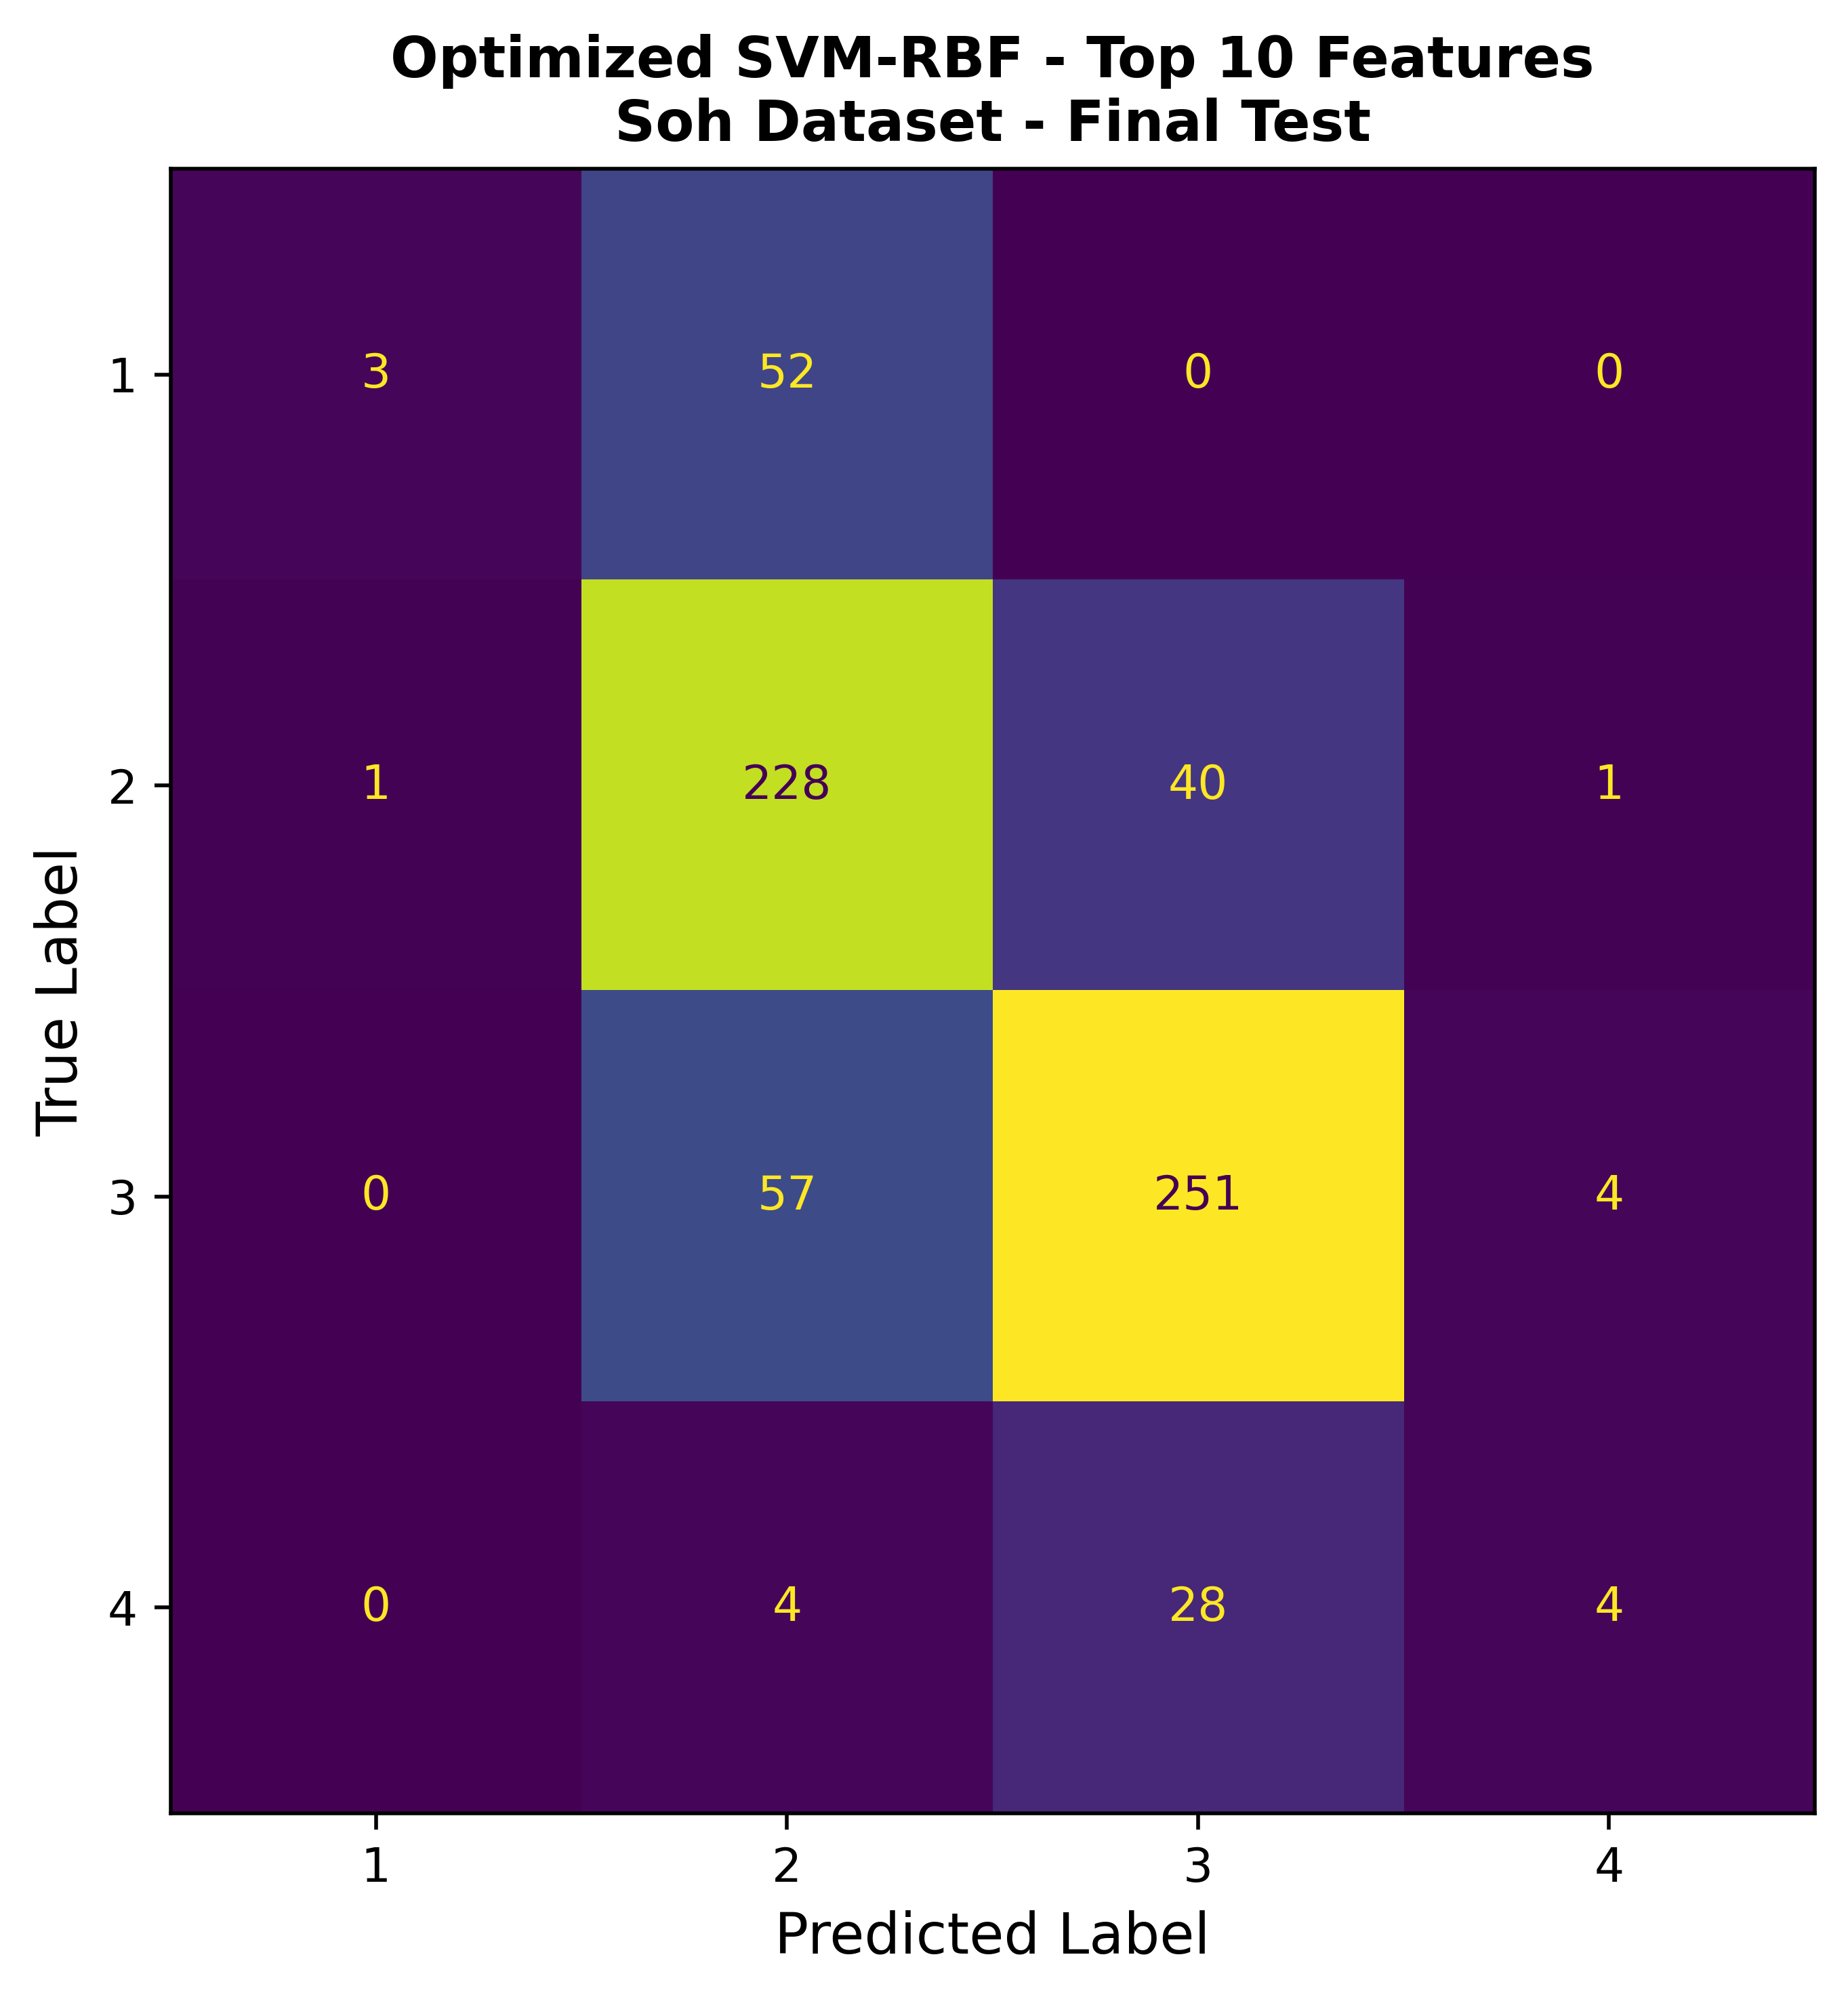

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. Fixed Top-10 Features
# ============================================================
# These features were selected previously.
# NO feature selection is performed in this code.


print("\n" + "=" * 80)
print("FIXED TOP-10 FEATURES")
print("=" * 80)

for i, feature in enumerate(
    selected_top10,
    start=1
):
    print(f"{i}. {feature}")


# ============================================================
# 2. Prepare Soh Dataset
# ============================================================

X = Soh_df[selected_top10]

y = Soh_df['ACR']


print("\n" + "=" * 80)
print("SOH DATASET")
print("=" * 80)

print(
    f"Total samples  : {X.shape[0]}"
)

print(
    f"Number features: {X.shape[1]}"
)


# ============================================================
# 3. Train / Final Test Split
# ============================================================
# IMPORTANT:
# The final test set is NOT used during hyperparameter
# optimization.

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    shuffle=True,

    random_state=42
)


print("\nTraining samples:",
      X_train.shape[0])

print("Final test samples:",
      X_test.shape[0])


# ============================================================
# 4. Outer 5-Fold CV
# ============================================================

outer_cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)


# ============================================================
# 5. SVM-RBF Hyperparameter Search Space
# ============================================================

param_grid = {

    'svm__C': [

        0.01,

        0.1,

        1,

        10,

        100
    ],

    'svm__gamma': [

        'scale',

        0.001,

        0.01,

        0.1,

        1
    ]
}


# ============================================================
# 6. Storage
# ============================================================

outer_results = []

best_parameters_each_fold = []


# ============================================================
# 7. OUTER 5-FOLD NESTED CROSS VALIDATION
# ============================================================

for fold, (train_idx, val_idx) in enumerate(

    outer_cv.split(
        X_train,
        y_train
    ),

    start=1
):

    print("\n")

    print("=" * 90)

    print(
        f"OUTER FOLD {fold}"
    )

    print("=" * 90)


    # ========================================================
    # A. Outer Train / Validation
    # ========================================================

    X_outer_train = X_train.iloc[
        train_idx
    ]

    X_outer_val = X_train.iloc[
        val_idx
    ]

    y_outer_train = y_train.iloc[
        train_idx
    ]

    y_outer_val = y_train.iloc[
        val_idx
    ]


    print(
        "Outer training samples:",
        X_outer_train.shape[0]
    )

    print(
        "Outer validation samples:",
        X_outer_val.shape[0]
    )


    # ========================================================
    # B. SVM-RBF Pipeline
    # ========================================================
    # Scaling is performed independently inside each fold.

    svm_pipeline = Pipeline([

        (
            'scaler',

            StandardScaler()
        ),

        (
            'svm',

            SVC(
                kernel='rbf'
            )
        )
    ])


    # ========================================================
    # C. Inner 5-Fold CV
    # ========================================================

    inner_cv = StratifiedKFold(

        n_splits=5,

        shuffle=True,

        random_state=42
    )


    # ========================================================
    # D. GridSearchCV
    # ========================================================

    grid_search = GridSearchCV(

        estimator=svm_pipeline,

        param_grid=param_grid,

        scoring='f1_weighted',

        cv=inner_cv,

        n_jobs=-1,

        refit=True
    )


    print("\nRunning Hyperparameter Optimization...")


    grid_search.fit(

        X_outer_train,

        y_outer_train
    )


    # ========================================================
    # E. Best Parameters
    # ========================================================

    best_C = grid_search.best_params_[
        'svm__C'
    ]

    best_gamma = grid_search.best_params_[
        'svm__gamma'
    ]


    print("\nBest Parameters:")

    print(
        grid_search.best_params_
    )


    print(
        f"Best Inner-CV F1: "
        f"{grid_search.best_score_:.4f}"
    )


    best_parameters_each_fold.append({

        'Fold': fold,

        'C': best_C,

        'Gamma': best_gamma,

        'Inner_CV_F1':
            grid_search.best_score_
    })


    # ========================================================
    # F. Evaluate on Outer Validation
    # ========================================================

    y_pred = grid_search.predict(

        X_outer_val
    )


    # ========================================================
    # G. Metrics
    # ========================================================

    accuracy = accuracy_score(

        y_outer_val,

        y_pred
    )


    precision = precision_score(

        y_outer_val,

        y_pred,

        average='weighted',

        zero_division=0
    )


    recall = recall_score(

        y_outer_val,

        y_pred,

        average='weighted',

        zero_division=0
    )


    f1 = f1_score(

        y_outer_val,

        y_pred,

        average='weighted',

        zero_division=0
    )


    # ========================================================
    # H. Save Results
    # ========================================================

    outer_results.append({

        'Fold': fold,

        'Accuracy': accuracy,

        'Precision': precision,

        'Recall': recall,

        'F1': f1,

        'Best_C': best_C,

        'Best_Gamma': best_gamma
    })


    print("\nOuter Fold Performance:")

    print(
        f"Accuracy : {accuracy:.4f}"
    )

    print(
        f"Precision: {precision:.4f}"
    )

    print(
        f"Recall   : {recall:.4f}"
    )

    print(
        f"F1-score : {f1:.4f}"
    )


# ============================================================
# 8. Nested CV Results
# ============================================================

nested_results = pd.DataFrame(

    outer_results
)


print("\n")

print("=" * 90)

print(
    "NESTED 5-FOLD CV RESULTS - SOH DATASET"
)

print("=" * 90)


print(

    nested_results.to_string(
        index=False
    )
)


# ============================================================
# 9. Mean ± SD
# ============================================================

summary = pd.DataFrame({

    'Metric': [

        'Accuracy',

        'Precision',

        'Recall',

        'F1-score'
    ],

    'Mean': [

        nested_results[
            'Accuracy'
        ].mean(),

        nested_results[
            'Precision'
        ].mean(),

        nested_results[
            'Recall'
        ].mean(),

        nested_results[
            'F1'
        ].mean()
    ],

    'SD': [

        nested_results[
            'Accuracy'
        ].std(
            ddof=1
        ),

        nested_results[
            'Precision'
        ].std(
            ddof=1
        ),

        nested_results[
            'Recall'
        ].std(
            ddof=1
        ),

        nested_results[
            'F1'
        ].std(
            ddof=1
        )
    ]
})


# ============================================================
# 10. Convert to Percentage
# ============================================================

summary['Mean (%)'] = (

    summary['Mean'] * 100
)


summary['SD (%)'] = (

    summary['SD'] * 100
)


summary['Mean ± SD'] = (

    summary['Mean (%)'].map(

        lambda x:
        f"{x:.2f}"
    )

    + " ± "

    +

    summary['SD (%)'].map(

        lambda x:
        f"{x:.2f}"
    )
)


# ============================================================
# 11. Final Nested CV Performance
# ============================================================

print("\n")

print("=" * 90)

print(
    "FINAL NESTED 5-FOLD CV PERFORMANCE"
)

print("=" * 90)


print(

    summary[
        ['Metric', 'Mean ± SD']
    ].to_string(
        index=False
    )
)


# ============================================================
# 12. Hyperparameter Stability Across Folds
# ============================================================

parameters_df = pd.DataFrame(

    best_parameters_each_fold
)


print("\n")

print("=" * 90)

print(
    "BEST PARAMETERS IN EACH OUTER FOLD"
)

print("=" * 90)


print(

    parameters_df.to_string(
        index=False
    )
)


# ============================================================
# 13. Final Hyperparameter Optimization
# ============================================================
# IMPORTANT:
# Final test set is STILL untouched.

final_svm_pipeline = Pipeline([

    (
        'scaler',

        StandardScaler()
    ),

    (
        'svm',

        SVC(
            kernel='rbf'
        )
    )
])


final_inner_cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)


final_grid_search = GridSearchCV(

    estimator=final_svm_pipeline,

    param_grid=param_grid,

    scoring='f1_weighted',

    cv=final_inner_cv,

    n_jobs=-1,

    refit=True
)


print("\n")

print("=" * 90)

print(
    "FINAL SVM-RBF HYPERPARAMETER OPTIMIZATION"
)

print("=" * 90)


final_grid_search.fit(

    X_train,

    y_train
)


# ============================================================
# 14. Final Best Model
# ============================================================

print("\n")

print(
    "FINAL BEST PARAMETERS:"
)

print(

    final_grid_search.best_params_
)


print(

    f"Best Training CV F1: "
    f"{final_grid_search.best_score_:.4f}"
)


# ============================================================
# 15. Final Model on Test Data
# ============================================================

y_test_pred = final_grid_search.predict(

    X_test
)


# ============================================================
# 16. Final Test Metrics
# ============================================================

test_accuracy = accuracy_score(

    y_test,

    y_test_pred
)


test_precision = precision_score(

    y_test,

    y_test_pred,

    average='weighted',

    zero_division=0
)


test_recall = recall_score(

    y_test,

    y_test_pred,

    average='weighted',

    zero_division=0
)


test_f1 = f1_score(

    y_test,

    y_test_pred,

    average='weighted',

    zero_division=0
)


# ============================================================
# 17. FINAL TEST PERFORMANCE
# ============================================================

print("\n")

print("=" * 90)

print(
    "FINAL TEST PERFORMANCE - SOH DATASET"
)

print("=" * 90)


print(

    f"Accuracy : "
    f"{test_accuracy:.4f}"
)


print(

    f"Precision: "
    f"{test_precision:.4f}"
)


print(

    f"Recall   : "
    f"{test_recall:.4f}"
)


print(

    f"F1-score : "
    f"{test_f1:.4f}"
)


# ============================================================
# 18. Classification Report
# ============================================================

print("\n")

print(
    "CLASSIFICATION REPORT"
)

print(

    classification_report(

        y_test,

        y_test_pred,

        zero_division=0
    )
)


# ============================================================
# 19. Confusion Matrix
# ============================================================

cm = confusion_matrix(

    y_test,

    y_test_pred
)


print("\n")

print(
    "CONFUSION MATRIX - FINAL TEST"
)

print(cm)


# ============================================================
# 20. Plot Confusion Matrix
# ============================================================

class_labels = np.unique(y)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_labels
)


fig, ax = plt.subplots(

    figsize=(7, 6),

    dpi=500
)


disp.plot(

    ax=ax,

    values_format='d',

    colorbar=False
)


plt.title(

    "Optimized SVM-RBF - Top 10 Features\n"
    "Soh Dataset - Final Test",

    fontsize=12,

    weight='bold'
)


plt.xlabel(

    "Predicted Label",

    fontsize=12
)


plt.ylabel(

    "True Label",

    fontsize=12
)


plt.xticks(
    fontsize=10
)

plt.yticks(
    fontsize=10
)


plt.tight_layout()

plt.show()

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# ============================================================
# 1. Previously Selected Top-10 Features By Random Forest
# ============================================================

selected_top10 =  [
    "4bin_pol5-4",
    "homogeneity0_2_bin2_6",
    "entropy0_3_bin2_6",
    "count_higher_mean",
    "correlation0_1_bin2_6",
    "dissimilarity0_4_bin2_6",
    "ASM0_5_bin2_6",
    "contrast135_50_bin1_6",
    "16bin-pol4_2",
    "64bin-pol4_1"
]

print("Selected Top-10 Features:")

for i, feature in enumerate(
    selected_top10,
    start=1
):
    print(f"{i}. {feature}")


# ============================================================
# 2. Training Dataset: Soh_df
# ============================================================

X_Soh = Soh_df[selected_top10]

y_Soh = Soh_df['ACR']


print("\nTraining samples:", X_Soh.shape[0])
print("Selected features:", X_Soh.shape[1])


# ============================================================
# 3. 5-Fold Stratified Cross Validation
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 4. Define ANN Architectures
# ============================================================
# Several hidden-layer configurations are tested.
#
# (8,)              -> 1 hidden layer
# (16,)             -> 1 hidden layer
# (32,)             -> 1 hidden layer
#
# (16,8)            -> 2 hidden layers
# (32,16)           -> 2 hidden layers
# (64,32)           -> 2 hidden layers
#
# (32,16,8)         -> 3 hidden layers
# (64,32,16)        -> 3 hidden layers


architectures = {

    'ANN_1L_8': (8,),

    'ANN_1L_16': (16,),

    'ANN_1L_32': (32,),

    'ANN_2L_16_8': (16, 8),

    'ANN_2L_32_16': (32, 16),

    'ANN_2L_64_32': (64, 32),

    'ANN_3L_32_16_8': (32, 16, 8),

    'ANN_3L_64_32_16': (64, 32, 16)
}


# ============================================================
# 5. Storage
# ============================================================

all_results = []

architecture_summary = []


# ============================================================
# 6. Evaluate each ANN Architecture
# ============================================================

for architecture_name, hidden_layers in architectures.items():

    print("\n")
    print("=" * 80)
    print(f"Testing Architecture: {architecture_name}")
    print(f"Hidden Layers: {hidden_layers}")
    print("=" * 80)


    # --------------------------------------------------------
    # ANN Pipeline
    # --------------------------------------------------------

    ann = Pipeline([

        ('scaler', StandardScaler()),

        ('mlp', MLPClassifier(

            hidden_layer_sizes=hidden_layers,

            activation='relu',

            solver='adam',

            alpha=0.0001,

            learning_rate_init=0.001,

            max_iter=1000,

            early_stopping=True,

            validation_fraction=0.15,

            n_iter_no_change=30,

            random_state=42
        ))
    ])


    # --------------------------------------------------------
    # Storage for current architecture
    # --------------------------------------------------------

    accuracy_scores = []

    precision_scores = []

    recall_scores = []

    f1_scores = []


    # ========================================================
    # 5-Fold CV
    # ========================================================

    for fold, (train_idx, val_idx) in enumerate(
        skf.split(X_Soh, y_Soh),
        start=1
    ):

        X_train = X_Soh.iloc[train_idx]

        X_val = X_Soh.iloc[val_idx]

        y_train = y_Soh.iloc[train_idx]

        y_val = y_Soh.iloc[val_idx]


        # ----------------------------------------------------
        # Train ANN
        # ----------------------------------------------------

        ann.fit(
            X_train,
            y_train
        )


        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        y_pred = ann.predict(
            X_val
        )


        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        accuracy = accuracy_score(
            y_val,
            y_pred
        )

        precision = precision_score(
            y_val,
            y_pred,
            average='weighted',
            zero_division=0
        )

        recall = recall_score(
            y_val,
            y_pred,
            average='weighted',
            zero_division=0
        )

        f1 = f1_score(
            y_val,
            y_pred,
            average='weighted',
            zero_division=0
        )


        # ----------------------------------------------------
        # Save scores
        # ----------------------------------------------------

        accuracy_scores.append(accuracy)

        precision_scores.append(precision)

        recall_scores.append(recall)

        f1_scores.append(f1)


        all_results.append({

            'Architecture': architecture_name,

            'Hidden_Layers': str(hidden_layers),

            'Fold': fold,

            'Accuracy': accuracy,

            'Precision': precision,

            'Recall': recall,

            'F1': f1
        })


    # ========================================================
    # Mean ± SD
    # ========================================================

    architecture_summary.append({

        'Architecture': architecture_name,

        'Hidden_Layers': str(hidden_layers),

        'Accuracy_Mean':
            np.mean(accuracy_scores),

        'Accuracy_SD':
            np.std(
                accuracy_scores,
                ddof=1
            ),

        'Precision_Mean':
            np.mean(precision_scores),

        'Precision_SD':
            np.std(
                precision_scores,
                ddof=1
            ),

        'Recall_Mean':
            np.mean(recall_scores),

        'Recall_SD':
            np.std(
                recall_scores,
                ddof=1
            ),

        'F1_Mean':
            np.mean(f1_scores),

        'F1_SD':
            np.std(
                f1_scores,
                ddof=1
            )
    })


# ============================================================
# 7. Architecture Comparison
# ============================================================

architecture_results = pd.DataFrame(
    architecture_summary
)


# ============================================================
# 8. Sort by Mean F1
# ============================================================

architecture_results = architecture_results.sort_values(

    by='F1_Mean',

    ascending=False

).reset_index(drop=True)


# ============================================================
# 9. Display Results
# ============================================================

display_table = architecture_results.copy()


display_table['Accuracy'] = (

    display_table['Accuracy_Mean'] * 100

).map(
    lambda x: f"{x:.2f}"
) + " ± " + (

    display_table['Accuracy_SD'] * 100

).map(
    lambda x: f"{x:.2f}"
)


display_table['Precision'] = (

    display_table['Precision_Mean'] * 100

).map(
    lambda x: f"{x:.2f}"
) + " ± " + (

    display_table['Precision_SD'] * 100

).map(
    lambda x: f"{x:.2f}"
)


display_table['Recall'] = (

    display_table['Recall_Mean'] * 100

).map(
    lambda x: f"{x:.2f}"
) + " ± " + (

    display_table['Recall_SD'] * 100

).map(
    lambda x: f"{x:.2f}"
)


display_table['F1-score'] = (

    display_table['F1_Mean'] * 100

).map(
    lambda x: f"{x:.2f}"
) + " ± " + (

    display_table['F1_SD'] * 100

).map(
    lambda x: f"{x:.2f}"
)


print("\n")
print("=" * 100)
print("ANN ARCHITECTURE COMPARISON - SOH - 5-FOLD CV")
print("=" * 100)


print(
    display_table[
        [
            'Architecture',
            'Hidden_Layers',
            'Accuracy',
            'Precision',
            'Recall',
            'F1-score'
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# 10. Select Best Architecture
# ============================================================
# Criterion:
# Highest Mean F1-score


best_architecture_row = architecture_results.iloc[0]


best_architecture_name = (
    best_architecture_row['Architecture']
)


best_hidden_layers = eval(
    best_architecture_row['Hidden_Layers']
)


best_cv_f1 = (
    best_architecture_row['F1_Mean']
)


best_cv_f1_sd = (
    best_architecture_row['F1_SD']
)


print("\n")
print("=" * 80)
print("BEST ANN ARCHITECTURE - SOH With selected features By Random Forest")
print("=" * 80)


print(
    f"Architecture: "
    f"{best_architecture_name}"
)


print(
    f"Hidden Layers: "
    f"{best_hidden_layers}"
)


print(
    f"Mean F1-score: "
    f"{best_cv_f1 * 100:.2f} ± "
    f"{best_cv_f1_sd * 100:.2f}%"
)


# ============================================================
# 11. Train Best ANN on ALL Soh_df
# ============================================================

final_ann = Pipeline([

    ('scaler', StandardScaler()),

    ('mlp', MLPClassifier(

        hidden_layer_sizes=best_hidden_layers,

        activation='relu',

        solver='adam',

        alpha=0.0001,

        learning_rate_init=0.001,

        max_iter=1000,

        early_stopping=True,

        validation_fraction=0.15,

        n_iter_no_change=30,

        random_state=42
    ))
])


print("\n")
print("=" * 80)
print("TRAINING FINAL ANN ON ALL Soh_df")
print("=" * 80)


final_ann.fit(
    X_Soh,
    y_Soh
)


print("\nFinal ANN training completed.")


# ============================================================
# 12. Cross-Validated Performance Summary
# ============================================================

print("\n")
print("=" * 80)
print("FINAL PERFORMANCE - SOH 5-FOLD CV")
print("=" * 80)


print(
    f"Best Architecture : "
    f"{best_architecture_name}"
)


print(
    f"Hidden Layers      : "
    f"{best_hidden_layers}"
)


print(
    f"Accuracy           : "
    f"{best_architecture_row['Accuracy_Mean'] * 100:.2f} ± "
    f"{best_architecture_row['Accuracy_SD'] * 100:.2f}%"
)


print(
    f"Precision          : "
    f"{best_architecture_row['Precision_Mean'] * 100:.2f} ± "
    f"{best_architecture_row['Precision_SD'] * 100:.2f}%"
)


print(
    f"Recall             : "
    f"{best_architecture_row['Recall_Mean'] * 100:.2f} ± "
    f"{best_architecture_row['Recall_SD'] * 100:.2f}%"
)


print(
    f"F1-score           : "
    f"{best_architecture_row['F1_Mean'] * 100:.2f} ± "
    f"{best_architecture_row['F1_SD'] * 100:.2f}%"
)

Selected Top-10 Features:
1. 4bin_pol5-4
2. homogeneity0_2_bin2_6
3. entropy0_3_bin2_6
4. count_higher_mean
5. correlation0_1_bin2_6
6. dissimilarity0_4_bin2_6
7. ASM0_5_bin2_6
8. contrast135_50_bin1_6
9. 16bin-pol4_2
10. 64bin-pol4_1

Training samples: 3362
Selected features: 10


Testing Architecture: ANN_1L_8
Hidden Layers: (8,)


Testing Architecture: ANN_1L_16
Hidden Layers: (16,)


Testing Architecture: ANN_1L_32
Hidden Layers: (32,)


Testing Architecture: ANN_2L_16_8
Hidden Layers: (16, 8)


Testing Architecture: ANN_2L_32_16
Hidden Layers: (32, 16)


Testing Architecture: ANN_2L_64_32
Hidden Layers: (64, 32)


Testing Architecture: ANN_3L_32_16_8
Hidden Layers: (32, 16, 8)


Testing Architecture: ANN_3L_64_32_16
Hidden Layers: (64, 32, 16)


ANN ARCHITECTURE COMPARISON - SOH - 5-FOLD CV
   Architecture Hidden_Layers     Accuracy    Precision       Recall     F1-score
ANN_3L_64_32_16  (64, 32, 16) 72.49 ± 2.41 66.00 ± 4.82 72.49 ± 2.41 68.21 ± 2.57
 ANN_3L_32_16_8   (32, 16, 8)

# VinDr with 10 selected features By RF


RANDOM FOREST SELECTED TOP-10 FEATURES
1. 4bin_pol5-4
2. homogeneity0_2_bin2_6
3. entropy0_3_bin2_6
4. count_higher_mean
5. correlation0_1_bin2_6
6. dissimilarity0_4_bin2_6
7. ASM0_5_bin2_6
8. contrast135_50_bin1_6
9. 16bin-pol4_2
10. 64bin-pol4_1

DATASET INFORMATION
Training samples: 940
Training features: 10
External test samples: 770

SVM-RBF HYPERPARAMETER OPTIMIZATION

Top SVM configurations:
 param_svm__C param_svm__gamma  mean_test_score  std_test_score  rank_test_score
       1000.0             0.01         0.700736        0.034349                1
        100.0              0.1         0.691211        0.021337                2
        100.0            scale         0.691211        0.021337                2
       1000.0              0.1         0.687815        0.022842                4
       1000.0            scale         0.687815        0.022842                4
        100.0             0.01         0.684090        0.027893                6
       1000.0            0.001

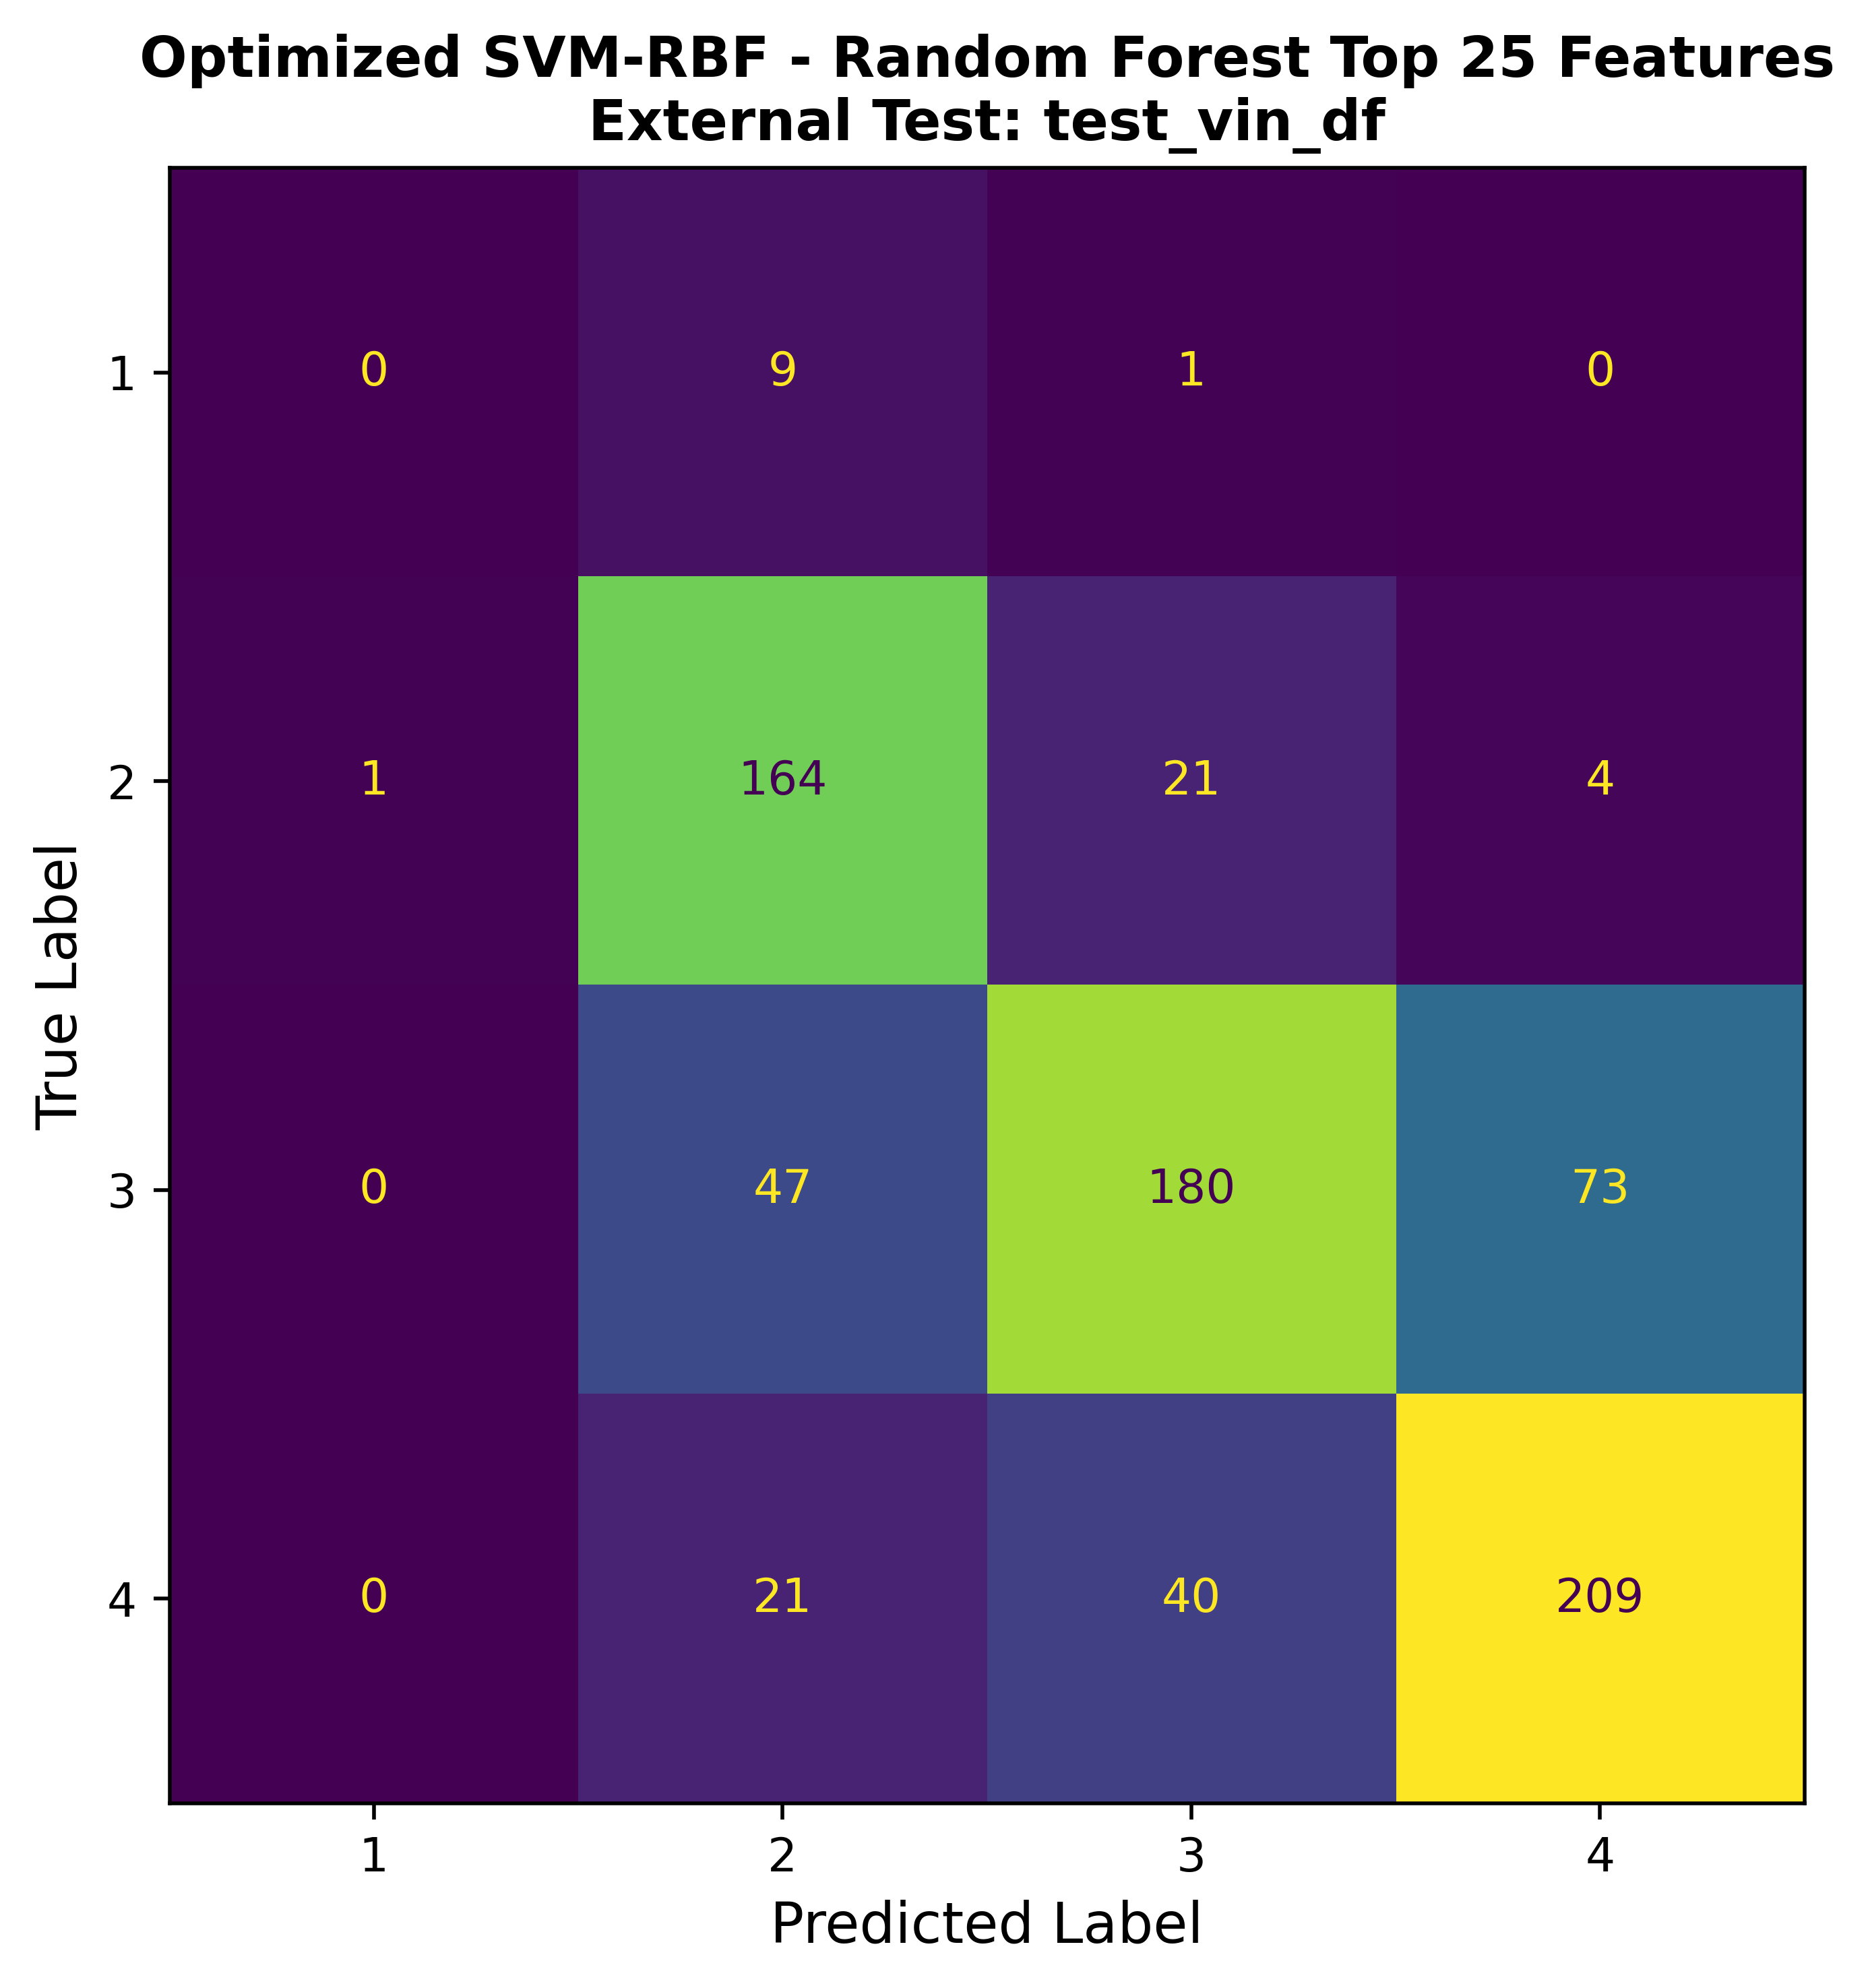

In [17]:

# ============================================================
# OPTIMIZED SVM-RBF
# 25 RANDOM FOREST SELECTED FEATURES
#
# Training Dataset : vin_df
# External Test    : test_vin_df
# CV               : Stratified 5-Fold
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC

from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. FINAL TOP-10 FEATURES SELECTED BY RANDOM FOREST
# ============================================================

selected_top10 = [

    # --------------------------------------------------------
    # Replace with your EXACT 10 Random Forest selected
    # feature names.
    # --------------------------------------------------------

    "4bin_pol5-4",
    "homogeneity0_2_bin2_6",
    "entropy0_3_bin2_6",
    "count_higher_mean",
    "correlation0_1_bin2_6",
    "dissimilarity0_4_bin2_6",
    "ASM0_5_bin2_6",
    "contrast135_50_bin1_6",
    "16bin-pol4_2",
    "64bin-pol4_1"
]

print("\n" + "=" * 80)

print(
    "RANDOM FOREST SELECTED TOP-10 FEATURES"
)

print("=" * 80)


for i, feature in enumerate(

    selected_top10,

    start=1

):

    print(
        f"{i}. {feature}"
    )


# ============================================================
# 2. Training Dataset: vin_df
# ============================================================

X_vin_df = vin_df[selected_top10].copy()

y_vin_df = vin_df['ACR'].copy()


# ============================================================
# 3. External Test Dataset: test_vin_df
# ============================================================

X_test_top10 = test_vin_df[selected_top10].copy()

y_test = test_vin_df['ACR'].copy()


print("\n" + "=" * 80)

print(
    "DATASET INFORMATION"
)

print("=" * 80)


print(
    "Training samples:",
    X_vin_df.shape[0]
)


print(
    "Training features:",
    X_vin_df.shape[1]
)


print(
    "External test samples:",
    X_test_top10.shape[0]
)


# ============================================================
# 4. 5-Fold Stratified Cross Validation
# ============================================================

skf = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)


# ============================================================
# 5. SVM-RBF PIPELINE
# ============================================================

svm_pipeline = Pipeline([

    (
        'scaler',

        StandardScaler()
    ),

    (
        'svm',

        SVC(
            kernel='rbf'
        )
    )
])


# ============================================================
# 6. HYPERPARAMETER SEARCH
# ============================================================

param_grid = {

    'svm__C': [

        0.01,

        0.1,

        1,

        10,

        100,

        1000
    ],

    'svm__gamma': [

        'scale',

        0.0001,

        0.001,

        0.01,

        0.1,

        1
    ]
}


# ============================================================
# 7. GRID SEARCH
# ============================================================
# Best model is selected based ONLY on training CV.
# test_vin_df remains untouched.

grid_search = GridSearchCV(

    estimator=svm_pipeline,

    param_grid=param_grid,

    scoring='f1_weighted',

    cv=skf,

    n_jobs=-1,

    refit=True,

    return_train_score=True
)


print("\n" + "=" * 90)

print(
    "SVM-RBF HYPERPARAMETER OPTIMIZATION"
)

print("=" * 90)


grid_search.fit(

    X_vin_df,

    y_vin_df
)


# ============================================================
# 8. ALL SVM RESULTS
# ============================================================

svm_results = pd.DataFrame(

    grid_search.cv_results_
)


svm_results = (

    svm_results

    .sort_values(
        by='mean_test_score',
        ascending=False
    )

    .reset_index(drop=True)
)


print("\nTop SVM configurations:")

print(

    svm_results[
        [
            'param_svm__C',

            'param_svm__gamma',

            'mean_test_score',

            'std_test_score',

            'rank_test_score'
        ]
    ]

    .head(15)

    .to_string(
        index=False
    )
)


# ============================================================
# 9. BEST SVM
# ============================================================

best_C = grid_search.best_params_[
    'svm__C'
]


best_gamma = grid_search.best_params_[
    'svm__gamma'
]


best_cv_f1 = grid_search.best_score_


print("\n" + "=" * 90)

print(
    "BEST SVM-RBF"
)

print("=" * 90)


print(
    "Best C:",
    best_C
)


print(
    "Best gamma:",
    best_gamma
)


print(
    f"Best 5-Fold CV F1: "
    f"{best_cv_f1:.4f}"
)


# ============================================================
# 10. BEST MODEL
# ============================================================
# GridSearchCV already refitted the best model on
# ALL vin_df.

final_svm = grid_search.best_estimator_


# ============================================================
# 11. EXTERNAL TEST: test_vin_df
# ============================================================

y_test_pred = final_svm.predict(

    X_test_top10
)


# ============================================================
# 12. EXTERNAL TEST METRICS
# ============================================================

test_accuracy = accuracy_score(

    y_test,

    y_test_pred
)


test_precision = precision_score(

    y_test,

    y_test_pred,

    average='weighted',

    zero_division=0
)


test_recall = recall_score(

    y_test,

    y_test_pred,

    average='weighted',

    zero_division=0
)


test_f1 = f1_score(

    y_test,

    y_test_pred,

    average='weighted',

    zero_division=0
)


# ============================================================
# 13. EXTERNAL TEST RESULTS
# ============================================================

print("\n" + "=" * 90)

print(
    "FINAL OPTIMIZED SVM-RBF PERFORMANCE"
)

print("=" * 90)


print(
    "Selected Features : 25"
)


print(
    "Best C             :",
    best_C
)


print(
    "Best gamma         :",
    best_gamma
)


print(
    f"CV Mean F1         : "
    f"{best_cv_f1:.4f}"
)


print("\nExternal Test - test_vin_df:")


print(
    f"Accuracy : {test_accuracy:.4f}"
)


print(
    f"Precision: {test_precision:.4f}"
)


print(
    f"Recall   : {test_recall:.4f}"
)


print(
    f"F1-score : {test_f1:.4f}"
)


# ============================================================
# 14. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")


print(

    classification_report(

        y_test,

        y_test_pred,

        zero_division=0
    )
)


# ============================================================
# 15. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_test,

    y_test_pred
)


print("\nConfusion Matrix:")

print(cm)


# ============================================================
# 16. PLOT CONFUSION MATRIX
# ============================================================

class_labels = np.unique(

    y_vin_df
)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_labels
)


fig, ax = plt.subplots(

    figsize=(7, 6),

    dpi=500
)


disp.plot(

    ax=ax,

    values_format='d',

    colorbar=False
)


plt.title(

    "Optimized SVM-RBF - Random Forest Top 25 Features\n"
    "External Test: test_vin_df",

    fontsize=12,

    weight='bold'
)


plt.xlabel(

    "Predicted Label",

    fontsize=12
)


plt.ylabel(

    "True Label",

    fontsize=12
)


plt.xticks(

    fontsize=10
)


plt.yticks(

    fontsize=10
)


plt.tight_layout()

plt.show()




RANDOM FOREST SELECTED TOP-10 FEATURES
1. 4bin_pol5-4
2. homogeneity0_2_bin2_6
3. entropy0_3_bin2_6
4. count_higher_mean
5. correlation0_1_bin2_6
6. dissimilarity0_4_bin2_6
7. ASM0_5_bin2_6
8. contrast135_50_bin1_6
9. 16bin-pol4_2
10. 64bin-pol4_1

DATASET INFORMATION
Training samples: 940
Training features: 10
External test samples: 770

ANN / MLP HYPERPARAMETER OPTIMIZATION

Top ANN configurations:
param_mlp__hidden_layer_sizes  param_mlp__alpha  param_mlp__learning_rate_init  mean_test_score  std_test_score  rank_test_score
                      (16, 8)            0.0010                           0.01         0.689058        0.016349                1
                  (32, 16, 8)            0.1000                           0.01         0.678811        0.019655                2
                  (32, 16, 8)            0.0100                           0.01         0.675324        0.015672                3
                     (32, 16)            0.0010                           0.01 

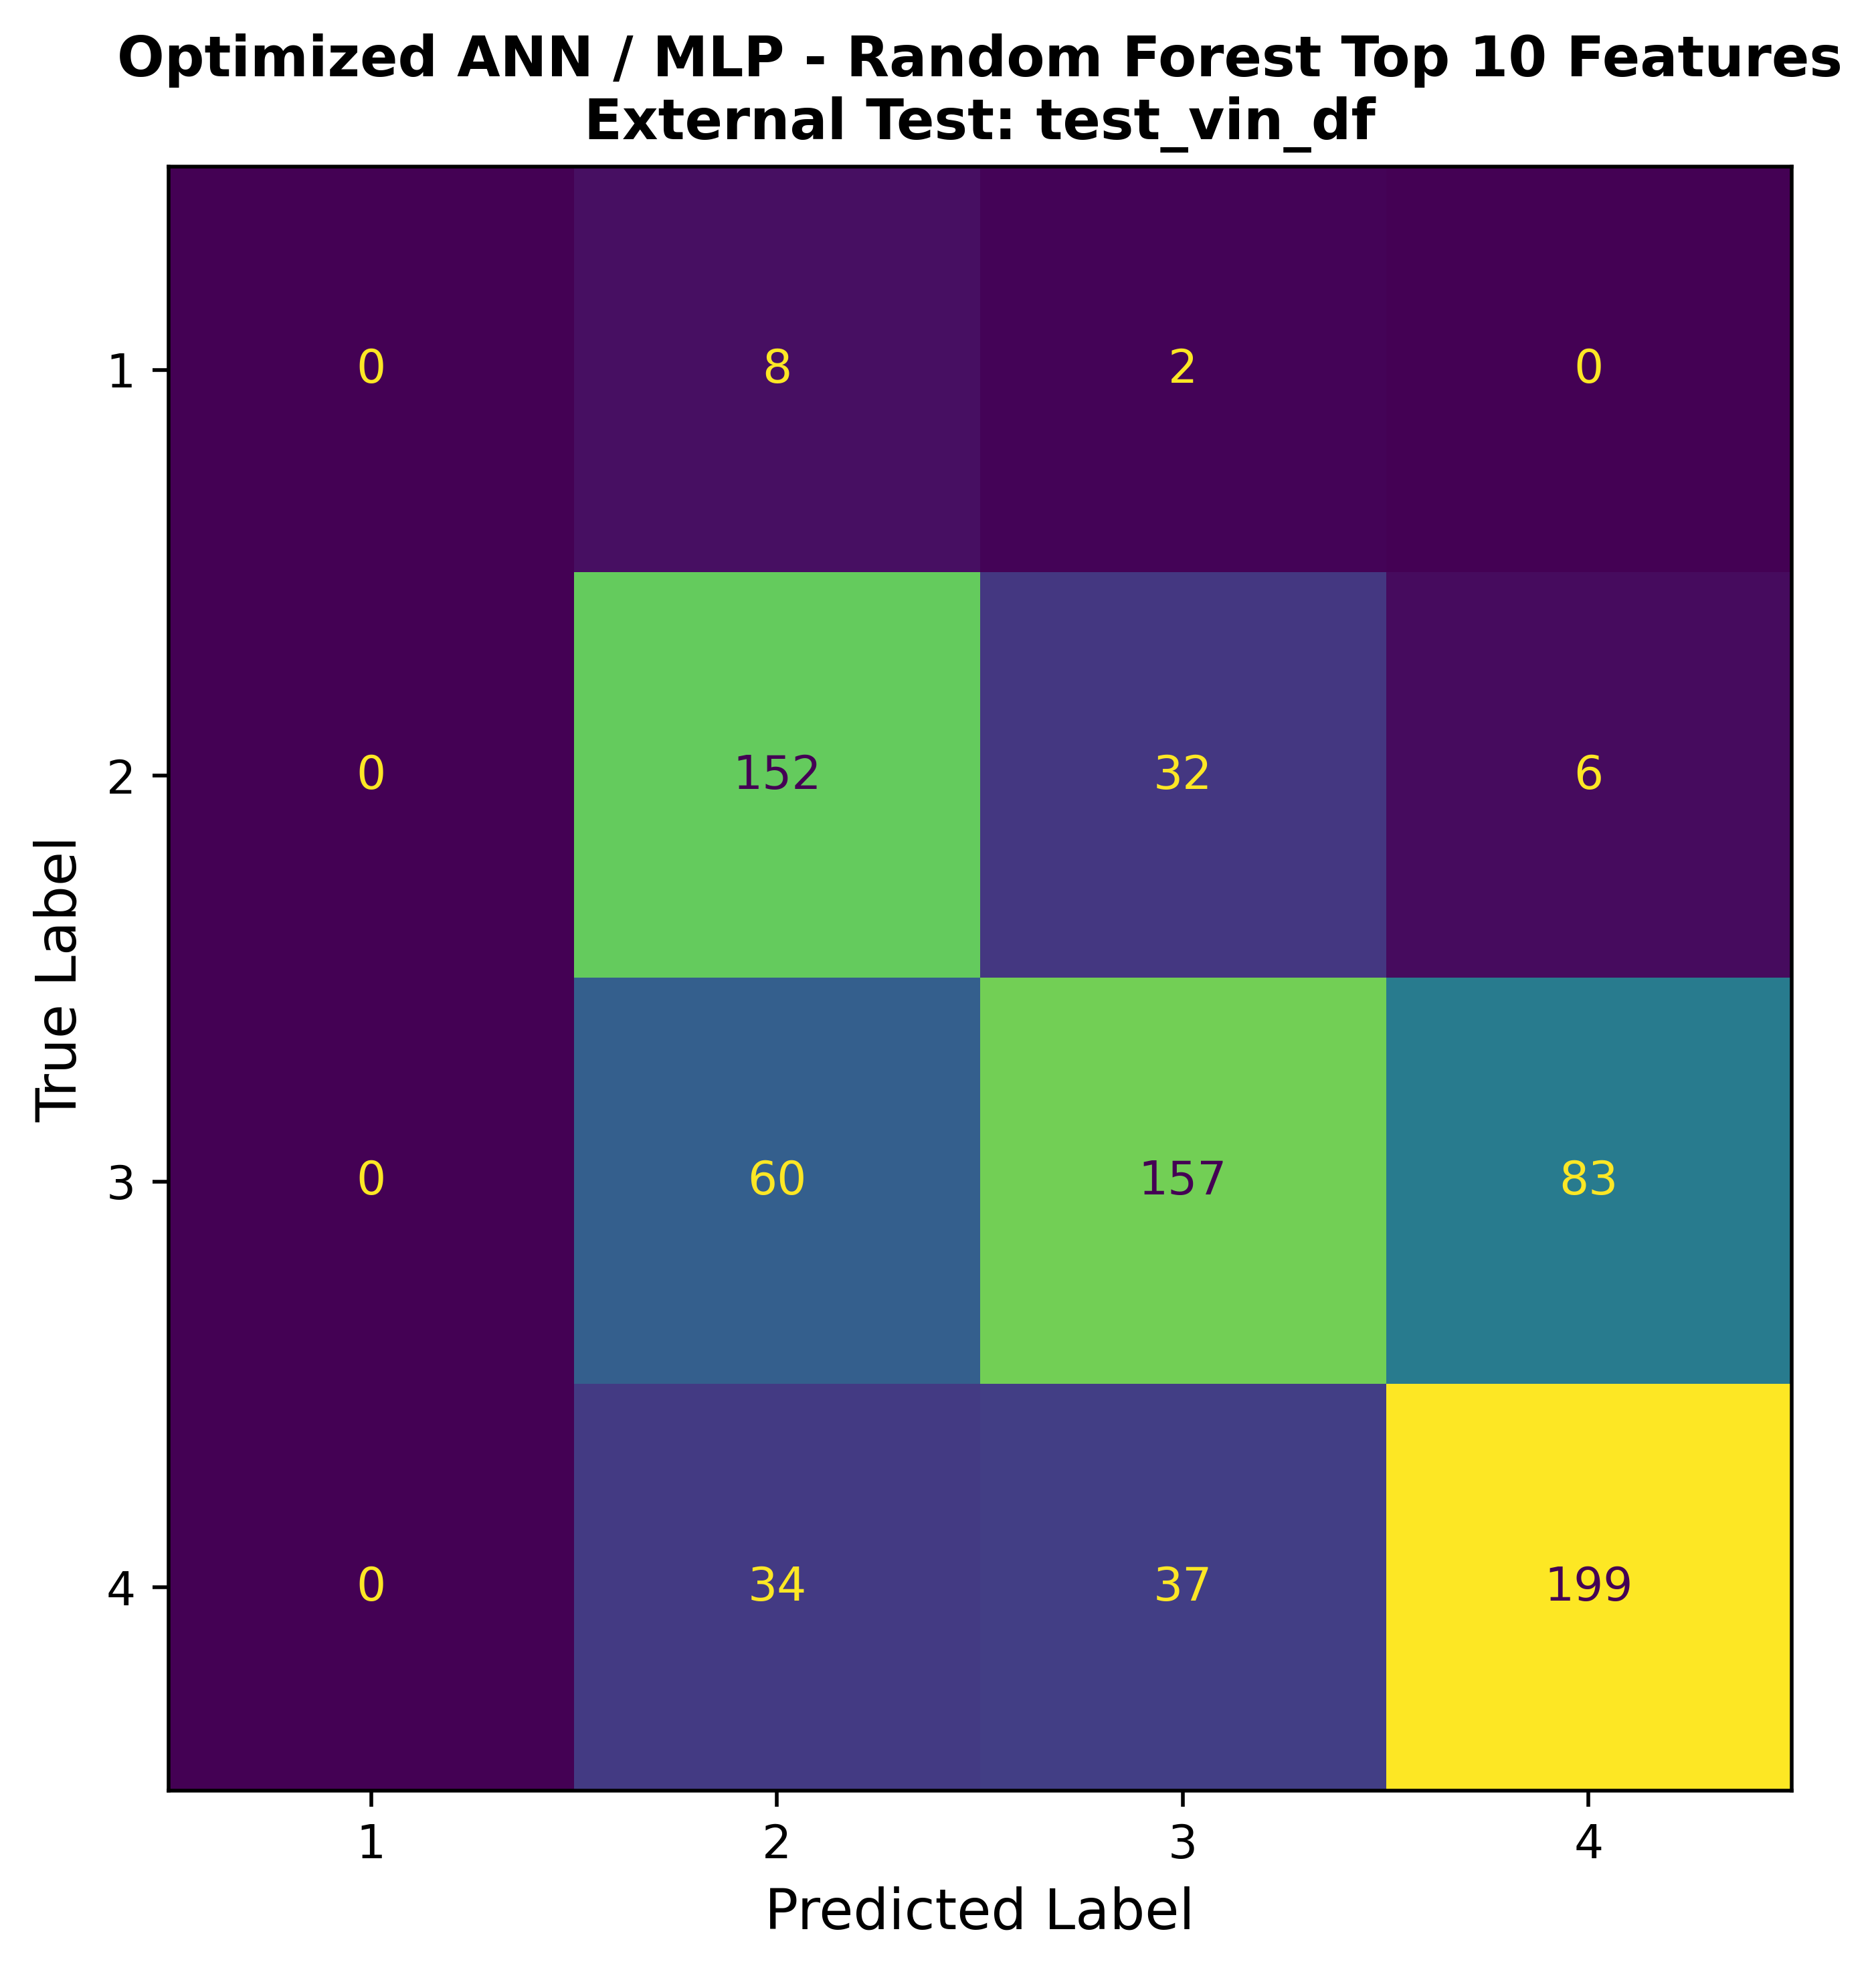

In [20]:

# ============================================================
# OPTIMIZED ANN / MLP
# RANDOM FOREST SELECTED TOP-10 FEATURES
#
# Training Dataset : vin_df
# External Test    : test_vin_df
# CV               : Stratified 5-Fold
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. FINAL TOP-10 FEATURES SELECTED BY RANDOM FOREST
# ============================================================

selected_top10 = [

    "4bin_pol5-4",
    "homogeneity0_2_bin2_6",
    "entropy0_3_bin2_6",
    "count_higher_mean",
    "correlation0_1_bin2_6",
    "dissimilarity0_4_bin2_6",
    "ASM0_5_bin2_6",
    "contrast135_50_bin1_6",
    "16bin-pol4_2",
    "64bin-pol4_1"
]


print("\n" + "=" * 80)

print(
    "RANDOM FOREST SELECTED TOP-10 FEATURES"
)

print("=" * 80)


for i, feature in enumerate(

    selected_top10,

    start=1

):

    print(
        f"{i}. {feature}"
    )


# ============================================================
# 2. Training Dataset: vin_df
# ============================================================

X_vin_df = vin_df[selected_top10].copy()

y_vin_df = vin_df['ACR'].copy()


# ============================================================
# 3. External Test Dataset: test_vin_df
# ============================================================

X_test_top10 = test_vin_df[selected_top10].copy()

y_test = test_vin_df['ACR'].copy()


print("\n" + "=" * 80)

print(
    "DATASET INFORMATION"
)

print("=" * 80)


print(
    "Training samples:",
    X_vin_df.shape[0]
)


print(
    "Training features:",
    X_vin_df.shape[1]
)


print(
    "External test samples:",
    X_test_top10.shape[0]
)


# ============================================================
# 4. 5-Fold Stratified Cross Validation
# ============================================================

skf = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)


# ============================================================
# 5. ANN / MLP PIPELINE
# ============================================================
# StandardScaler is fitted inside each CV fold.
# This prevents data leakage.

ann_pipeline = Pipeline([

    (
        'scaler',

        StandardScaler()
    ),

    (
        'mlp',

        MLPClassifier(

            activation='relu',

            solver='adam',

            max_iter=1000,

            early_stopping=True,

            validation_fraction=0.15,

            n_iter_no_change=30,

            random_state=42
        )
    )
])


# ============================================================
# 6. ANN HYPERPARAMETER SEARCH
# ============================================================

param_grid = {

    'mlp__hidden_layer_sizes': [

        (8,),
        (10,),
        (16,),
        (20,),
        (25,),
        (16, 8),
        (20, 10),
        (25, 10),
        (32, 16),
        (32, 16, 8)
    ],

    'mlp__alpha': [

        0.0001,
        0.001,
        0.01,
        0.1
    ],

    'mlp__learning_rate_init': [

        0.0001,
        0.001,
        0.01
    ]
}


# ============================================================
# 7. GRID SEARCH
# ============================================================
# Best ANN is selected based ONLY on 5-Fold CV.
# test_vin_df remains completely untouched.

grid_search = GridSearchCV(

    estimator=ann_pipeline,

    param_grid=param_grid,

    scoring='f1_weighted',

    cv=skf,

    n_jobs=-1,

    refit=True,

    return_train_score=True
)


print("\n" + "=" * 90)

print(
    "ANN / MLP HYPERPARAMETER OPTIMIZATION"
)

print("=" * 90)


grid_search.fit(

    X_vin_df,

    y_vin_df
)


# ============================================================
# 8. ALL ANN RESULTS
# ============================================================

ann_results = pd.DataFrame(

    grid_search.cv_results_
)


ann_results = (

    ann_results

    .sort_values(

        by='mean_test_score',

        ascending=False

    )

    .reset_index(drop=True)
)


print("\nTop ANN configurations:")


print(

    ann_results[

        [
            'param_mlp__hidden_layer_sizes',

            'param_mlp__alpha',

            'param_mlp__learning_rate_init',

            'mean_test_score',

            'std_test_score',

            'rank_test_score'
        ]

    ]

    .head(15)

    .to_string(

        index=False
    )
)


# ============================================================
# 9. BEST ANN
# ============================================================

best_hidden_layers = (

    grid_search.best_params_[

        'mlp__hidden_layer_sizes'
    ]
)


best_alpha = (

    grid_search.best_params_[

        'mlp__alpha'
    ]
)


best_learning_rate = (

    grid_search.best_params_[

        'mlp__learning_rate_init'
    ]
)


best_cv_f1 = grid_search.best_score_


print("\n" + "=" * 90)

print(
    "BEST ANN / MLP"
)

print("=" * 90)


print(
    "Best Hidden Layers:",
    best_hidden_layers
)


print(
    "Best Alpha:",
    best_alpha
)


print(
    "Best Learning Rate:",
    best_learning_rate
)


print(

    f"Best 5-Fold CV F1: "
    f"{best_cv_f1:.4f}"
)


# ============================================================
# 10. BEST MODEL
# ============================================================
# GridSearchCV automatically refits the best ANN
# using ALL vin_df.

final_ann = (

    grid_search.best_estimator_
)


# ============================================================
# 11. EXTERNAL TEST: test_vin_df
# ============================================================

y_test_pred = final_ann.predict(

    X_test_top10
)


# ============================================================
# 12. EXTERNAL TEST METRICS
# ============================================================

test_accuracy = accuracy_score(

    y_test,

    y_test_pred
)


test_precision = precision_score(

    y_test,

    y_test_pred,

    average='weighted',

    zero_division=0
)


test_recall = recall_score(

    y_test,

    y_test_pred,

    average='weighted',

    zero_division=0
)


test_f1 = f1_score(

    y_test,

    y_test_pred,

    average='weighted',

    zero_division=0
)


# ============================================================
# 13. EXTERNAL TEST RESULTS
# ============================================================

print("\n" + "=" * 90)

print(
    "FINAL OPTIMIZED ANN / MLP PERFORMANCE"
)

print("=" * 90)


print(
    "Selected Features : 10"
)


print(
    "Best Hidden Layers:",
    best_hidden_layers
)


print(
    "Best Alpha         :",
    best_alpha
)


print(
    "Best Learning Rate :",
    best_learning_rate
)


print(

    f"CV Mean F1         : "
    f"{best_cv_f1:.4f}"
)


print("\nExternal Test - test_vin_df:")


print(

    f"Accuracy : "
    f"{test_accuracy:.4f}"
)


print(

    f"Precision: "
    f"{test_precision:.4f}"
)


print(

    f"Recall   : "
    f"{test_recall:.4f}"
)


print(

    f"F1-score : "
    f"{test_f1:.4f}"
)


# ============================================================
# 14. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")


print(

    classification_report(

        y_test,

        y_test_pred,

        zero_division=0
    )
)


# ============================================================
# 15. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_test,

    y_test_pred
)


print("\nConfusion Matrix:")

print(cm)


# ============================================================
# 16. PLOT CONFUSION MATRIX
# ============================================================

class_labels = np.unique(

    y_vin_df
)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_labels
)


fig, ax = plt.subplots(

    figsize=(7, 6),

    dpi=500
)


disp.plot(

    ax=ax,

    values_format='d',

    colorbar=False
)


plt.title(

    "Optimized ANN / MLP - Random Forest Top 10 Features\n"
    "External Test: test_vin_df",

    fontsize=12,

    weight='bold'
)


plt.xlabel(

    "Predicted Label",

    fontsize=12
)


plt.ylabel(

    "True Label",

    fontsize=12
)


plt.xticks(

    fontsize=10
)


plt.yticks(

    fontsize=10
)


plt.tight_layout()

plt.show()



In [47]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import StratifiedKFold


# ============================================================
# 1. Prepare data
# ============================================================

X = Soh_df.drop(columns=['ACR'])
y = Soh_df['ACR']


# ============================================================
# 2. 5-Fold Stratified Cross Validation
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 3. Storage for feature selection results
# ============================================================

feature_names = X.columns


# تعداد دفعاتی که هر ویژگی در Top-25 انتخاب شده
selection_count = pd.Series(
    0,
    index=feature_names,
    dtype=int
)


# رتبه هر ویژگی در هر Fold
rank_matrix = pd.DataFrame(
    index=feature_names,
    columns=[f'Fold_{i}' for i in range(1, 6)],
    dtype=float
)


# ============================================================
# 4. Perform RFE inside each Fold
# ============================================================

for fold, (train_idx, test_idx) in enumerate(
    skf.split(X, y),
    start=1
):

    print("=" * 60)
    print(f"Fold {fold}")
    print("=" * 60)


    # --------------------------------------------------------
    # Training data for this fold
    # --------------------------------------------------------

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]


    # --------------------------------------------------------
    # Random Forest estimator
    # --------------------------------------------------------

    rf = RandomForestClassifier(

        n_estimators=500,

        criterion='gini',

        max_depth=None,

        random_state=42,

        n_jobs=-1
    )


    # --------------------------------------------------------
    # RFE
    # --------------------------------------------------------

    selector = RFE(

        estimator=rf,

        n_features_to_select=25,

        step=0.01
    )


    selector.fit(
        X_train,
        y_train
    )


    # --------------------------------------------------------
    # Selected Top-25 features
    # --------------------------------------------------------

    selected_features = feature_names[
        selector.support_
    ]


    print("\nTop 25 features in this fold:")

    for i, feature in enumerate(
        selected_features,
        start=1
    ):

        print(
            f"{i}. {feature}"
        )


    # --------------------------------------------------------
    # Count selection frequency
    # --------------------------------------------------------

    selection_count.loc[
        selected_features
    ] += 1


    # --------------------------------------------------------
    # Save feature ranking
    # --------------------------------------------------------

    rank_matrix[
        f'Fold_{fold}'
    ] = selector.ranking_


# ============================================================
# 5. Calculate selection frequency
# ============================================================

selection_frequency = (

    selection_count /
    skf.n_splits

) * 100


# ============================================================
# 6. Calculate mean RFE rank
# ============================================================

mean_rank = rank_matrix.mean(
    axis=1
)


# ============================================================
# 7. Create final feature ranking table
# ============================================================

results = pd.DataFrame({

    'Feature':
        feature_names,

    'Selection_Count':
        selection_count.values,

    'Selection_Frequency_%':
        selection_frequency.values,

    'Mean_Rank':
        mean_rank.values
})


# ============================================================
# 8. Sort features
# ============================================================

results = results.sort_values(

    by=[
        'Selection_Count',
        'Mean_Rank'
    ],

    ascending=[
        False,
        True
    ]

).reset_index(drop=True)


# ============================================================
# 9. Final Top 25 Features
# ============================================================

top25_features = results.head(25)


print("\n")
print("=" * 80)
print("FINAL TOP 25 FEATURES - RANDOM FOREST + RFE")
print("=" * 80)


print(
    top25_features.to_string(
        index=False
    )
)


# ============================================================
# 10. List only feature names
# ============================================================

selected_top25 = (
    top25_features[
        'Feature'
    ].tolist()
)


print("\nTop 25 Feature Names:")

for i, feature in enumerate(
    selected_top25,
    start=1
):

    print(
        f"{i}. {feature}"
    )

Fold 1

Top 25 features in this fold:
1. 4bin_pol5-4
2. 16bin-pol4_1
3. 16bin-pol4_2
4. 16bin-pol4_3
5. 64bin-pol4_1
6. correlation0_30_bin1_3
7. homogeneity0_40_bin1_3
8. entropy90_2_bin2_4
9. ASM135_30_bin1_6
10. contrast135_50_bin1_6
11. correlation0_1_bin2_6
12. homogeneity0_2_bin2_6
13. entropy0_3_bin2_6
14. dissimilarity0_4_bin2_6
15. ASM0_5_bin2_6
16. contrast0_20_bin2_6
17. ASM135_50_bin5_7
18. bin2_2_30_IMC2
19. bin4_5_4_contrast
20. entropy0_40
21. entropy0_50
22. entropy135_50
23. count_higher_mean
24. skewness2
25. kurtosis2
Fold 2

Top 25 features in this fold:
1. 4bin_pol5-4
2. 16bin-pol4_1
3. 16bin-pol4_2
4. 64bin-pol4_1
5. 64bin-pol4_2
6. correlation0_30_bin1_3
7. homogeneity0_40_bin1_3
8. dissimilarity45_1_bin1_3
9. entropy45_3_bin3_3
10. dissimilarity135_20_bin1_6
11. ASM135_30_bin1_6
12. contrast135_50_bin1_6
13. correlation0_1_bin2_6
14. homogeneity0_2_bin2_6
15. entropy0_3_bin2_6
16. dissimilarity0_4_bin2_6
17. ASM0_5_bin2_6
18. contrast0_20_bin2_6
19. contrast90_5

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# ============================================================
# 1. Previously Selected Top-25 Features By Random Forest
# ============================================================

selected_top25 =  [
    "4bin_pol5-4",
    "16bin-pol4_2",
    "homogeneity0_40_bin1_3",
    "contrast135_50_bin1_6",
    "correlation0_1_bin2_6",
    "homogeneity0_2_bin2_6",
    "entropy0_3_bin2_6",
    "dissimilarity0_4_bin2_6",
    "ASM0_5_bin2_6",
    "count_higher_mean",
    "skewness2",
    "kurtosis2",
    "16bin-pol4_1",
    "64bin-pol4_1",
    "correlation0_30_bin1_3",
    "ASM135_30_bin1_6",
    "contrast0_20_bin2_6",
    "entropy0_40",
    "entropy0_50",
    "16bin-pol4_3",
    "64bin-pol4_2",
    "dissimilarity135_20_bin1_6",
    "bin3_7_50_IMC2",
    "entropy135_50",
    "ASM90_1_bin7_7"
]


print("Selected Top-25 Features:")

for i, feature in enumerate(
    selected_top25,
    start=1
):
    print(f"{i}. {feature}")


# ============================================================
# 2. Training Dataset: Soh_df
# ============================================================

X_Soh = Soh_df[selected_top25]

y_Soh = Soh_df['ACR']


print("\nTraining samples:", X_Soh.shape[0])
print("Selected features:", X_Soh.shape[1])


# ============================================================
# 3. 5-Fold Stratified Cross Validation
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# 4. Define ANN Architectures
# ============================================================
# Several hidden-layer configurations are tested.
#
# (8,)              -> 1 hidden layer
# (16,)             -> 1 hidden layer
# (32,)             -> 1 hidden layer
#
# (16,8)            -> 2 hidden layers
# (32,16)           -> 2 hidden layers
# (64,32)           -> 2 hidden layers
#
# (32,16,8)         -> 3 hidden layers
# (64,32,16)        -> 3 hidden layers


architectures = {

    'ANN_1L_8': (8,),

    'ANN_1L_16': (16,),

    'ANN_1L_32': (32,),

    'ANN_2L_16_8': (16, 8),

    'ANN_2L_32_16': (32, 16),

    'ANN_2L_64_32': (64, 32),

    'ANN_3L_32_16_8': (32, 16, 8),

    'ANN_3L_64_32_16': (64, 32, 16)
}


# ============================================================
# 5. Storage
# ============================================================

all_results = []

architecture_summary = []


# ============================================================
# 6. Evaluate each ANN Architecture
# ============================================================

for architecture_name, hidden_layers in architectures.items():

    print("\n")
    print("=" * 80)
    print(f"Testing Architecture: {architecture_name}")
    print(f"Hidden Layers: {hidden_layers}")
    print("=" * 80)


    # --------------------------------------------------------
    # ANN Pipeline
    # --------------------------------------------------------

    ann = Pipeline([

        ('scaler', StandardScaler()),

        ('mlp', MLPClassifier(

            hidden_layer_sizes=hidden_layers,

            activation='relu',

            solver='adam',

            alpha=0.0001,

            learning_rate_init=0.001,

            max_iter=1000,

            early_stopping=True,

            validation_fraction=0.15,

            n_iter_no_change=30,

            random_state=42
        ))
    ])


    # --------------------------------------------------------
    # Storage for current architecture
    # --------------------------------------------------------

    accuracy_scores = []

    precision_scores = []

    recall_scores = []

    f1_scores = []


    # ========================================================
    # 5-Fold CV
    # ========================================================

    for fold, (train_idx, val_idx) in enumerate(
        skf.split(X_Soh, y_Soh),
        start=1
    ):

        X_train = X_Soh.iloc[train_idx]

        X_val = X_Soh.iloc[val_idx]

        y_train = y_Soh.iloc[train_idx]

        y_val = y_Soh.iloc[val_idx]


        # ----------------------------------------------------
        # Train ANN
        # ----------------------------------------------------

        ann.fit(
            X_train,
            y_train
        )


        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        y_pred = ann.predict(
            X_val
        )


        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        accuracy = accuracy_score(
            y_val,
            y_pred
        )

        precision = precision_score(
            y_val,
            y_pred,
            average='weighted',
            zero_division=0
        )

        recall = recall_score(
            y_val,
            y_pred,
            average='weighted',
            zero_division=0
        )

        f1 = f1_score(
            y_val,
            y_pred,
            average='weighted',
            zero_division=0
        )


        # ----------------------------------------------------
        # Save scores
        # ----------------------------------------------------

        accuracy_scores.append(accuracy)

        precision_scores.append(precision)

        recall_scores.append(recall)

        f1_scores.append(f1)


        all_results.append({

            'Architecture': architecture_name,

            'Hidden_Layers': str(hidden_layers),

            'Fold': fold,

            'Accuracy': accuracy,

            'Precision': precision,

            'Recall': recall,

            'F1': f1
        })


    # ========================================================
    # Mean ± SD
    # ========================================================

    architecture_summary.append({

        'Architecture': architecture_name,

        'Hidden_Layers': str(hidden_layers),

        'Accuracy_Mean':
            np.mean(accuracy_scores),

        'Accuracy_SD':
            np.std(
                accuracy_scores,
                ddof=1
            ),

        'Precision_Mean':
            np.mean(precision_scores),

        'Precision_SD':
            np.std(
                precision_scores,
                ddof=1
            ),

        'Recall_Mean':
            np.mean(recall_scores),

        'Recall_SD':
            np.std(
                recall_scores,
                ddof=1
            ),

        'F1_Mean':
            np.mean(f1_scores),

        'F1_SD':
            np.std(
                f1_scores,
                ddof=1
            )
    })


# ============================================================
# 7. Architecture Comparison
# ============================================================

architecture_results = pd.DataFrame(
    architecture_summary
)


# ============================================================
# 8. Sort by Mean F1
# ============================================================

architecture_results = architecture_results.sort_values(

    by='F1_Mean',

    ascending=False

).reset_index(drop=True)


# ============================================================
# 9. Display Results
# ============================================================

display_table = architecture_results.copy()


display_table['Accuracy'] = (

    display_table['Accuracy_Mean'] * 100

).map(
    lambda x: f"{x:.2f}"
) + " ± " + (

    display_table['Accuracy_SD'] * 100

).map(
    lambda x: f"{x:.2f}"
)


display_table['Precision'] = (

    display_table['Precision_Mean'] * 100

).map(
    lambda x: f"{x:.2f}"
) + " ± " + (

    display_table['Precision_SD'] * 100

).map(
    lambda x: f"{x:.2f}"
)


display_table['Recall'] = (

    display_table['Recall_Mean'] * 100

).map(
    lambda x: f"{x:.2f}"
) + " ± " + (

    display_table['Recall_SD'] * 100

).map(
    lambda x: f"{x:.2f}"
)


display_table['F1-score'] = (

    display_table['F1_Mean'] * 100

).map(
    lambda x: f"{x:.2f}"
) + " ± " + (

    display_table['F1_SD'] * 100

).map(
    lambda x: f"{x:.2f}"
)


print("\n")
print("=" * 100)
print("ANN ARCHITECTURE COMPARISON - SOH - 5-FOLD CV")
print("=" * 100)


print(
    display_table[
        [
            'Architecture',
            'Hidden_Layers',
            'Accuracy',
            'Precision',
            'Recall',
            'F1-score'
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# 10. Select Best Architecture
# ============================================================
# Criterion:
# Highest Mean F1-score


best_architecture_row = architecture_results.iloc[0]


best_architecture_name = (
    best_architecture_row['Architecture']
)


best_hidden_layers = eval(
    best_architecture_row['Hidden_Layers']
)


best_cv_f1 = (
    best_architecture_row['F1_Mean']
)


best_cv_f1_sd = (
    best_architecture_row['F1_SD']
)


print("\n")
print("=" * 80)
print("BEST ANN ARCHITECTURE - SOH With selected features By Random Forest")
print("=" * 80)


print(
    f"Architecture: "
    f"{best_architecture_name}"
)


print(
    f"Hidden Layers: "
    f"{best_hidden_layers}"
)


print(
    f"Mean F1-score: "
    f"{best_cv_f1 * 100:.2f} ± "
    f"{best_cv_f1_sd * 100:.2f}%"
)


# ============================================================
# 11. Train Best ANN on ALL Soh_df
# ============================================================

final_ann = Pipeline([

    ('scaler', StandardScaler()),

    ('mlp', MLPClassifier(

        hidden_layer_sizes=best_hidden_layers,

        activation='relu',

        solver='adam',

        alpha=0.0001,

        learning_rate_init=0.001,

        max_iter=1000,

        early_stopping=True,

        validation_fraction=0.15,

        n_iter_no_change=30,

        random_state=42
    ))
])


print("\n")
print("=" * 80)
print("TRAINING FINAL ANN ON ALL Soh_df")
print("=" * 80)


final_ann.fit(
    X_Soh,
    y_Soh
)


print("\nFinal ANN training completed.")


# ============================================================
# 12. Cross-Validated Performance Summary
# ============================================================

print("\n")
print("=" * 80)
print("FINAL PERFORMANCE - SOH 5-FOLD CV")
print("=" * 80)


print(
    f"Best Architecture : "
    f"{best_architecture_name}"
)


print(
    f"Hidden Layers      : "
    f"{best_hidden_layers}"
)


print(
    f"Accuracy           : "
    f"{best_architecture_row['Accuracy_Mean'] * 100:.2f} ± "
    f"{best_architecture_row['Accuracy_SD'] * 100:.2f}%"
)


print(
    f"Precision          : "
    f"{best_architecture_row['Precision_Mean'] * 100:.2f} ± "
    f"{best_architecture_row['Precision_SD'] * 100:.2f}%"
)


print(
    f"Recall             : "
    f"{best_architecture_row['Recall_Mean'] * 100:.2f} ± "
    f"{best_architecture_row['Recall_SD'] * 100:.2f}%"
)


print(
    f"F1-score           : "
    f"{best_architecture_row['F1_Mean'] * 100:.2f} ± "
    f"{best_architecture_row['F1_SD'] * 100:.2f}%"
)

Selected Top-25 Features:
1. 4bin_pol5-4
2. 16bin-pol4_2
3. homogeneity0_40_bin1_3
4. contrast135_50_bin1_6
5. correlation0_1_bin2_6
6. homogeneity0_2_bin2_6
7. entropy0_3_bin2_6
8. dissimilarity0_4_bin2_6
9. ASM0_5_bin2_6
10. count_higher_mean
11. skewness2
12. kurtosis2
13. 16bin-pol4_1
14. 64bin-pol4_1
15. correlation0_30_bin1_3
16. ASM135_30_bin1_6
17. contrast0_20_bin2_6
18. entropy0_40
19. entropy0_50
20. 16bin-pol4_3
21. 64bin-pol4_2
22. dissimilarity135_20_bin1_6
23. bin3_7_50_IMC2
24. entropy135_50
25. ASM90_1_bin7_7

Training samples: 3362
Selected features: 25


Testing Architecture: ANN_1L_8
Hidden Layers: (8,)


Testing Architecture: ANN_1L_16
Hidden Layers: (16,)


Testing Architecture: ANN_1L_32
Hidden Layers: (32,)


Testing Architecture: ANN_2L_16_8
Hidden Layers: (16, 8)


Testing Architecture: ANN_2L_32_16
Hidden Layers: (32, 16)


Testing Architecture: ANN_2L_64_32
Hidden Layers: (64, 32)


Testing Architecture: ANN_3L_32_16_8
Hidden Layers: (32, 16, 8)


Testing Ar


PRE-SELECTED TOP-25 FEATURES
1. 4bin_pol5-4
2. 16bin-pol4_2
3. homogeneity0_40_bin1_3
4. contrast135_50_bin1_6
5. correlation0_1_bin2_6
6. homogeneity0_2_bin2_6
7. entropy0_3_bin2_6
8. dissimilarity0_4_bin2_6
9. ASM0_5_bin2_6
10. count_higher_mean
11. skewness2
12. kurtosis2
13. 16bin-pol4_1
14. 64bin-pol4_1
15. correlation0_30_bin1_3
16. ASM135_30_bin1_6
17. contrast0_20_bin2_6
18. entropy0_40
19. entropy0_50
20. 16bin-pol4_3
21. 64bin-pol4_2
22. dissimilarity135_20_bin1_6
23. bin3_7_50_IMC2
24. entropy135_50
25. ASM90_1_bin7_7

DATASET INFORMATION
Samples  : 3362
Features : 25
Classes  : [1, 2, 3, 4]

Target distribution:
ACR
1     274
2    1351
3    1557
4     180
Name: count, dtype: int64


OUTER FOLD 1
Training samples   : 2689
Validation samples : 673

Running GridSearchCV...

Best Parameters:
{'svm__C': 100, 'svm__gamma': 'scale'}
Best Inner-CV F1: 0.7338

Outer Fold Performance:
Accuracy : 0.7459
Precision: 0.7348
Recall   : 0.7459
F1-score : 0.7313


OUTER FOLD 2
Training sam

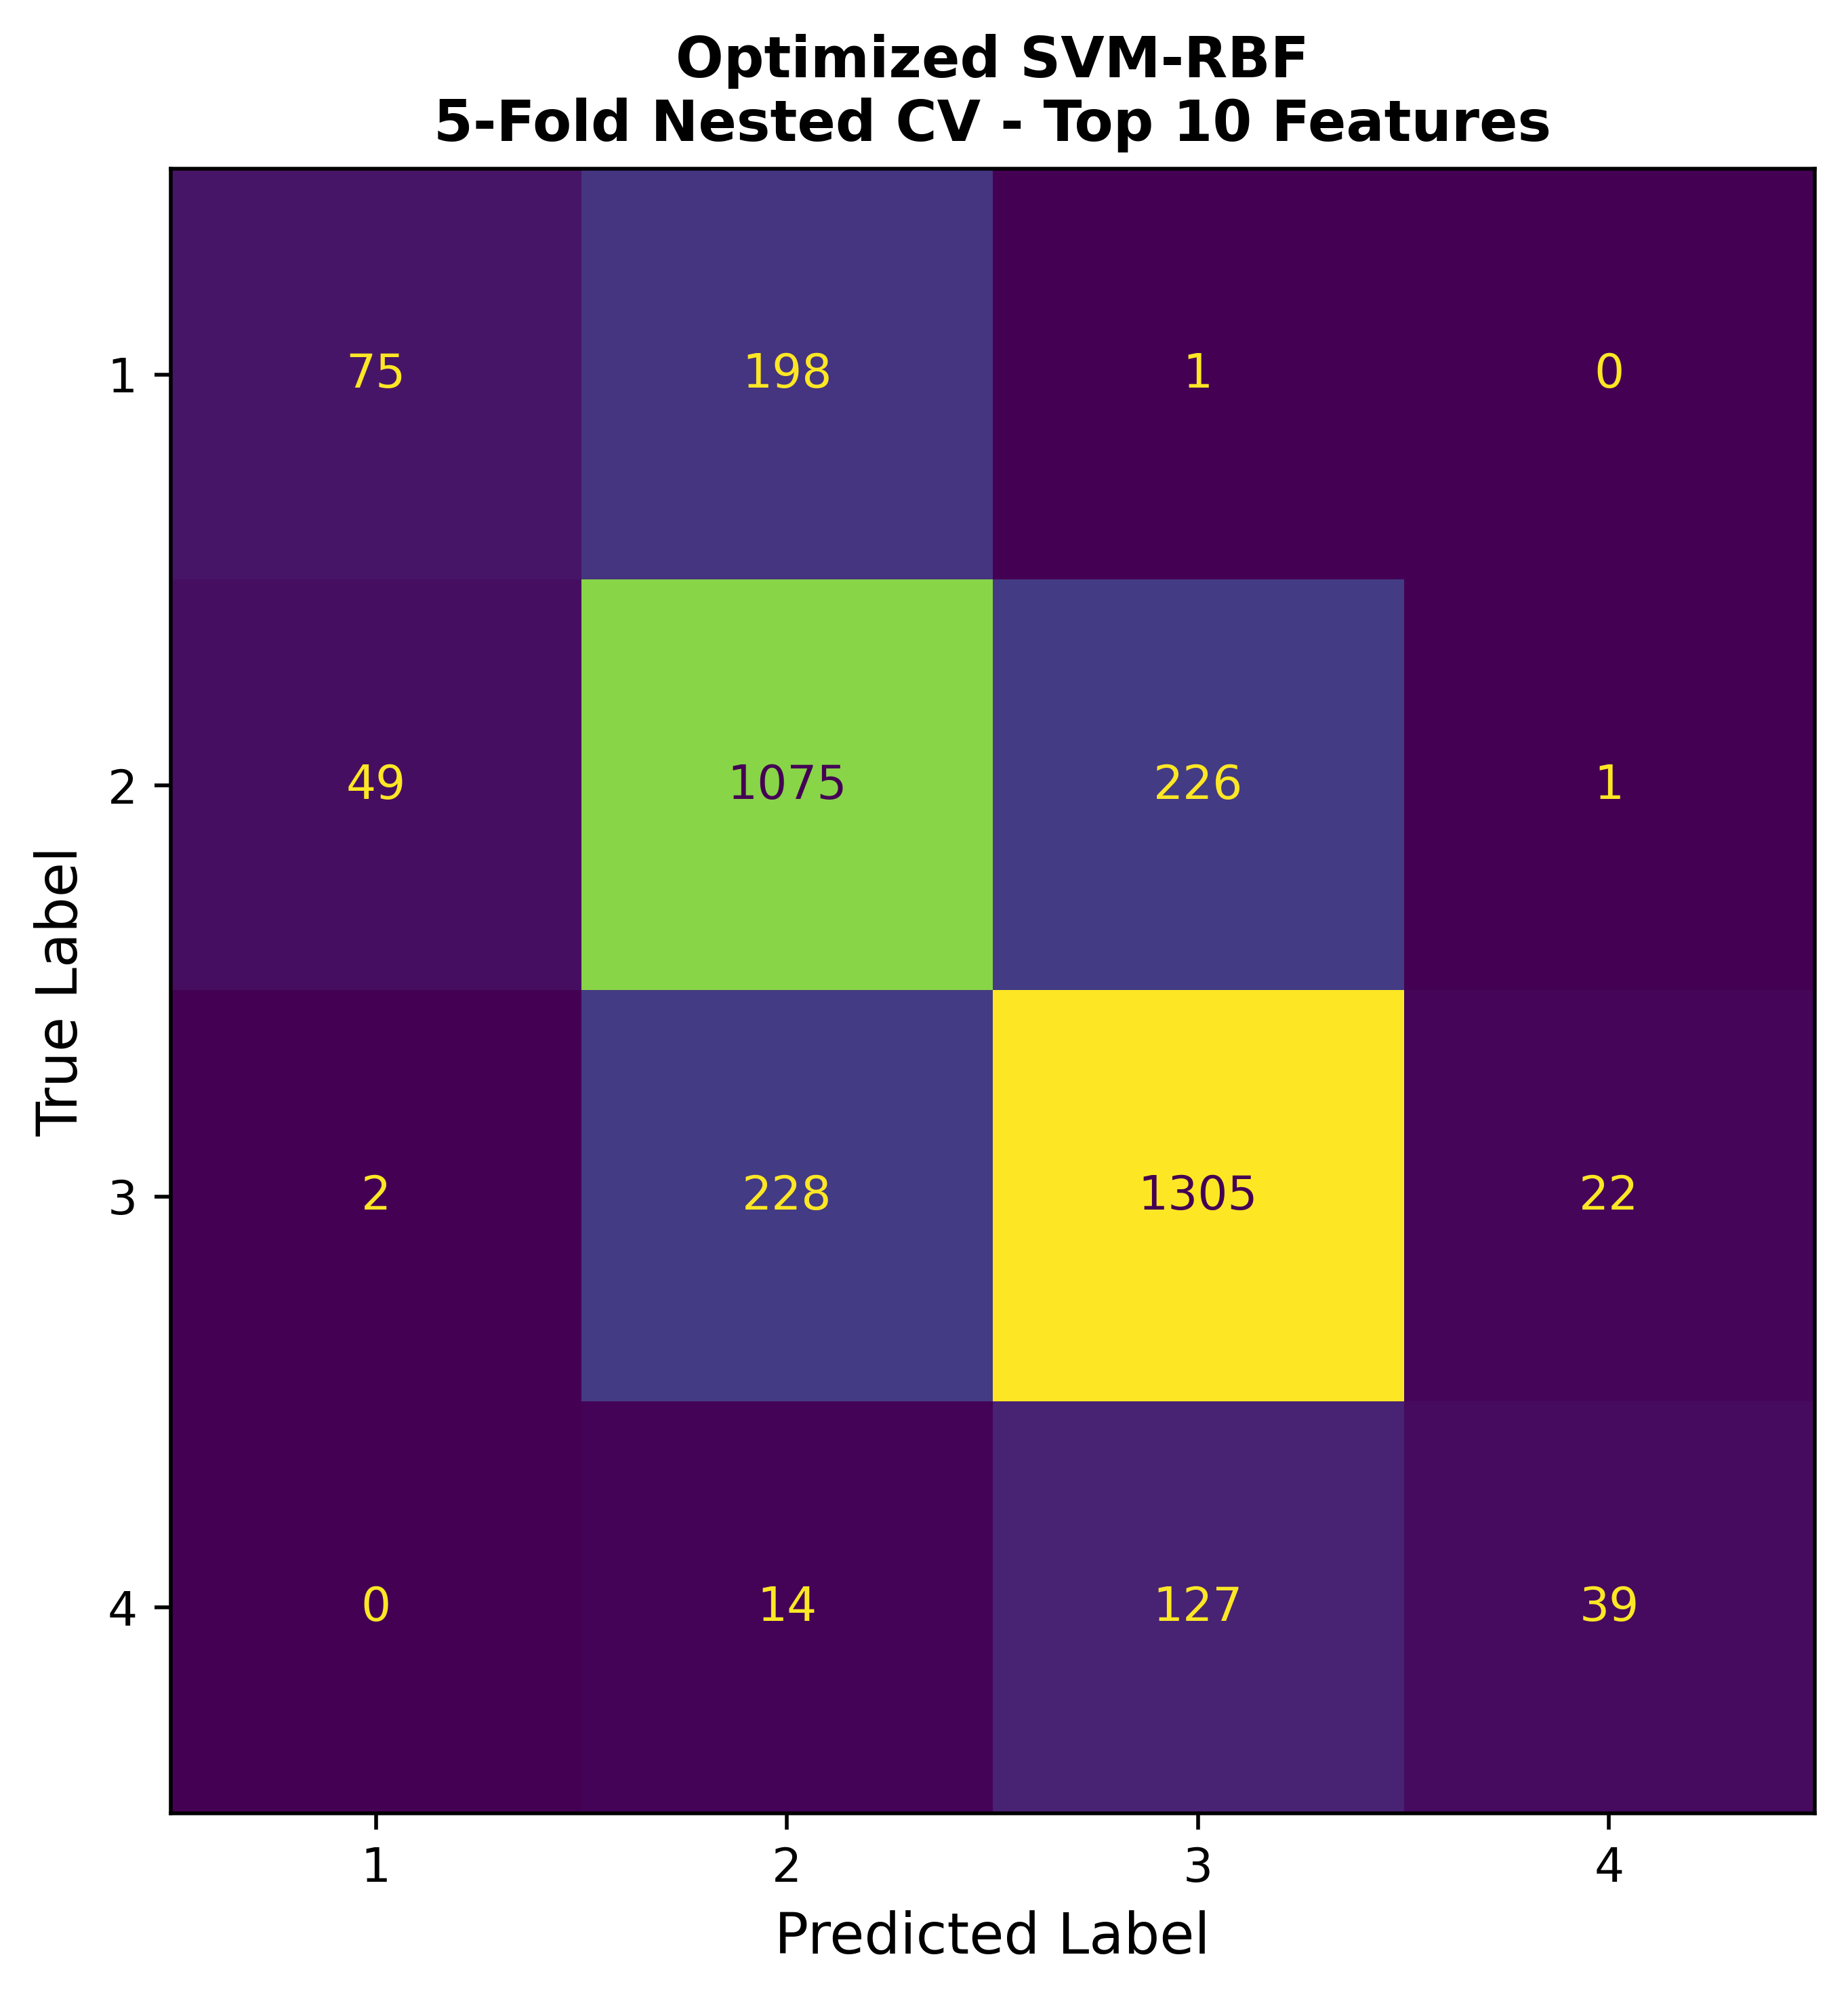


FINAL MODEL TRAINING ON ALL Soh_df

FINAL OPTIMIZED SVM-RBF
Best Parameters:
{'svm__C': 100, 'svm__gamma': 0.01}
Best 5-Fold CV F1: 0.7261

Final model:
Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC(C=100, gamma=0.01))])


In [8]:

# ============================================================
# OPTIMIZED SVM-RBF
# 5-FOLD NESTED CROSS-VALIDATION
# Dataset: Soh_df
# Features: Pre-selected Top-10 Features
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC

from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. PRE-SELECTED TOP-10 FEATURES
# ============================================================
# IMPORTANT:
# These features have already been selected.
# NO additional feature selection is performed.

selected_top25 = [
    "4bin_pol5-4",
    "16bin-pol4_2",
    "homogeneity0_40_bin1_3",
    "contrast135_50_bin1_6",
    "correlation0_1_bin2_6",
    "homogeneity0_2_bin2_6",
    "entropy0_3_bin2_6",
    "dissimilarity0_4_bin2_6",
    "ASM0_5_bin2_6",
    "count_higher_mean",
    "skewness2",
    "kurtosis2",
    "16bin-pol4_1",
    "64bin-pol4_1",
    "correlation0_30_bin1_3",
    "ASM135_30_bin1_6",
    "contrast0_20_bin2_6",
    "entropy0_40",
    "entropy0_50",
    "16bin-pol4_3",
    "64bin-pol4_2",
    "dissimilarity135_20_bin1_6",
    "bin3_7_50_IMC2",
    "entropy135_50",
    "ASM90_1_bin7_7"
]


print("\n" + "=" * 80)
print("PRE-SELECTED TOP-25 FEATURES")
print("=" * 80)

for i, feature in enumerate(
    selected_top25,
    start=1
):
    print(f"{i}. {feature}")


# ============================================================
# 2. PREPARE Soh DATA
# ============================================================

X_Soh = Soh_df[selected_top25].copy()

y_Soh = Soh_df['ACR'].copy()


print("\n" + "=" * 80)
print("DATASET INFORMATION")
print("=" * 80)

print(
    f"Samples  : {X_Soh.shape[0]}"
)

print(
    f"Features : {X_Soh.shape[1]}"
)

print(
    f"Classes  : {sorted(y_Soh.unique())}"
)


# ============================================================
# 3. CHECK TARGET
# ============================================================
# This prevents the "unknown targets" problem.

print("\nTarget distribution:")

print(
    y_Soh.value_counts().sort_index()
)


# Remove samples with missing target if any

valid_target = y_Soh.notna()

X_Soh = X_Soh.loc[valid_target].reset_index(drop=True)

y_Soh = y_Soh.loc[valid_target].reset_index(drop=True)


# ============================================================
# 4. OUTER 5-FOLD CV
# ============================================================

outer_cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)


# ============================================================
# 5. HYPERPARAMETER SEARCH SPACE
# ============================================================

param_grid = {

    'svm__C': [

        0.01,

        0.1,

        1,

        10,

        100
    ],

    'svm__gamma': [

        'scale',

        0.001,

        0.01,

        0.1,

        1
    ]
}


# ============================================================
# 6. STORAGE
# ============================================================

outer_results = []

best_parameters_each_fold = []

confusion_matrices = []


# ============================================================
# 7. OOF PREDICTIONS
# ============================================================
# IMPORTANT:
# Use the same dtype as y_Soh.
# This prevents "unknown target" errors.

oof_predictions = np.empty(

    len(y_Soh),

    dtype=y_Soh.dtype
)


# ============================================================
# 8. OUTER 5-FOLD LOOP
# ============================================================

for fold, (train_idx, val_idx) in enumerate(

    outer_cv.split(
        X_Soh,
        y_Soh
    ),

    start=1

):

    print("\n")

    print("=" * 90)

    print(
        f"OUTER FOLD {fold}"
    )

    print("=" * 90)


    # ========================================================
    # A. Outer Train / Validation
    # ========================================================

    X_train = X_Soh.iloc[
        train_idx
    ]

    X_val = X_Soh.iloc[
        val_idx
    ]


    y_train = y_Soh.iloc[
        train_idx
    ]

    y_val = y_Soh.iloc[
        val_idx
    ]


    print(
        f"Training samples   : {len(train_idx)}"
    )

    print(
        f"Validation samples : {len(val_idx)}"
    )


    # ========================================================
    # B. SVM-RBF Pipeline
    # ========================================================
    # Scaling occurs INSIDE the pipeline.
    #
    # Therefore:
    #
    # StandardScaler is fitted only on training data.
    #
    # This prevents data leakage.

    svm_pipeline = Pipeline([

        (
            'scaler',

            StandardScaler()
        ),

        (
            'svm',

            SVC(
                kernel='rbf'
            )
        )
    ])


    # ========================================================
    # C. INNER 5-FOLD CV
    # ========================================================

    inner_cv = StratifiedKFold(

        n_splits=5,

        shuffle=True,

        random_state=42
    )


    # ========================================================
    # D. GRID SEARCH
    # ========================================================

    grid_search = GridSearchCV(

        estimator=svm_pipeline,

        param_grid=param_grid,

        scoring='f1_weighted',

        cv=inner_cv,

        n_jobs=-1,

        refit=True
    )


    # ========================================================
    # E. HYPERPARAMETER OPTIMIZATION
    # ========================================================

    print("\nRunning GridSearchCV...")

    grid_search.fit(

        X_train,

        y_train
    )


    # ========================================================
    # F. BEST PARAMETERS
    # ========================================================

    best_params = grid_search.best_params_

    best_inner_f1 = grid_search.best_score_


    print("\nBest Parameters:")

    print(
        best_params
    )

    print(
        f"Best Inner-CV F1: "
        f"{best_inner_f1:.4f}"
    )


    best_parameters_each_fold.append(

        best_params
    )


    # ========================================================
    # G. OUTER VALIDATION PREDICTION
    # ========================================================

    y_pred = grid_search.predict(

        X_val
    )


    # ========================================================
    # H. STORE OOF PREDICTIONS
    # ========================================================

    oof_predictions[val_idx] = y_pred


    # ========================================================
    # I. METRICS
    # ========================================================

    accuracy = accuracy_score(

        y_val,

        y_pred
    )


    precision = precision_score(

        y_val,

        y_pred,

        average='weighted',

        zero_division=0
    )


    recall = recall_score(

        y_val,

        y_pred,

        average='weighted',

        zero_division=0
    )


    f1 = f1_score(

        y_val,

        y_pred,

        average='weighted',

        zero_division=0
    )


    # ========================================================
    # J. CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(

        y_val,

        y_pred,

        labels=np.unique(y_Soh)
    )


    confusion_matrices.append(

        cm
    )


    # ========================================================
    # K. SAVE RESULTS
    # ========================================================

    outer_results.append({

        'Fold':

            fold,

        'Accuracy':

            accuracy,

        'Precision':

            precision,

        'Recall':

            recall,

        'F1':

            f1,

        'Best_C':

            best_params[
                'svm__C'
            ],

        'Best_Gamma':

            best_params[
                'svm__gamma'
            ]

    })


    # ========================================================
    # L. PRINT FOLD PERFORMANCE
    # ========================================================

    print("\nOuter Fold Performance:")

    print(
        f"Accuracy : {accuracy:.4f}"
    )

    print(
        f"Precision: {precision:.4f}"
    )

    print(
        f"Recall   : {recall:.4f}"
    )

    print(
        f"F1-score : {f1:.4f}"
    )


# ============================================================
# 9. CHECK OOF PREDICTIONS
# ============================================================
# This is important for preventing the previous error.

print("\n" + "=" * 90)

print(
    "OOF PREDICTION CHECK"
)

print("=" * 90)


print(
    "Number of true labels:",
    len(y_Soh)
)

print(
    "Number of OOF predictions:",
    len(oof_predictions)
)

print(
    "OOF dtype:",
    oof_predictions.dtype
)

print(
    "Unique OOF predictions:",
    np.unique(oof_predictions)
)


# ============================================================
# 10. OVERALL OOF PERFORMANCE
# ============================================================

oof_accuracy = accuracy_score(

    y_Soh,

    oof_predictions
)


oof_precision = precision_score(

    y_Soh,

    oof_predictions,

    average='weighted',

    zero_division=0
)


oof_recall = recall_score(

    y_Soh,

    oof_predictions,

    average='weighted',

    zero_division=0
)


oof_f1 = f1_score(

    y_Soh,

    oof_predictions,

    average='weighted',

    zero_division=0
)


print("\n" + "=" * 90)

print(
    "OVERALL OUT-OF-FOLD PERFORMANCE"
)

print("=" * 90)


print(
    f"Accuracy : {oof_accuracy:.4f}"
)

print(
    f"Precision: {oof_precision:.4f}"
)

print(
    f"Recall   : {oof_recall:.4f}"
)

print(
    f"F1-score : {oof_f1:.4f}"
)


# ============================================================
# 11. FOLD-BY-FOLD RESULTS
# ============================================================

results_df = pd.DataFrame(

    outer_results
)


print("\n" + "=" * 90)

print(
    "NESTED 5-FOLD RESULTS"
)

print("=" * 90)


print(

    results_df.to_string(
        index=False
    )

)


# ============================================================
# 12. MEAN ± SD
# ============================================================

summary = pd.DataFrame({

    'Metric': [

        'Accuracy',

        'Precision',

        'Recall',

        'F1-score'
    ],

    'Mean': [

        results_df[
            'Accuracy'
        ].mean(),

        results_df[
            'Precision'
        ].mean(),

        results_df[
            'Recall'
        ].mean(),

        results_df[
            'F1'
        ].mean()
    ],

    'SD': [

        results_df[
            'Accuracy'
        ].std(
            ddof=1
        ),

        results_df[
            'Precision'
        ].std(
            ddof=1
        ),

        results_df[
            'Recall'
        ].std(
            ddof=1
        ),

        results_df[
            'F1'
        ].std(
            ddof=1
        )
    ]
})


# ============================================================
# 13. PERCENTAGE
# ============================================================

summary['Mean (%)'] = (

    summary['Mean'] * 100
)


summary['SD (%)'] = (

    summary['SD'] * 100
)


summary['Mean ± SD'] = (

    summary['Mean (%)'].map(

        lambda x:
            f"{x:.2f}"
    )

    + " ± "

    +

    summary['SD (%)'].map(

        lambda x:
            f"{x:.2f}"
    )

)


print("\n" + "=" * 90)

print(
    "FINAL NESTED 5-FOLD PERFORMANCE"
)

print("=" * 90)


print(

    summary[
        [
            'Metric',

            'Mean ± SD'
        ]
    ].to_string(
        index=False
    )

)


# ============================================================
# 14. CLASSIFICATION REPORT - OOF
# ============================================================

print("\n" + "=" * 90)

print(
    "OOF CLASSIFICATION REPORT"
)

print("=" * 90)


print(

    classification_report(

        y_Soh,

        oof_predictions,

        zero_division=0
    )

)


# ============================================================
# 15. OOF CONFUSION MATRIX
# ============================================================

class_labels = np.unique(

    y_Soh
)


oof_cm = confusion_matrix(

    y_Soh,

    oof_predictions,

    labels=class_labels
)


print("\n" + "=" * 90)

print(
    "OOF CONFUSION MATRIX"
)

print("=" * 90)


print(
    oof_cm
)


# ============================================================
# 16. PLOT OOF CONFUSION MATRIX
# ============================================================

disp = ConfusionMatrixDisplay(

    confusion_matrix=oof_cm,

    display_labels=class_labels
)


fig, ax = plt.subplots(

    figsize=(7, 6),

    dpi=500
)


disp.plot(

    ax=ax,

    values_format='d',

    colorbar=False
)


plt.title(

    "Optimized SVM-RBF\n"
    "5-Fold Nested CV - Top 10 Features",

    fontsize=12,

    weight='bold'
)


plt.xlabel(

    "Predicted Label",

    fontsize=12
)


plt.ylabel(

    "True Label",

    fontsize=12
)


plt.xticks(

    fontsize=10
)


plt.yticks(

    fontsize=10
)


plt.tight_layout()

plt.show()


# ============================================================
# 17. FINAL HYPERPARAMETER OPTIMIZATION
# ============================================================
# Now the entire Soh_df is used.
#
# External test data, if any, must NOT be used here.

print("\n" + "=" * 90)

print(
    "FINAL MODEL TRAINING ON ALL Soh_df"
)

print("=" * 90)


final_svm_pipeline = Pipeline([

    (

        'scaler',

        StandardScaler()

    ),

    (

        'svm',

        SVC(

            kernel='rbf'

        )

    )

])


final_inner_cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)


final_grid_search = GridSearchCV(

    estimator=final_svm_pipeline,

    param_grid=param_grid,

    scoring='f1_weighted',

    cv=final_inner_cv,

    n_jobs=-1,

    refit=True
)


final_grid_search.fit(

    X_Soh,

    y_Soh
)


# ============================================================
# 18. FINAL BEST SVM
# ============================================================

print("\n" + "=" * 90)

print(
    "FINAL OPTIMIZED SVM-RBF"
)

print("=" * 90)


print(
    "Best Parameters:"
)


print(

    final_grid_search.best_params_

)


print(

    f"Best 5-Fold CV F1: "
    f"{final_grid_search.best_score_:.4f}"

)


# ============================================================
# 19. FINAL MODEL
# ============================================================

final_svm = final_grid_search.best_estimator_


print("\nFinal model:")

print(

    final_svm

)


## For Vindr dataset


RANDOM FOREST SELECTED TOP-25 FEATURES
1. 4bin_pol5-4
2. 16bin-pol4_2
3. homogeneity0_40_bin1_3
4. contrast135_50_bin1_6
5. correlation0_1_bin2_6
6. homogeneity0_2_bin2_6
7. entropy0_3_bin2_6
8. dissimilarity0_4_bin2_6
9. ASM0_5_bin2_6
10. count_higher_mean
11. skewness2
12. kurtosis2
13. 16bin-pol4_1
14. 64bin-pol4_1
15. correlation0_30_bin1_3
16. ASM135_30_bin1_6
17. contrast0_20_bin2_6
18. entropy0_40
19. entropy0_50
20. 16bin-pol4_3
21. 64bin-pol4_2
22. dissimilarity135_20_bin1_6
23. bin3_7_50_IMC2
24. entropy135_50
25. ASM90_1_bin7_7

DATASET INFORMATION
Training samples: 940
Training features: 25
External test samples: 770

Testing ANN Architecture: (8,)

Testing ANN Architecture: (16,)

Testing ANN Architecture: (16, 8)

Testing ANN Architecture: (32, 16)

Testing ANN Architecture: (32, 16, 8)

Testing ANN Architecture: (64, 32)

ANN ARCHITECTURE COMPARISON
Architecture  Accuracy_Mean  Accuracy_SD  Precision_Mean  Precision_SD  Recall_Mean  Recall_SD  F1_Mean    F1_SD
 (32, 16,

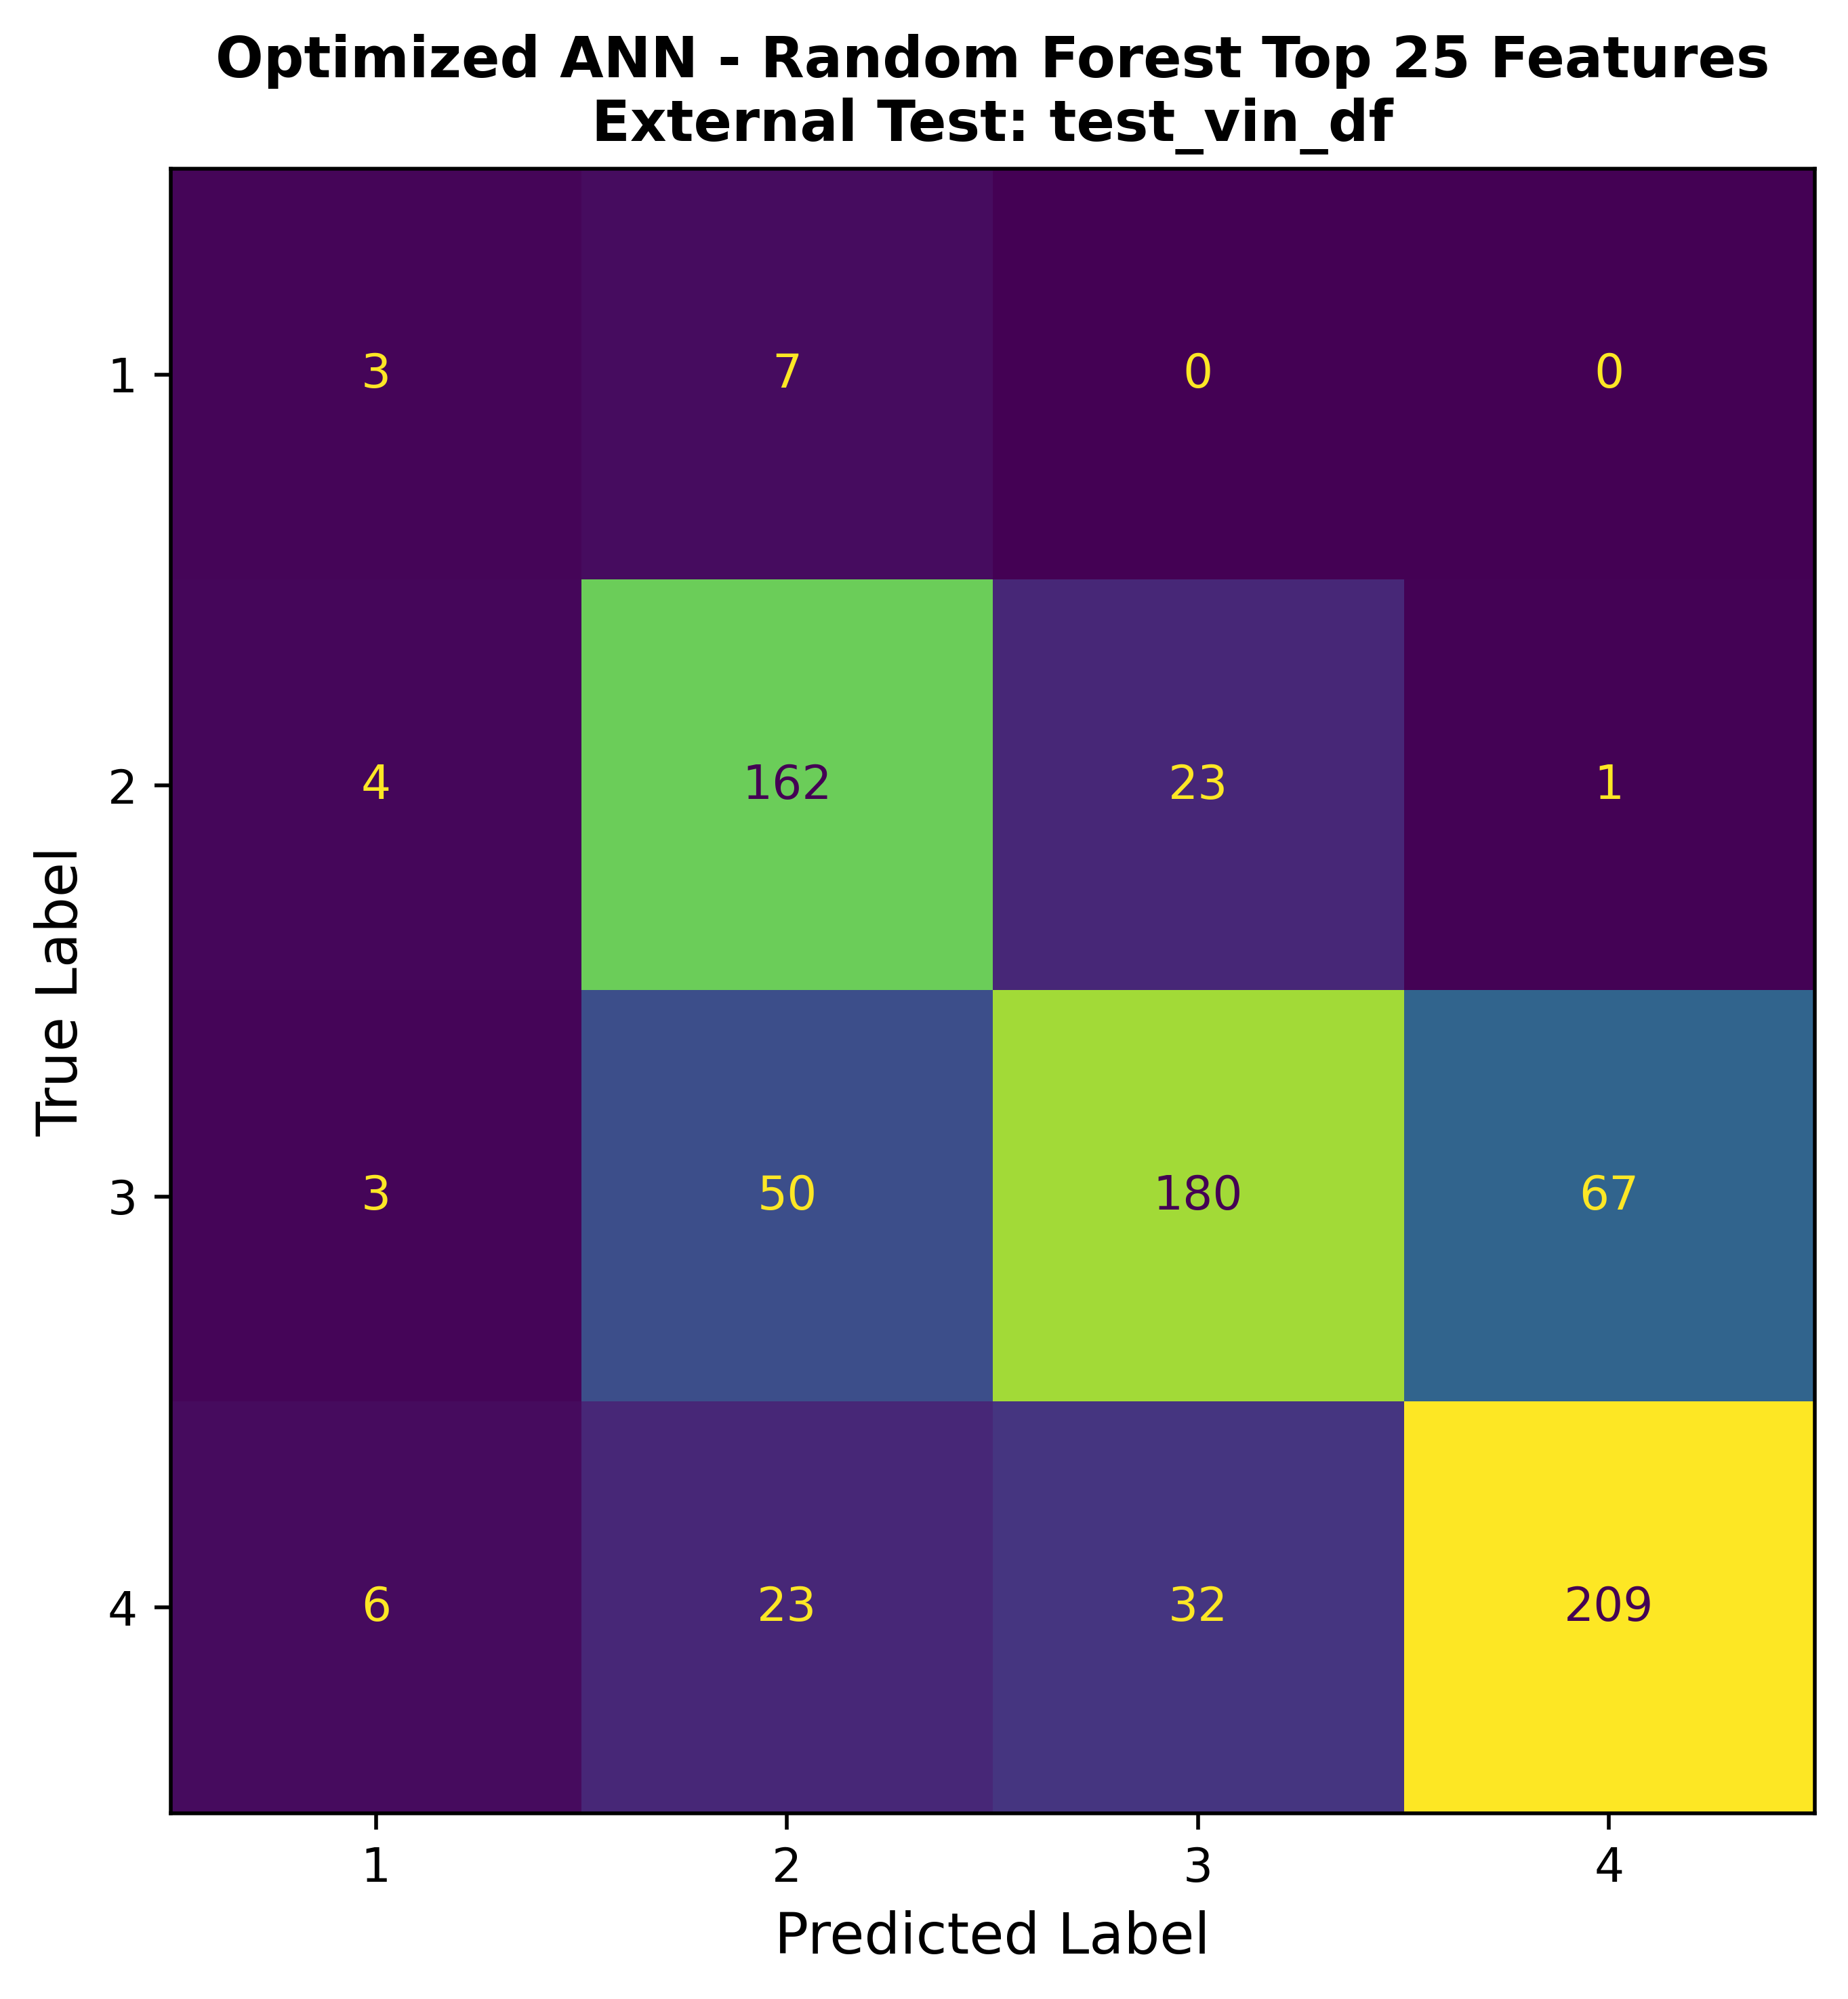

In [12]:

# ============================================================
# OPTIMIZED ANN / MLP
# 25 RANDOM FOREST SELECTED FEATURES
#
# Training Dataset : vin_df
# External Test    : test_vin_df
# CV               : Stratified 5-Fold
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import StratifiedKFold

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. FINAL TOP-25 FEATURES SELECTED BY RANDOM FOREST
# ============================================================
# IMPORTANT:
# These features have ALREADY been selected.
# NO additional feature selection is performed here.

selected_top25 = [

    # --------------------------------------------------------
    # Replace the following names with your EXACT
    # 25 Random Forest selected feature names.
    # --------------------------------------------------------

    "4bin_pol5-4",
    "16bin-pol4_2",
    "homogeneity0_40_bin1_3",
    "contrast135_50_bin1_6",
    "correlation0_1_bin2_6",
    "homogeneity0_2_bin2_6",
    "entropy0_3_bin2_6",
    "dissimilarity0_4_bin2_6",
    "ASM0_5_bin2_6",
    "count_higher_mean",
    "skewness2",
    "kurtosis2",
    "16bin-pol4_1",
    "64bin-pol4_1",
    "correlation0_30_bin1_3",
    "ASM135_30_bin1_6",
    "contrast0_20_bin2_6",
    "entropy0_40",
    "entropy0_50",
    "16bin-pol4_3",
    "64bin-pol4_2",
    "dissimilarity135_20_bin1_6",
    "bin3_7_50_IMC2",
    "entropy135_50",
    "ASM90_1_bin7_7"
]


print("\n" + "=" * 80)
print("RANDOM FOREST SELECTED TOP-25 FEATURES")
print("=" * 80)

for i, feature in enumerate(
    selected_top25,
    start=1
):
    print(f"{i}. {feature}")


# ============================================================
# 2. Training Dataset: vin_df
# ============================================================

X_vin_df = vin_df[selected_top25].copy()

y_vin_df = vin_df['ACR'].copy()


# ============================================================
# 3. External Test Dataset: test_vin_df
# ============================================================

X_test_top25 = test_vin_df[selected_top25].copy()

y_test = test_vin_df['ACR'].copy()


print("\n" + "=" * 80)
print("DATASET INFORMATION")
print("=" * 80)

print(
    "Training samples:",
    X_vin_df.shape[0]
)

print(
    "Training features:",
    X_vin_df.shape[1]
)

print(
    "External test samples:",
    X_test_top25.shape[0]
)


# ============================================================
# 4. 5-Fold Stratified Cross Validation
# ============================================================

skf = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)


# ============================================================
# 5. ANN ARCHITECTURES TO COMPARE
# ============================================================
# The best architecture will be selected based on
# Mean Weighted F1-score across the 5 folds.

architectures = [

    (8,),

    (16,),

    (16, 8),

    (32, 16),

    (32, 16, 8),

    (64, 32)
]


# ============================================================
# 6. Storage for Architecture Results
# ============================================================

architecture_results = []


# ============================================================
# 7. Evaluate Each ANN Architecture
# ============================================================

for architecture in architectures:

    print("\n" + "=" * 80)

    print(
        f"Testing ANN Architecture: {architecture}"
    )

    print("=" * 80)


    fold_accuracy = []

    fold_precision = []

    fold_recall = []

    fold_f1 = []


    # --------------------------------------------------------
    # 5-Fold CV
    # --------------------------------------------------------

    for fold, (train_idx, val_idx) in enumerate(

        skf.split(
            X_vin_df,
            y_vin_df
        ),

        start=1

    ):

        X_train = X_vin_df.iloc[train_idx]

        X_val = X_vin_df.iloc[val_idx]

        y_train = y_vin_df.iloc[train_idx]

        y_val = y_vin_df.iloc[val_idx]


        # ----------------------------------------------------
        # ANN Pipeline
        # ----------------------------------------------------

        ann = Pipeline([

            (
                'scaler',

                StandardScaler()
            ),

            (
                'mlp',

                MLPClassifier(

                    hidden_layer_sizes=architecture,

                    activation='relu',

                    solver='adam',

                    alpha=0.0001,

                    learning_rate_init=0.001,

                    max_iter=1000,

                    early_stopping=True,

                    validation_fraction=0.15,

                    n_iter_no_change=30,

                    random_state=42
                )
            )
        ])


        # ----------------------------------------------------
        # Train
        # ----------------------------------------------------

        ann.fit(

            X_train,

            y_train
        )


        # ----------------------------------------------------
        # Validation Prediction
        # ----------------------------------------------------

        y_pred = ann.predict(

            X_val
        )


        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        fold_accuracy.append(

            accuracy_score(
                y_val,
                y_pred
            )
        )


        fold_precision.append(

            precision_score(
                y_val,
                y_pred,
                average='weighted',
                zero_division=0
            )
        )


        fold_recall.append(

            recall_score(
                y_val,
                y_pred,
                average='weighted',
                zero_division=0
            )
        )


        fold_f1.append(

            f1_score(
                y_val,
                y_pred,
                average='weighted',
                zero_division=0
            )
        )


    # --------------------------------------------------------
    # Mean ± SD
    # --------------------------------------------------------

    architecture_results.append({

        'Architecture':

            str(architecture),

        'Accuracy_Mean':

            np.mean(fold_accuracy),

        'Accuracy_SD':

            np.std(
                fold_accuracy,
                ddof=1
            ),

        'Precision_Mean':

            np.mean(fold_precision),

        'Precision_SD':

            np.std(
                fold_precision,
                ddof=1
            ),

        'Recall_Mean':

            np.mean(fold_recall),

        'Recall_SD':

            np.std(
                fold_recall,
                ddof=1
            ),

        'F1_Mean':

            np.mean(fold_f1),

        'F1_SD':

            np.std(
                fold_f1,
                ddof=1
            )
    })


# ============================================================
# 8. Compare ANN Architectures
# ============================================================

architecture_results_df = pd.DataFrame(

    architecture_results
)


architecture_results_df = (

    architecture_results_df

    .sort_values(
        by='F1_Mean',
        ascending=False
    )

    .reset_index(drop=True)
)


print("\n" + "=" * 90)

print(
    "ANN ARCHITECTURE COMPARISON"
)

print("=" * 90)


print(

    architecture_results_df.to_string(
        index=False
    )
)


# ============================================================
# 9. Select BEST ANN Architecture
# ============================================================

best_architecture_string = (

    architecture_results_df.loc[
        0,
        'Architecture'
    ]
)


best_architecture = eval(
    best_architecture_string
)


best_cv_f1 = (

    architecture_results_df.loc[
        0,
        'F1_Mean'
    ]
)


print("\n" + "=" * 90)

print(
    "BEST ANN ARCHITECTURE"
)

print("=" * 90)


print(
    "Best Architecture:",
    best_architecture
)

print(
    f"Mean CV F1-score: "
    f"{best_cv_f1:.4f}"
)


# ============================================================
# 10. Train FINAL ANN on ALL vin_df
# ============================================================

final_ann = Pipeline([

    (
        'scaler',

        StandardScaler()
    ),

    (
        'mlp',

        MLPClassifier(

            hidden_layer_sizes=best_architecture,

            activation='relu',

            solver='adam',

            alpha=0.0001,

            learning_rate_init=0.001,

            max_iter=1000,

            early_stopping=True,

            validation_fraction=0.15,

            n_iter_no_change=30,

            random_state=42
        )
    )
])


final_ann.fit(

    X_vin_df,

    y_vin_df
)


# ============================================================
# 11. External Test: test_vin_df
# ============================================================

y_test_pred = final_ann.predict(

    X_test_top25
)


# ============================================================
# 12. External Test Metrics
# ============================================================

test_accuracy = accuracy_score(

    y_test,

    y_test_pred
)


test_precision = precision_score(

    y_test,

    y_test_pred,

    average='weighted',

    zero_division=0
)


test_recall = recall_score(

    y_test,

    y_test_pred,

    average='weighted',

    zero_division=0
)


test_f1 = f1_score(

    y_test,

    y_test_pred,

    average='weighted',

    zero_division=0
)


# ============================================================
# 13. External Test Results
# ============================================================

print("\n" + "=" * 90)

print(
    "FINAL ANN PERFORMANCE"
)

print("=" * 90)


print(
    "Selected Features : 25"
)

print(
    "Best Architecture :",
    best_architecture
)

print(
    f"CV Mean F1        : "
    f"{best_cv_f1:.4f}"
)


print("\nExternal Test - test_vin_df:")

print(
    f"Accuracy : {test_accuracy:.4f}"
)

print(
    f"Precision: {test_precision:.4f}"
)

print(
    f"Recall   : {test_recall:.4f}"
)

print(
    f"F1-score : {test_f1:.4f}"
)


# ============================================================
# 14. Classification Report
# ============================================================

print("\nClassification Report:")

print(

    classification_report(

        y_test,

        y_test_pred,

        zero_division=0
    )
)


# ============================================================
# 15. Confusion Matrix
# ============================================================

cm = confusion_matrix(

    y_test,

    y_test_pred
)


print("\nConfusion Matrix:")

print(cm)


# ============================================================
# 16. Plot Confusion Matrix
# ============================================================

class_labels = np.unique(

    y_vin_df
)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_labels
)


fig, ax = plt.subplots(

    figsize=(7, 6),

    dpi=500
)


disp.plot(

    ax=ax,

    values_format='d',

    colorbar=False
)


plt.title(

    "Optimized ANN - Random Forest Top 25 Features\n"
    "External Test: test_vin_df",

    fontsize=12,

    weight='bold'
)


plt.xlabel(

    "Predicted Label",

    fontsize=12
)


plt.ylabel(

    "True Label",

    fontsize=12
)


plt.tight_layout()

plt.show()




RANDOM FOREST SELECTED TOP-25 FEATURES
1. 4bin_pol5-4
2. 16bin-pol4_2
3. homogeneity0_40_bin1_3
4. contrast135_50_bin1_6
5. correlation0_1_bin2_6
6. homogeneity0_2_bin2_6
7. entropy0_3_bin2_6
8. dissimilarity0_4_bin2_6
9. ASM0_5_bin2_6
10. count_higher_mean
11. skewness2
12. kurtosis2
13. 16bin-pol4_1
14. 64bin-pol4_1
15. correlation0_30_bin1_3
16. ASM135_30_bin1_6
17. contrast0_20_bin2_6
18. entropy0_40
19. entropy0_50
20. 16bin-pol4_3
21. 64bin-pol4_2
22. dissimilarity135_20_bin1_6
23. bin3_7_50_IMC2
24. entropy135_50
25. ASM90_1_bin7_7

DATASET INFORMATION
Training samples: 940
Training features: 25
External test samples: 770

SVM-RBF HYPERPARAMETER OPTIMIZATION

Top SVM configurations:
 param_svm__C param_svm__gamma  mean_test_score  std_test_score  rank_test_score
        100.0             0.01         0.754589        0.034375                1
        100.0            scale         0.752500        0.023757                2
         10.0              0.1         0.749547        0.

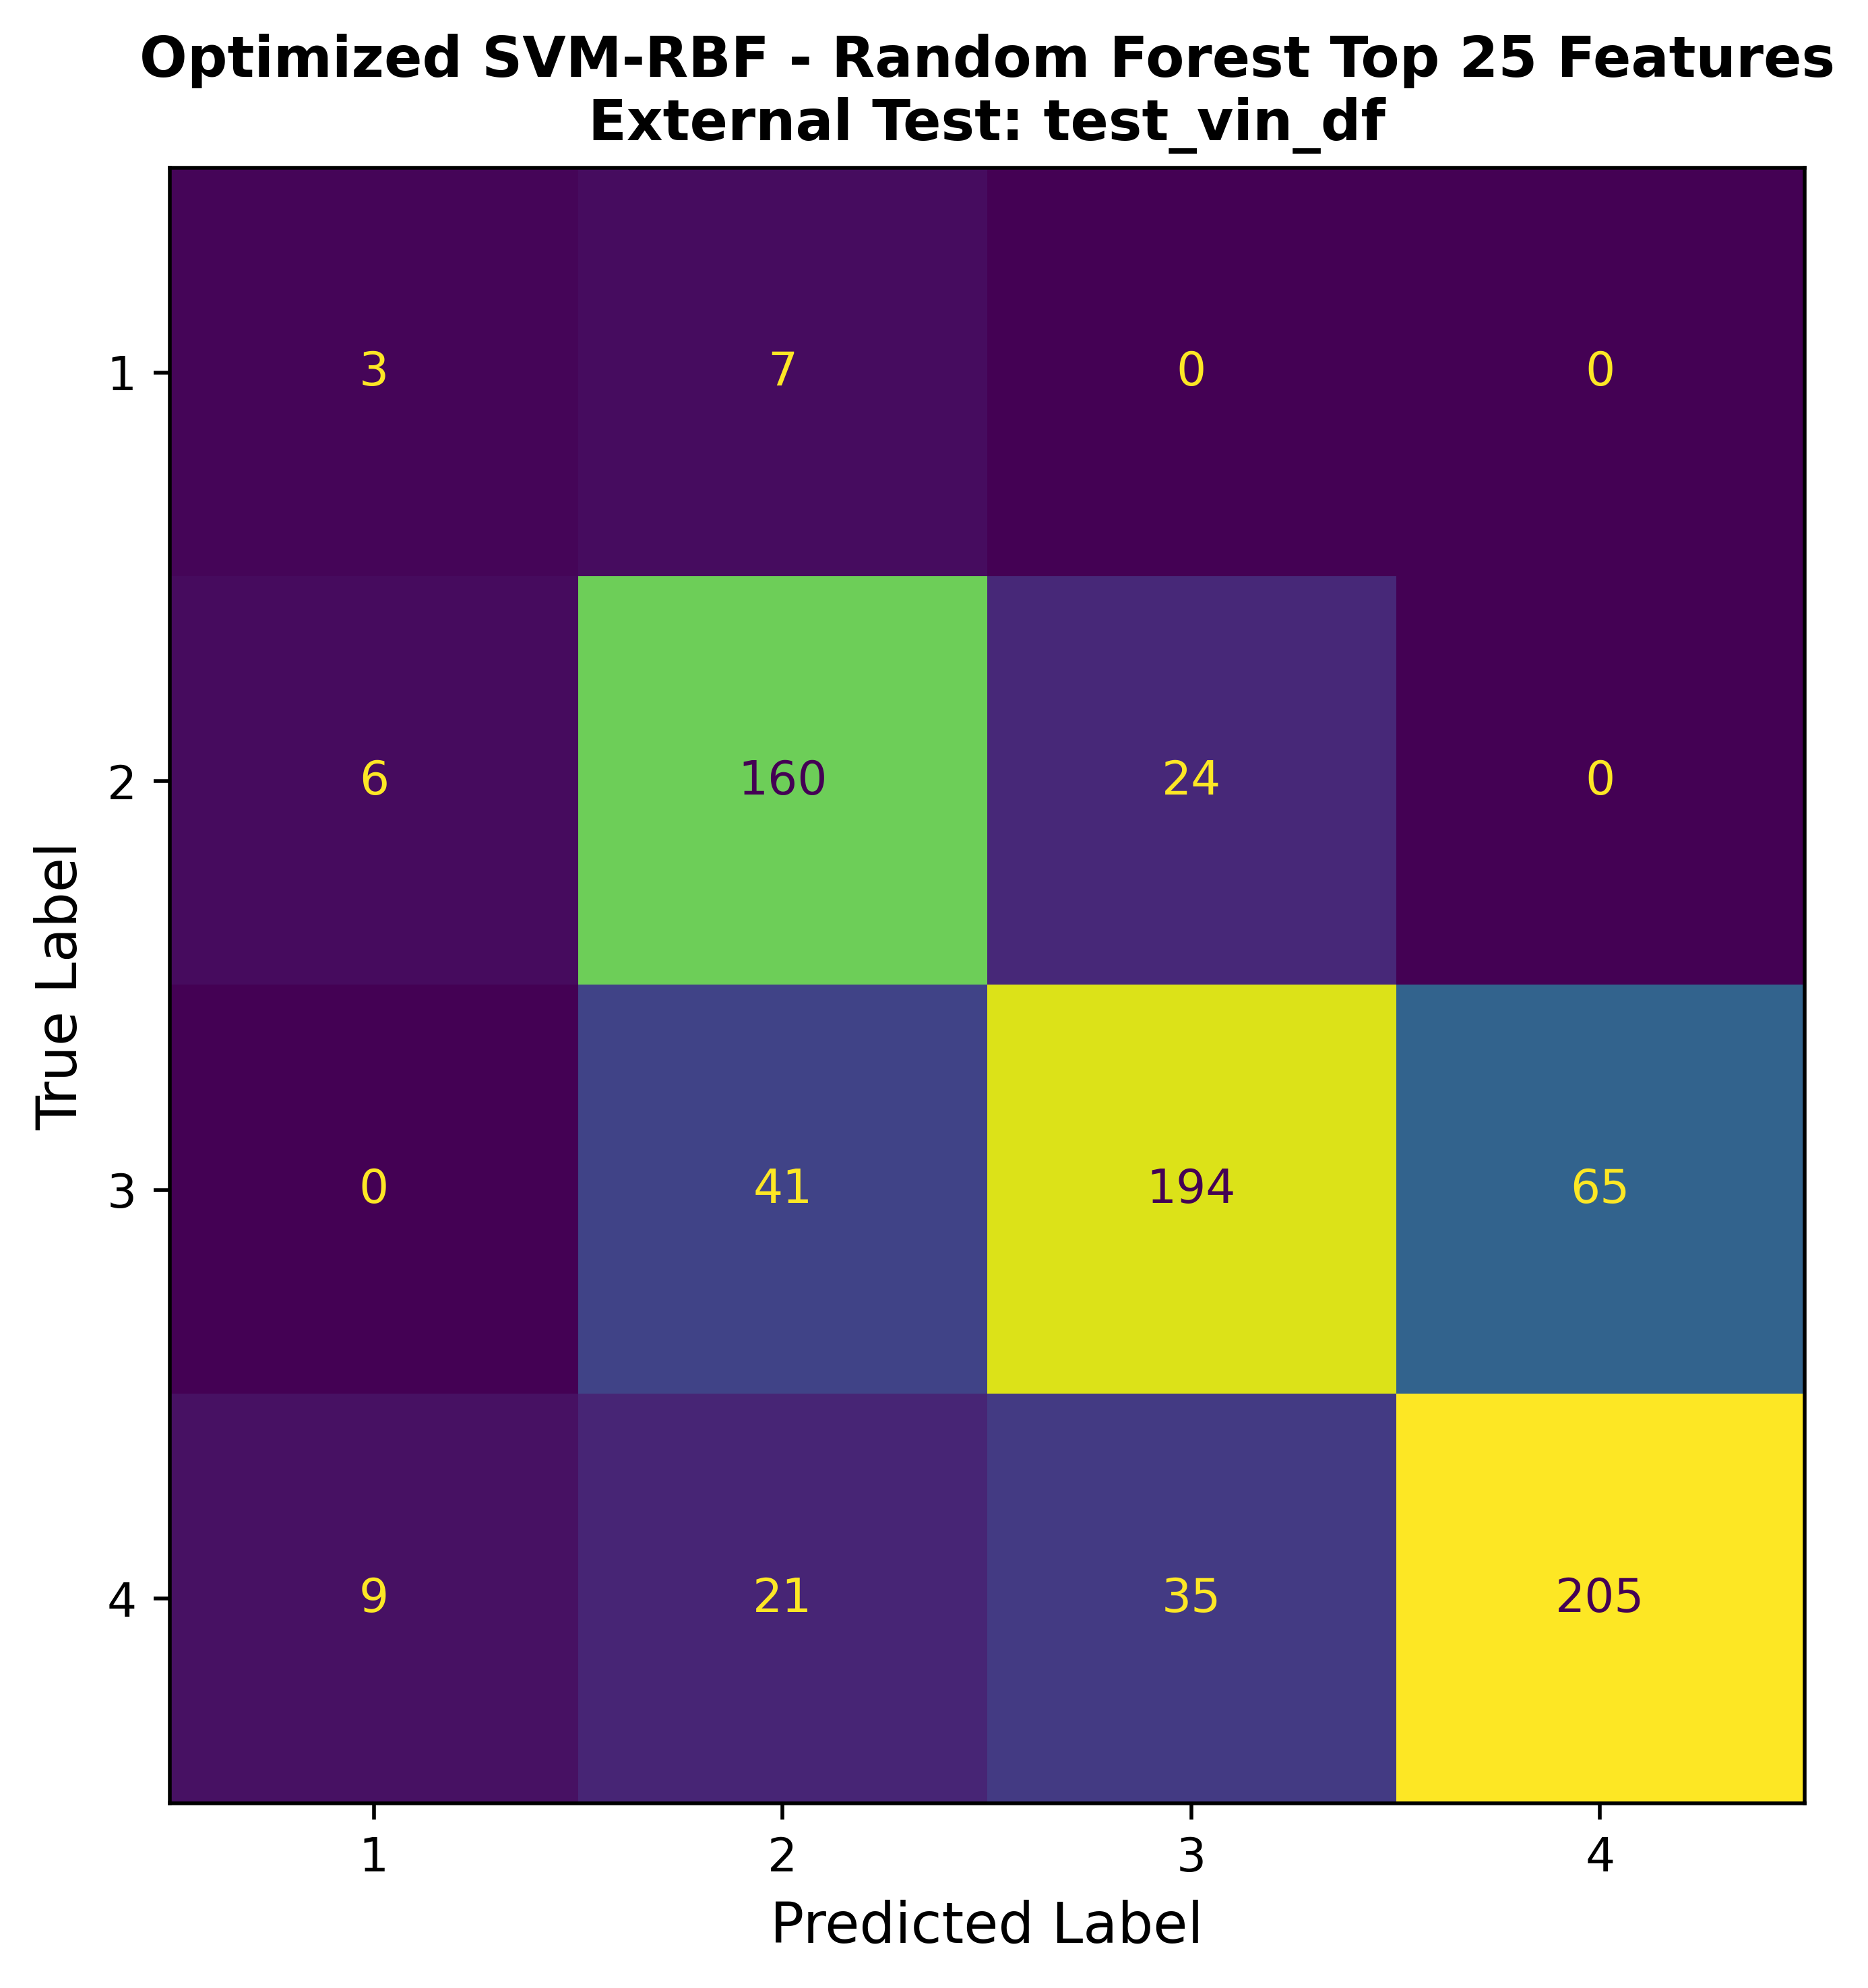

In [14]:

# ============================================================
# OPTIMIZED SVM-RBF
# 25 RANDOM FOREST SELECTED FEATURES
#
# Training Dataset : vin_df
# External Test    : test_vin_df
# CV               : Stratified 5-Fold
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC

from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================================
# 1. FINAL TOP-25 FEATURES SELECTED BY RANDOM FOREST
# ============================================================

selected_top25 = [

    # --------------------------------------------------------
    # Replace with your EXACT 25 Random Forest selected
    # feature names.
    # --------------------------------------------------------
    "4bin_pol5-4",
    "16bin-pol4_2",
    "homogeneity0_40_bin1_3",
    "contrast135_50_bin1_6",
    "correlation0_1_bin2_6",
    "homogeneity0_2_bin2_6",
    "entropy0_3_bin2_6",
    "dissimilarity0_4_bin2_6",
    "ASM0_5_bin2_6",
    "count_higher_mean",
    "skewness2",
    "kurtosis2",
    "16bin-pol4_1",
    "64bin-pol4_1",
    "correlation0_30_bin1_3",
    "ASM135_30_bin1_6",
    "contrast0_20_bin2_6",
    "entropy0_40",
    "entropy0_50",
    "16bin-pol4_3",
    "64bin-pol4_2",
    "dissimilarity135_20_bin1_6",
    "bin3_7_50_IMC2",
    "entropy135_50",
    "ASM90_1_bin7_7"
]


print("\n" + "=" * 80)

print(
    "RANDOM FOREST SELECTED TOP-25 FEATURES"
)

print("=" * 80)


for i, feature in enumerate(

    selected_top25,

    start=1

):

    print(
        f"{i}. {feature}"
    )


# ============================================================
# 2. Training Dataset: vin_df
# ============================================================

X_vin_df = vin_df[selected_top25].copy()

y_vin_df = vin_df['ACR'].copy()


# ============================================================
# 3. External Test Dataset: test_vin_df
# ============================================================

X_test_top25 = test_vin_df[selected_top25].copy()

y_test = test_vin_df['ACR'].copy()


print("\n" + "=" * 80)

print(
    "DATASET INFORMATION"
)

print("=" * 80)


print(
    "Training samples:",
    X_vin_df.shape[0]
)


print(
    "Training features:",
    X_vin_df.shape[1]
)


print(
    "External test samples:",
    X_test_top25.shape[0]
)


# ============================================================
# 4. 5-Fold Stratified Cross Validation
# ============================================================

skf = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)


# ============================================================
# 5. SVM-RBF PIPELINE
# ============================================================

svm_pipeline = Pipeline([

    (
        'scaler',

        StandardScaler()
    ),

    (
        'svm',

        SVC(
            kernel='rbf'
        )
    )
])


# ============================================================
# 6. HYPERPARAMETER SEARCH
# ============================================================

param_grid = {

    'svm__C': [

        0.01,

        0.1,

        1,

        10,

        100,

        1000
    ],

    'svm__gamma': [

        'scale',

        0.0001,

        0.001,

        0.01,

        0.1,

        1
    ]
}


# ============================================================
# 7. GRID SEARCH
# ============================================================
# Best model is selected based ONLY on training CV.
# test_vin_df remains untouched.

grid_search = GridSearchCV(

    estimator=svm_pipeline,

    param_grid=param_grid,

    scoring='f1_weighted',

    cv=skf,

    n_jobs=-1,

    refit=True,

    return_train_score=True
)


print("\n" + "=" * 90)

print(
    "SVM-RBF HYPERPARAMETER OPTIMIZATION"
)

print("=" * 90)


grid_search.fit(

    X_vin_df,

    y_vin_df
)


# ============================================================
# 8. ALL SVM RESULTS
# ============================================================

svm_results = pd.DataFrame(

    grid_search.cv_results_
)


svm_results = (

    svm_results

    .sort_values(
        by='mean_test_score',
        ascending=False
    )

    .reset_index(drop=True)
)


print("\nTop SVM configurations:")

print(

    svm_results[
        [
            'param_svm__C',

            'param_svm__gamma',

            'mean_test_score',

            'std_test_score',

            'rank_test_score'
        ]
    ]

    .head(15)

    .to_string(
        index=False
    )
)


# ============================================================
# 9. BEST SVM
# ============================================================

best_C = grid_search.best_params_[
    'svm__C'
]


best_gamma = grid_search.best_params_[
    'svm__gamma'
]


best_cv_f1 = grid_search.best_score_


print("\n" + "=" * 90)

print(
    "BEST SVM-RBF"
)

print("=" * 90)


print(
    "Best C:",
    best_C
)


print(
    "Best gamma:",
    best_gamma
)


print(
    f"Best 5-Fold CV F1: "
    f"{best_cv_f1:.4f}"
)


# ============================================================
# 10. BEST MODEL
# ============================================================
# GridSearchCV already refitted the best model on
# ALL vin_df.

final_svm = grid_search.best_estimator_


# ============================================================
# 11. EXTERNAL TEST: test_vin_df
# ============================================================

y_test_pred = final_svm.predict(

    X_test_top25
)


# ============================================================
# 12. EXTERNAL TEST METRICS
# ============================================================

test_accuracy = accuracy_score(

    y_test,

    y_test_pred
)


test_precision = precision_score(

    y_test,

    y_test_pred,

    average='weighted',

    zero_division=0
)


test_recall = recall_score(

    y_test,

    y_test_pred,

    average='weighted',

    zero_division=0
)


test_f1 = f1_score(

    y_test,

    y_test_pred,

    average='weighted',

    zero_division=0
)


# ============================================================
# 13. EXTERNAL TEST RESULTS
# ============================================================

print("\n" + "=" * 90)

print(
    "FINAL OPTIMIZED SVM-RBF PERFORMANCE"
)

print("=" * 90)


print(
    "Selected Features : 25"
)


print(
    "Best C             :",
    best_C
)


print(
    "Best gamma         :",
    best_gamma
)


print(
    f"CV Mean F1         : "
    f"{best_cv_f1:.4f}"
)


print("\nExternal Test - test_vin_df:")


print(
    f"Accuracy : {test_accuracy:.4f}"
)


print(
    f"Precision: {test_precision:.4f}"
)


print(
    f"Recall   : {test_recall:.4f}"
)


print(
    f"F1-score : {test_f1:.4f}"
)


# ============================================================
# 14. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")


print(

    classification_report(

        y_test,

        y_test_pred,

        zero_division=0
    )
)


# ============================================================
# 15. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_test,

    y_test_pred
)


print("\nConfusion Matrix:")

print(cm)


# ============================================================
# 16. PLOT CONFUSION MATRIX
# ============================================================

class_labels = np.unique(

    y_vin_df
)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_labels
)


fig, ax = plt.subplots(

    figsize=(7, 6),

    dpi=500
)


disp.plot(

    ax=ax,

    values_format='d',

    colorbar=False
)


plt.title(

    "Optimized SVM-RBF - Random Forest Top 25 Features\n"
    "External Test: test_vin_df",

    fontsize=12,

    weight='bold'
)


plt.xlabel(

    "Predicted Label",

    fontsize=12
)


plt.ylabel(

    "True Label",

    fontsize=12
)


plt.xticks(

    fontsize=10
)


plt.yticks(

    fontsize=10
)


plt.tight_layout()

plt.show()



In [21]:
"""
RFE Feature-Count Ablation Study
=================================

Goal
----
Instead of guessing between 10 and 25 features, this script sweeps the
number of RFE-selected features across a grid (default: 5, 10, 15, 20,
25, 35, 50) for BOTH RFE estimators (Decision Tree, Random Forest) and
BOTH classifiers (ANN / MLP, SVM-RBF), on BOTH datasets (Sohrevardi,
VinDr-Mammo). It plots Accuracy and F1-score vs. number of features so
you can see exactly where the curve plateaus or starts to drop --
i.e., the evidence-based "optimal" feature count for the paper.

It also demonstrates scikit-learn's RFECV, which selects the feature
count automatically via cross-validation, as a principled alternative
to a fixed grid search.

Methodology notes (important for the paper's Methods section)
---------------------------------------------------------------
1. Sohrevardi (no independent external test set):
   For every feature count N, RFE is refit INSIDE every outer CV fold
   (using only that fold's training data), the classifier is trained
   on the fold's selected features, and evaluated on the fold's held-out
   data. This is nested/fold-safe -- feature selection never sees the
   evaluation fold, so there is no leakage. Metrics reported are the
   mean +/- SD across the 5 outer folds (same convention as your
   existing Table 3 / Table 4 "DT/RF Estimator" rows).

2. VinDr-Mammo (train = vin_df, external test = test_vin_df):
   For every feature count N, RFE is fit once on the full vin_df
   training set, the classifier is trained on vin_df with the selected
   features, and evaluated on the untouched external test_vin_df
   (770 samples) -- exactly like your existing external-test rows.

3. RFECV (scikit-learn) is run once per dataset/estimator/classifier
   combination as an automatic alternative: it internally cross-validates
   over a range of feature counts and returns the count that maximizes
   the scoring metric (here: weighted F1), together with the full
   score-vs-n_features curve, so you get the "optimal N" without
   picking the grid by hand.

How to use
----------
1. Edit the three file paths in the CONFIG section below to point to
   your actual data files (same paths you used in the notebook).
2. Adjust FEATURE_COUNTS / N_ESTIMATORS_RF / RANDOM_STATE if desired.
3. Run:  python rfe_ablation_study.py
4. Outputs (written next to this script):
   - ablation_results.csv          (all raw numbers, long format)
   - ablation_sohrevardi.png       (Accuracy & F1 vs #features, Sohrevardi)
   - ablation_vindr.png            (Accuracy & F1 vs #features, VinDr-Mammo)
   - rfecv_summary.csv             (auto-selected N per combination)
   - rfecv_curves.png              (RFECV score-vs-#features curves)

Runtime warning
---------------
Random-Forest RFE with n_estimators=500 on ~7,164 raw features is slow,
especially inside a 5-fold nested loop, repeated for every feature count.
A rough budget: reduce N_ESTIMATORS_RF to 200-300 and/or use a larger
RFE `step` (e.g. 0.02-0.05) if this takes too long on your machine.
You can also comment out feature counts you don't need in FEATURE_COUNTS,
or run Sohrevardi and VinDr-Mammo separately (see the __main__ section).
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    make_scorer
)

# ============================================================
# CONFIG -- edit these to match your environment
# ============================================================

SOH_PATH = "/Users/rezvaneh/Desktop/Mammo Research/SelectedFeatures_3Datasets/Sohrevardi/Soh_Features.xlsx"
VINDR_TRAIN_PATH = "/Users/rezvaneh/Desktop/Mammo Research/SelectedFeatures_3Datasets/VinDr/train/Vindr_CC_train.xlsx"
VINDR_TEST_PATH = "/Users/rezvaneh/Desktop/Mammo Research/SelectedFeatures_3Datasets/VinDr/test/Vindr_CC_test.csv"

TARGET_COL = "ACR"

FEATURE_COUNTS = [5, 10, 15, 20, 25, 35, 50]

RFE_STEP = 0.02          # fraction of features removed per RFE iteration (raise for speed)
N_ESTIMATORS_RF = 300     # lower from 500 for speed; raise back for final numbers
RANDOM_STATE = 42
N_OUTER_FOLDS = 5         # Sohrevardi nested CV folds

ANN_HIDDEN_LAYERS = (32, 16, 8)   # pick any single fixed architecture for a fair ablation
SVM_C = 10
SVM_GAMMA = "scale"

OUT_PREFIX = "."  # output directory for CSV/PNG files


# ============================================================
# Helpers
# ============================================================

def get_rfe_estimator(kind):
    if kind == "DT":
        return DecisionTreeClassifier(
            criterion="gini", max_depth=None, random_state=RANDOM_STATE
        )
    elif kind == "RF":
        return RandomForestClassifier(
            n_estimators=N_ESTIMATORS_RF, criterion="gini",
            max_depth=None, random_state=RANDOM_STATE, n_jobs=-1
        )
    else:
        raise ValueError(kind)


def get_classifier_pipeline(kind):
    if kind == "SVM":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="rbf", C=SVM_C, gamma=SVM_GAMMA)),
        ])
    elif kind == "ANN":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(
                hidden_layer_sizes=ANN_HIDDEN_LAYERS,
                activation="relu", solver="adam",
                alpha=0.0001, learning_rate_init=0.001,
                max_iter=1000, early_stopping=True,
                validation_fraction=0.15, n_iter_no_change=30,
                random_state=RANDOM_STATE
            )),
        ])
    else:
        raise ValueError(kind)


def weighted_metrics(y_true, y_pred):
    return dict(
        accuracy=accuracy_score(y_true, y_pred),
        precision=precision_score(y_true, y_pred, average="weighted", zero_division=0),
        recall=recall_score(y_true, y_pred, average="weighted", zero_division=0),
        f1=f1_score(y_true, y_pred, average="weighted", zero_division=0),
    )


# ============================================================
# Sohrevardi: nested CV ablation (fold-safe feature selection)
# ============================================================

def sohrevardi_ablation(Soh_df, feature_counts=FEATURE_COUNTS,
                         rfe_kinds=("DT", "RF"), clf_kinds=("ANN", "SVM")):
    X = Soh_df.drop(columns=[TARGET_COL])
    y = Soh_df[TARGET_COL]

    skf = StratifiedKFold(n_splits=N_OUTER_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    splits = list(skf.split(X, y))  # reuse same folds across all combinations

    rows = []
    for rfe_kind in rfe_kinds:
        for n_feat in feature_counts:
            for clf_kind in clf_kinds:
                fold_metrics = []
                for fold, (train_idx, test_idx) in enumerate(splits, start=1):
                    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
                    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

                    selector = RFE(
                        estimator=get_rfe_estimator(rfe_kind),
                        n_features_to_select=n_feat,
                        step=RFE_STEP,
                    )
                    selector.fit(X_train, y_train)
                    sel_features = X_train.columns[selector.support_]

                    clf = get_classifier_pipeline(clf_kind)
                    clf.fit(X_train[sel_features], y_train)
                    y_pred = clf.predict(X_test[sel_features])

                    m = weighted_metrics(y_test, y_pred)
                    m["fold"] = fold
                    fold_metrics.append(m)

                    print(f"[Sohrevardi] RFE={rfe_kind} N={n_feat:>2} CLF={clf_kind} "
                          f"fold={fold} acc={m['accuracy']*100:.2f}%")

                fm = pd.DataFrame(fold_metrics)
                rows.append({
                    "dataset": "Sohrevardi",
                    "rfe_estimator": rfe_kind,
                    "n_features": n_feat,
                    "classifier": clf_kind,
                    "accuracy_mean": fm["accuracy"].mean() * 100,
                    "accuracy_sd": fm["accuracy"].std(ddof=1) * 100,
                    "precision_mean": fm["precision"].mean() * 100,
                    "precision_sd": fm["precision"].std(ddof=1) * 100,
                    "recall_mean": fm["recall"].mean() * 100,
                    "recall_sd": fm["recall"].std(ddof=1) * 100,
                    "f1_mean": fm["f1"].mean() * 100,
                    "f1_sd": fm["f1"].std(ddof=1) * 100,
                })

    return pd.DataFrame(rows)


# ============================================================
# VinDr-Mammo: RFE on train, evaluate on external test
# ============================================================

def vindr_ablation(vin_df, test_vin_df, feature_counts=FEATURE_COUNTS,
                    rfe_kinds=("DT", "RF"), clf_kinds=("ANN", "SVM")):
    X_train_full = vin_df.drop(columns=[TARGET_COL])
    y_train_full = vin_df[TARGET_COL]
    X_test_full = test_vin_df.drop(columns=[TARGET_COL])
    y_test_full = test_vin_df[TARGET_COL]

    rows = []
    for rfe_kind in rfe_kinds:
        for n_feat in feature_counts:
            selector = RFE(
                estimator=get_rfe_estimator(rfe_kind),
                n_features_to_select=n_feat,
                step=RFE_STEP,
            )
            selector.fit(X_train_full, y_train_full)
            sel_features = X_train_full.columns[selector.support_]

            for clf_kind in clf_kinds:
                clf = get_classifier_pipeline(clf_kind)
                clf.fit(X_train_full[sel_features], y_train_full)
                y_pred = clf.predict(X_test_full[sel_features])

                m = weighted_metrics(y_test_full, y_pred)
                print(f"[VinDr-Mammo] RFE={rfe_kind} N={n_feat:>2} CLF={clf_kind} "
                      f"test_acc={m['accuracy']*100:.2f}%")

                rows.append({
                    "dataset": "VinDr-Mammo",
                    "rfe_estimator": rfe_kind,
                    "n_features": n_feat,
                    "classifier": clf_kind,
                    "accuracy_mean": m["accuracy"] * 100,
                    "accuracy_sd": np.nan,
                    "precision_mean": m["precision"] * 100,
                    "precision_sd": np.nan,
                    "recall_mean": m["recall"] * 100,
                    "recall_sd": np.nan,
                    "f1_mean": m["f1"] * 100,
                    "f1_sd": np.nan,
                })

    return pd.DataFrame(rows)


# ============================================================
# RFECV -- automatic feature-count selection
# ============================================================

def rfecv_summary(X, y, rfe_kinds=("DT", "RF"), min_features=5,
                   cv_folds=5, scoring="f1_weighted"):
    """
    Runs RFECV once per RFE-estimator kind and returns:
      - a one-row summary per estimator (optimal n_features, best score)
      - the full (n_features -> mean CV score) curve for plotting
    Note: RFECV only determines the optimal N for *feature selection
    quality* using the RFE estimator itself as the scorer -- it does not
    separately test ANN/SVM downstream. Treat its optimal N as a
    complementary sanity check against the manual ablation curves above,
    not a replacement for them.
    """
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)

    summary_rows = []
    curves = {}

    for rfe_kind in rfe_kinds:
        est = get_rfe_estimator(rfe_kind)
        selector = RFECV(
            estimator=est,
            step=RFE_STEP,
            min_features_to_select=min_features,
            cv=skf,
            scoring=scoring,
            n_jobs=-1,
        )
        selector.fit(X, y)

        mean_scores = np.asarray(selector.cv_results_["mean_test_score"])
        std_scores = np.asarray(selector.cv_results_["std_test_score"])

        curves[rfe_kind] = pd.DataFrame({
            "n_features_step": np.arange(len(mean_scores)),
            "mean_test_score": mean_scores,
            "std_test_score": std_scores,
        })

        summary_rows.append({
            "rfe_estimator": rfe_kind,
            "optimal_n_features": selector.n_features_,
            "best_cv_score_f1_weighted": mean_scores.max(),
        })

        print(f"[RFECV] estimator={rfe_kind} -> optimal N = {selector.n_features_} "
              f"(best CV {scoring} = {selector.cv_results_['mean_test_score'].max():.4f})")

    return pd.DataFrame(summary_rows), curves


# ============================================================
# Plotting
# ============================================================

def plot_ablation(df, dataset_name, out_path):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    metrics = [("accuracy_mean", "accuracy_sd", "Accuracy (%)"),
               ("f1_mean", "f1_sd", "F1-score (%)")]

    styles = {
        ("DT", "ANN"): dict(color="tab:blue", marker="o", linestyle="--", label="DT + ANN"),
        ("DT", "SVM"): dict(color="tab:blue", marker="s", linestyle="-", label="DT + SVM"),
        ("RF", "ANN"): dict(color="tab:red", marker="o", linestyle="--", label="RF + ANN"),
        ("RF", "SVM"): dict(color="tab:red", marker="s", linestyle="-", label="RF + SVM"),
    }

    for ax, (mean_col, sd_col, ylabel) in zip(axes, metrics):
        for (rfe_kind, clf_kind), style in styles.items():
            sub = df[(df.rfe_estimator == rfe_kind) & (df.classifier == clf_kind)].sort_values("n_features")
            if sub.empty:
                continue
            ax.plot(sub.n_features, sub[mean_col], **style)
            if sub[sd_col].notna().any():
                ax.fill_between(sub.n_features,
                                 sub[mean_col] - sub[sd_col],
                                 sub[mean_col] + sub[sd_col],
                                 color=style["color"], alpha=0.12)
        ax.set_xlabel("Number of RFE-selected features")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{dataset_name}: {ylabel} vs. #features")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9)

    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)
    print(f"Saved plot -> {out_path}")


def plot_rfecv_curves(curves, out_path):
    fig, ax = plt.subplots(figsize=(7, 5))
    for rfe_kind, curve in curves.items():
        ax.plot(curve.n_features_step, curve.mean_test_score, marker=".", label=f"RFECV ({rfe_kind})")
        ax.fill_between(curve.n_features_step,
                         curve.mean_test_score - curve.std_test_score,
                         curve.mean_test_score + curve.std_test_score,
                         alpha=0.15)
    ax.set_xlabel("RFECV elimination step (more steps = fewer features)")
    ax.set_ylabel("Mean CV F1-weighted score")
    ax.set_title("RFECV automatic feature-count search")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)
    print(f"Saved plot -> {out_path}")


# ============================================================
# Main
# ============================================================

if __name__ == "__main__":
    print("Loading data...")
    Soh_df = pd.read_excel(SOH_PATH)
    vin_df = pd.read_excel(VINDR_TRAIN_PATH)
    test_vin_df = pd.read_csv(VINDR_TEST_PATH)

    print("\n=== Sohrevardi ablation (nested 5-fold CV) ===")
    soh_results = sohrevardi_ablation(Soh_df)

    print("\n=== VinDr-Mammo ablation (external test) ===")
    vindr_results = vindr_ablation(vin_df, test_vin_df)

    all_results = pd.concat([soh_results, vindr_results], ignore_index=True)
    all_results.to_csv(f"{OUT_PREFIX}/ablation_results.csv", index=False)
    print(f"\nSaved raw results -> {OUT_PREFIX}/ablation_results.csv")

    plot_ablation(soh_results, "Sohrevardi", f"{OUT_PREFIX}/ablation_sohrevardi.png")
    plot_ablation(vindr_results, "VinDr-Mammo", f"{OUT_PREFIX}/ablation_vindr.png")

    print("\n=== RFECV automatic feature-count search (Sohrevardi) ===")
    X_soh = Soh_df.drop(columns=[TARGET_COL])
    y_soh = Soh_df[TARGET_COL]
    rfecv_sum, rfecv_curves = rfecv_summary(X_soh, y_soh)
    rfecv_sum.to_csv(f"{OUT_PREFIX}/rfecv_summary.csv", index=False)
    plot_rfecv_curves(rfecv_curves, f"{OUT_PREFIX}/rfecv_curves.png")

    print("\nDone. Inspect ablation_sohrevardi.png / ablation_vindr.png for the")
    print("Accuracy & F1 vs. #features curves, and rfecv_summary.csv for the")
    print("automatically selected optimal feature count per RFE estimator.")

Loading data...

=== Sohrevardi ablation (nested 5-fold CV) ===
[Sohrevardi] RFE=DT N= 5 CLF=ANN fold=1 acc=74.29%
[Sohrevardi] RFE=DT N= 5 CLF=ANN fold=2 acc=74.74%
[Sohrevardi] RFE=DT N= 5 CLF=ANN fold=3 acc=73.36%
[Sohrevardi] RFE=DT N= 5 CLF=ANN fold=4 acc=74.70%
[Sohrevardi] RFE=DT N= 5 CLF=ANN fold=5 acc=73.51%
[Sohrevardi] RFE=DT N= 5 CLF=SVM fold=1 acc=74.89%
[Sohrevardi] RFE=DT N= 5 CLF=SVM fold=2 acc=74.74%
[Sohrevardi] RFE=DT N= 5 CLF=SVM fold=3 acc=72.77%
[Sohrevardi] RFE=DT N= 5 CLF=SVM fold=4 acc=77.38%
[Sohrevardi] RFE=DT N= 5 CLF=SVM fold=5 acc=73.96%
[Sohrevardi] RFE=DT N=10 CLF=ANN fold=1 acc=76.23%
[Sohrevardi] RFE=DT N=10 CLF=ANN fold=2 acc=75.48%
[Sohrevardi] RFE=DT N=10 CLF=ANN fold=3 acc=74.11%
[Sohrevardi] RFE=DT N=10 CLF=ANN fold=4 acc=77.23%
[Sohrevardi] RFE=DT N=10 CLF=ANN fold=5 acc=72.32%
[Sohrevardi] RFE=DT N=10 CLF=SVM fold=1 acc=74.89%
[Sohrevardi] RFE=DT N=10 CLF=SVM fold=2 acc=74.89%
[Sohrevardi] RFE=DT N=10 CLF=SVM fold=3 acc=71.88%
[Sohrevardi] RFE=D

In [ ]:
def vindr_ablation(Soh_df, vin_df, test_vin_df, feature_counts=FEATURE_COUNTS,
                    rfe_kinds=("DT", "RF"), clf_kinds=("ANN", "SVM")):
    """
    CORRECTED: feature selection happens ONLY on the full Sohrevardi
    dataset (matching Table 3 / Table 4's actual pipeline). The same
    selected feature names are then extracted from VinDr-Mammo with
    NO re-selection -- this is the true "transferability vs. feature
    count" curve, not an in-domain oracle.
    """
    X_soh = Soh_df.drop(columns=[TARGET_COL])
    y_soh = Soh_df[TARGET_COL]

    X_train_full = vin_df.drop(columns=[TARGET_COL])
    y_train_full = vin_df[TARGET_COL]
    X_test_full = test_vin_df.drop(columns=[TARGET_COL])
    y_test_full = test_vin_df[TARGET_COL]

    rows = []
    for rfe_kind in rfe_kinds:
        for n_feat in feature_counts:
            # --- Feature selection on Sohrevardi ONLY (single pass,
            #     full dataset -- same as the pipeline used for Table 3/4) ---
            selector = RFE(
                estimator=get_rfe_estimator(rfe_kind),
                n_features_to_select=n_feat,
                step=RFE_STEP,
            )
            selector.fit(X_soh, y_soh)
            sel_features = X_soh.columns[selector.support_]

            for clf_kind in clf_kinds:
                clf = get_classifier_pipeline(clf_kind)
                # --- Same Sohrevardi-selected features, extracted from
                #     VinDr-Mammo, NO re-selection ---
                clf.fit(X_train_full[sel_features], y_train_full)
                y_pred = clf.predict(X_test_full[sel_features])

                m = weighted_metrics(y_test_full, y_pred)
                print(f"[VinDr-Mammo] RFE={rfe_kind} (selected on Sohrevardi) "
                      f"N={n_feat:>2} CLF={clf_kind} test_acc={m['accuracy']*100:.2f}%")

                rows.append({
                    "dataset": "VinDr-Mammo",
                    "rfe_estimator": rfe_kind,
                    "n_features": n_feat,
                    "classifier": clf_kind,
                    "accuracy_mean": m["accuracy"] * 100,
                    "accuracy_sd": np.nan,
                    "precision_mean": m["precision"] * 100,
                    "precision_sd": np.nan,
                    "recall_mean": m["recall"] * 100,
                    "recall_sd": np.nan,
                    "f1_mean": m["f1"] * 100,
                    "f1_sd": np.nan,
                })

    return pd.DataFrame(rows)


# Call it like this (note the extra Soh_df argument vs. the old version):
# vindr_results = vindr_ablation(Soh_df, vin_df, test_vin_df)
# vindr_results.to_csv("ablation_results_vindr_corrected.csv", index=False)
# (then re-plot ablation_vindr.png from vindr_results exactly as before)
